# Import libraries

In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import bptf
from own_implementation import BPTF
import numpy as np
import pandas as pd
import sparse
import os
import shutil
from tqdm import tqdm
import pickle
import scipy.stats as st
import matplotlib.pyplot as plt
import torch
import tensorly
import cupy

import multiprocessing
from joblib import Parallel, delayed
from tqdm.contrib.concurrent import process_map

import gc
gc.collect()

os.getcwd()

<IPython.core.display.Javascript object>

Kernel is restarting...


'/home/luiyusen/projects/bptf_new'

# Get reference label tables

In [2]:
parallel = False
if parallel:
    print(multiprocessing.cpu_count())
end_year = 18 # 24 for 2024 and 18 for 2018
print([str(2000 + x) for x in range(0, end_year + 1)])

folder = "/icews_gdelt_terrier/"
data_filepath = os.getcwd() + folder
files = os.listdir(data_filepath)
if parallel:
    files = Parallel(n_jobs=multiprocessing.cpu_count())(
        delayed(pd.read_csv)(data_filepath + filepath)
        for filepath in files
    )
    data = pd.concat(files)
    data = data.sort_values(by='Num_Events', ascending=False)
else:
    data = [pd.read_csv(data_filepath + filepath) for filepath in files]
    data = pd.concat(data)
    data = data.sort_values(by='Num_Events', ascending=False)

gdelt1_filepath = 'gdelt1.csv'
assert os.path.exists(gdelt1_filepath), f'{gdelt1_filepath} does not exist'
gdelt1 = pd.read_csv(gdelt1_filepath)
print(f'{gdelt1_filepath} exists')
gdelt1 = gdelt1.rename(
    columns={
        'Actor1CountryCode' : 'Source_Country_Code',
        'Actor2CountryCode' : 'Target_Country_Code',
        'EventBaseCode' : 'CAMEO_Code',
        'SQLDATE' : 'formatteddate',
        'NumMentions' : 'Num_Events'
    }
)
gdelt1['formatteddate'] = pd.to_datetime(gdelt1['formatteddate'].astype(str), format='%Y%m%d')
gdelt1['formatteddate'] = gdelt1['formatteddate'].dt.strftime('%Y-%m-%d')
gdelt1['Database'] = 'GDELT'
print(list(gdelt1))

# combine the data
# we stack the data since the downloaded GDELT data is from before 2015 and the bigquery one is post-2015
# data = data[data['Database'] != 'GDELT']
data = pd.concat([data, gdelt1])
print(data.head())
print(data.tail())
del gdelt1
gc.collect()

years = [str(2000 + x) for x in range(0, 25)]
data = data[data['formatteddate'].str.startswith(tuple(years))]

data = data.dropna()

# collapse by month
data['formatteddate'] = data['formatteddate'].str[:7]
data = data.groupby(['Source_Country_Code', 'Target_Country_Code', 'CAMEO_Code', 'formatteddate', 'Database'])
data = data.sum().reset_index()

# Make the list of countries, actions, times and databases ========================================
# get unique list of countries
countries = pd.concat([data['Source_Country_Code'], data['Target_Country_Code']])
countries = pd.unique(countries)
country_indices = pd.DataFrame({
    'country' : countries,
    'index' : range(len(countries))
})
del countries

# there's no need to get a list of actions since it's just 1 to 20

# get unique list of dates
# Make sure to change the date format and frequency of the date range if you change the time unit
date_indices = pd.date_range(
    start=pd.to_datetime(data['formatteddate'], format='%Y-%m').min().strftime('%Y-%m'), 
    end=pd.to_datetime(data['formatteddate'], format='%Y-%m').max().strftime('%Y-%m'),
    freq='MS')
date_indices = date_indices.strftime('%Y-%m').to_list()
date_indices = pd.DataFrame({
    'date' : date_indices,
    'index' : range(len(date_indices))
})
date_indices['date'] = date_indices['date'].str[:7]

# get unique list of databases
databases = pd.unique(data['Database'])
databases = pd.unique(databases)
database_indices = pd.DataFrame({
    'database' : databases,
    'index' : range(len(databases))
})
print(database_indices)
del databases

['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018']


gdelt1.csv exists


['Source_Country_Code', 'Target_Country_Code', 'CAMEO_Code', 'formatteddate', 'Num_Events', 'Database']


       Source_Country_Code Target_Country_Code  CAMEO_Code formatteddate  \
261063                 IND                 IND           7    2009-10-05   
260543                 NaN                 IND           7    2009-10-05   
814                    NaN                 NaN           1    2014-03-08   
9481                   NaN                 NaN           4    2014-03-08   
3724                   NaN                 NaN           1    2009-11-16   

        Num_Events Database  
261063       11323  TERRIER  
260543       11323  TERRIER  
814           3269  TERRIER  
9481          3149  TERRIER  
3724          2625  TERRIER  
         Source_Country_Code Target_Country_Code  CAMEO_Code formatteddate  \
13450488                 ZWE                 ZWE           3    2015-04-09   
13450489                 ZWE                 ZWE           4    2015-04-09   
13450490                 ZWE                 ZWE           4    2015-04-09   
13450491                 ZWE                 ZWE   

  database  index
0    ICEWS      0
1    GDELT      1
2  TERRIER      2


# Checking dimensions

In [3]:
gc.collect()
n_components = 50
device = 'cuda'
max_iter = 100

with open('sptensor.pkl', 'rb') as f:
    Y = pickle.load(f)
    # need to enforce self-country actions = 0
    mask = Y.coords[0] != Y.coords[1]
    new_coords = Y.coords[:, mask].copy()
    new_data = Y.data[mask].copy()
    Y = sparse.COO(new_coords, new_data, shape=Y.shape)
if end_year == 18:
    Y = Y[:, :, :, :(12*(2019-2000)), :].copy()

filepath = f'bptf_5mode_{max_iter}iter_{n_components}_components_2000_20{str(end_year)}_own_implementation.pkl'
assert os.path.exists(filepath), f'{filepath} does not exist!'
with open(filepath, 'rb') as f:
        bptf_5mode = pickle.load(f)

# check the shapes
for j in range(len(Y.shape)):
    assert bptf_5mode.G_DK_M[j].shape == (Y.shape[j], n_components), f'model shape = {bptf_5mode.G_DK_M[j].shape}, original shape = {(Y.shape[j], n_components)}'

# For GDELT, we have an issue with GDELT1
# GDELT1 spans up to 2014, and April of each year has an abnormally large count, about 5 times the other months
I_range = np.arange(Y.shape[0])
A_range = np.arange(Y.shape[2])
T_range = np.arange(Y.shape[3])
D_range = np.arange(Y.shape[4])

select_aprils = list(range(3, 12*(2015-2000), 12))
GDELT_masked_months = np.array(select_aprils)
coordinates = np.meshgrid(I_range, I_range, A_range, GDELT_masked_months, np.ones(1))
flattened_indices = [np.ravel(coords) for coords in coordinates]
flattened_indices = np.vstack(flattened_indices)
flattened_indices = flattened_indices.astype(np.int64)
GDELT_mask = sparse.COO(coords=flattened_indices, data=np.ones(flattened_indices.shape[1]), shape=Y.shape)
GDELT_mask = (1 - GDELT_mask.todense()).astype(np.int64)
# diagonals 0
GDELT_mask[np.eye(GDELT_mask.shape[0]).astype(bool)] = 0
GDELT_mask = torch.tensor(GDELT_mask.copy(), dtype=torch.float64, device=device)

Y_hat = bptf_5mode.reconstruct(mask=GDELT_mask, drop_diag=True, style='geometric').cpu().numpy()

# Plot components

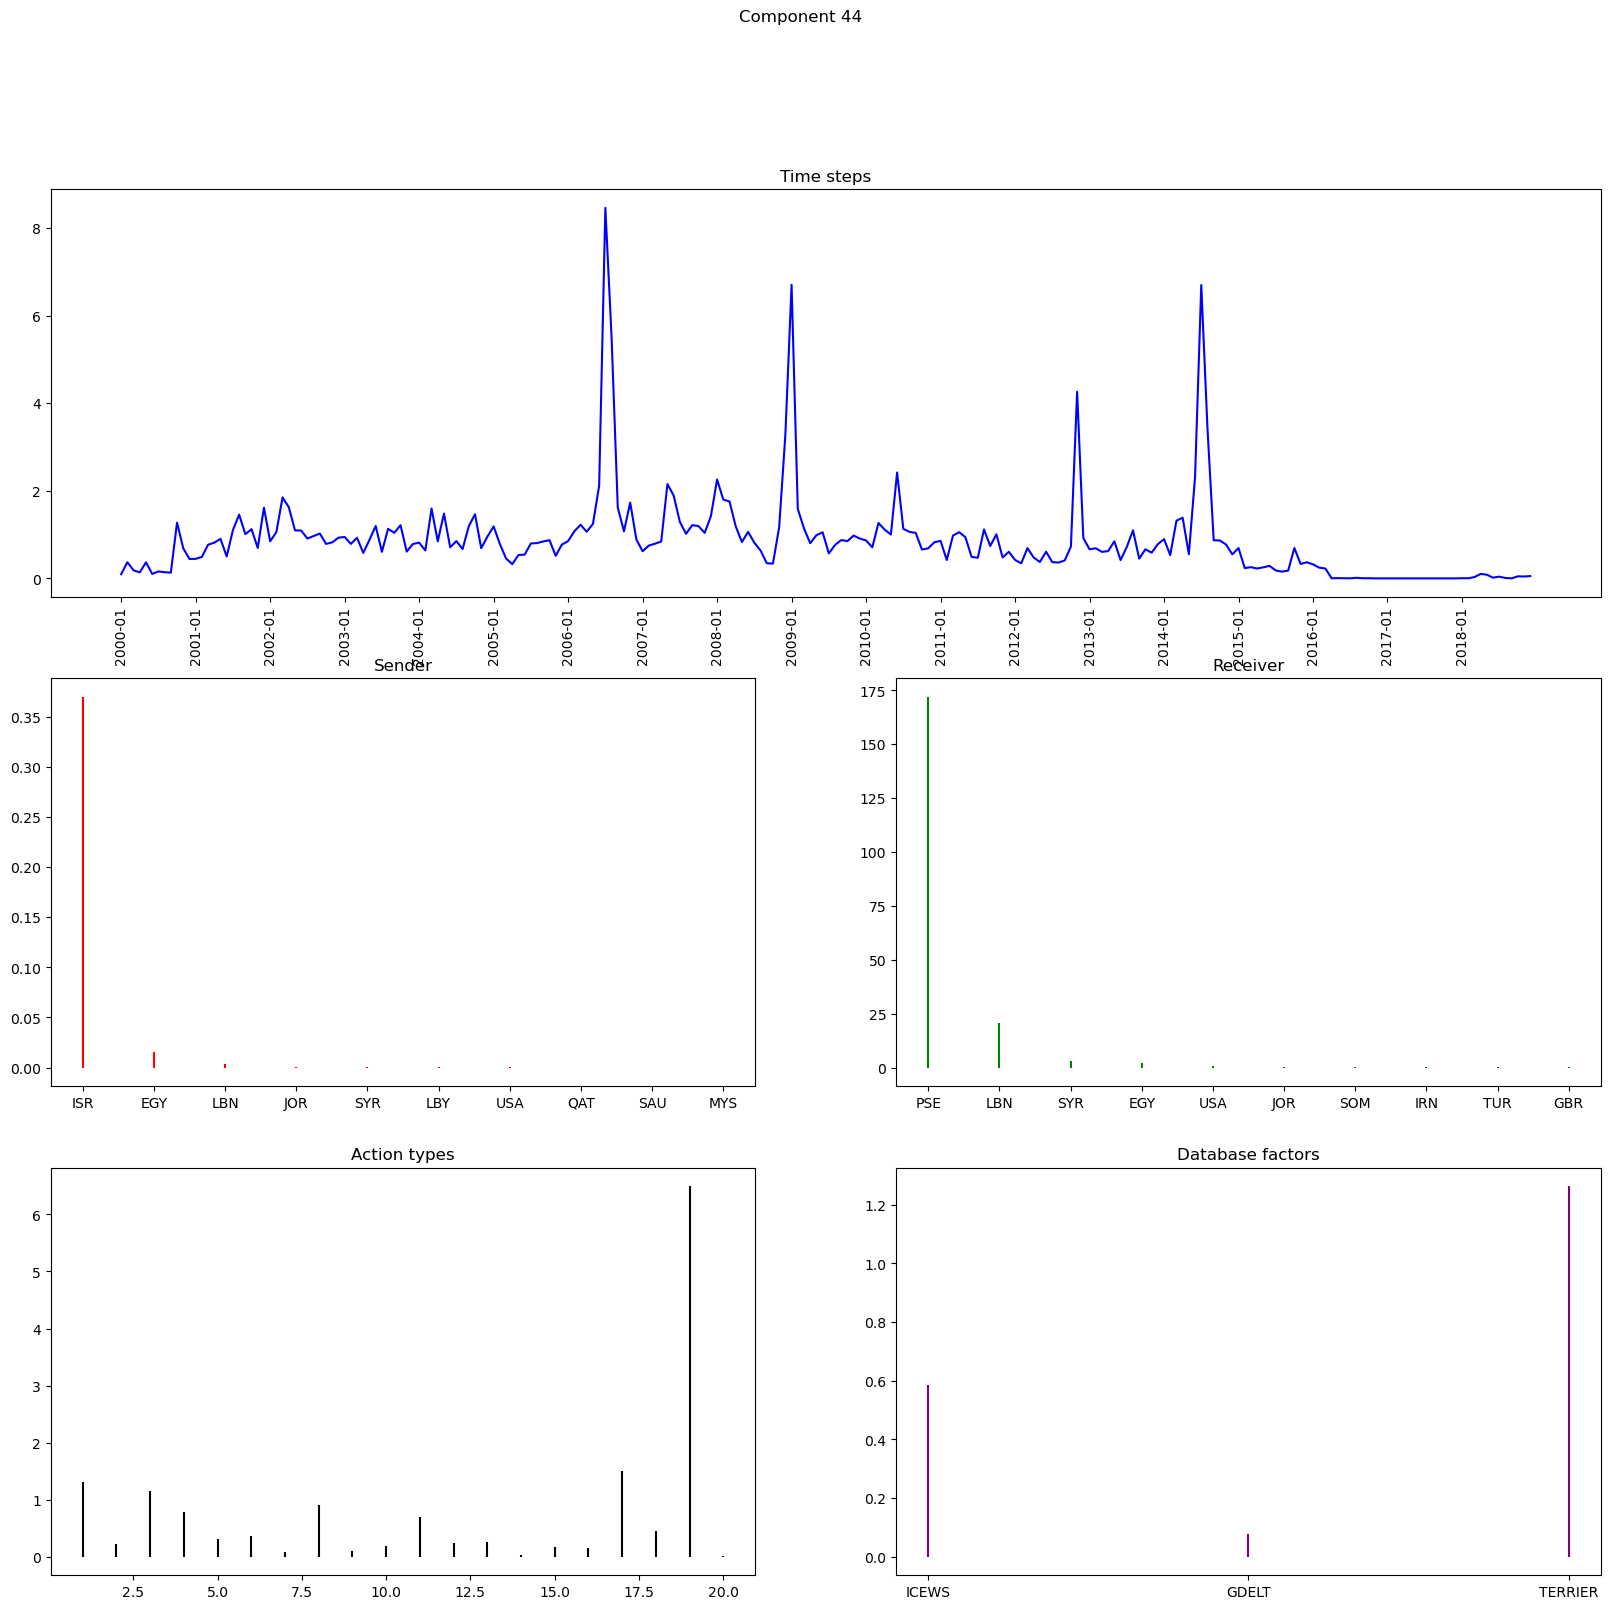

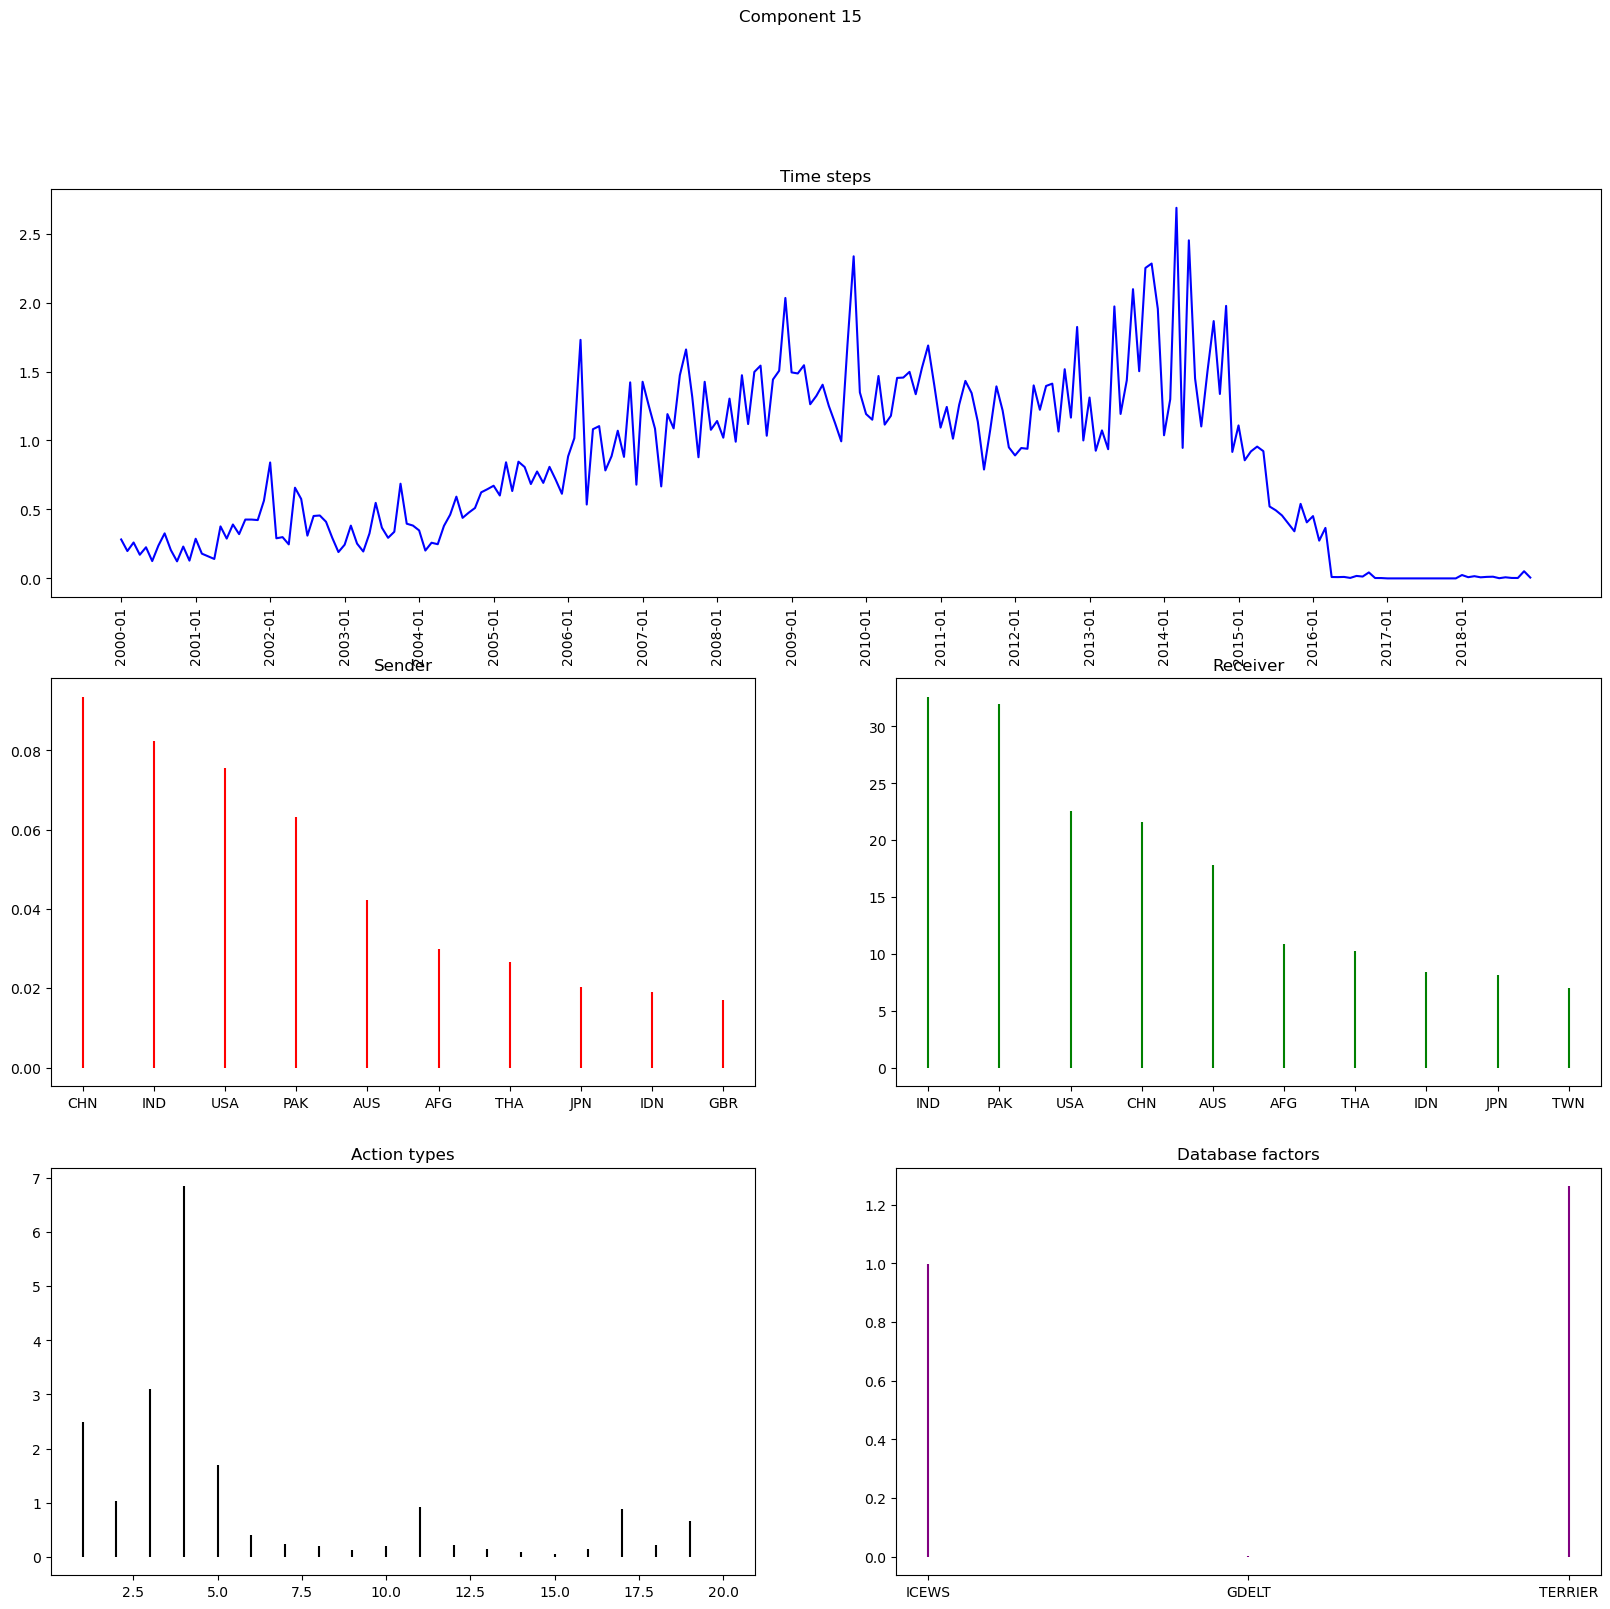

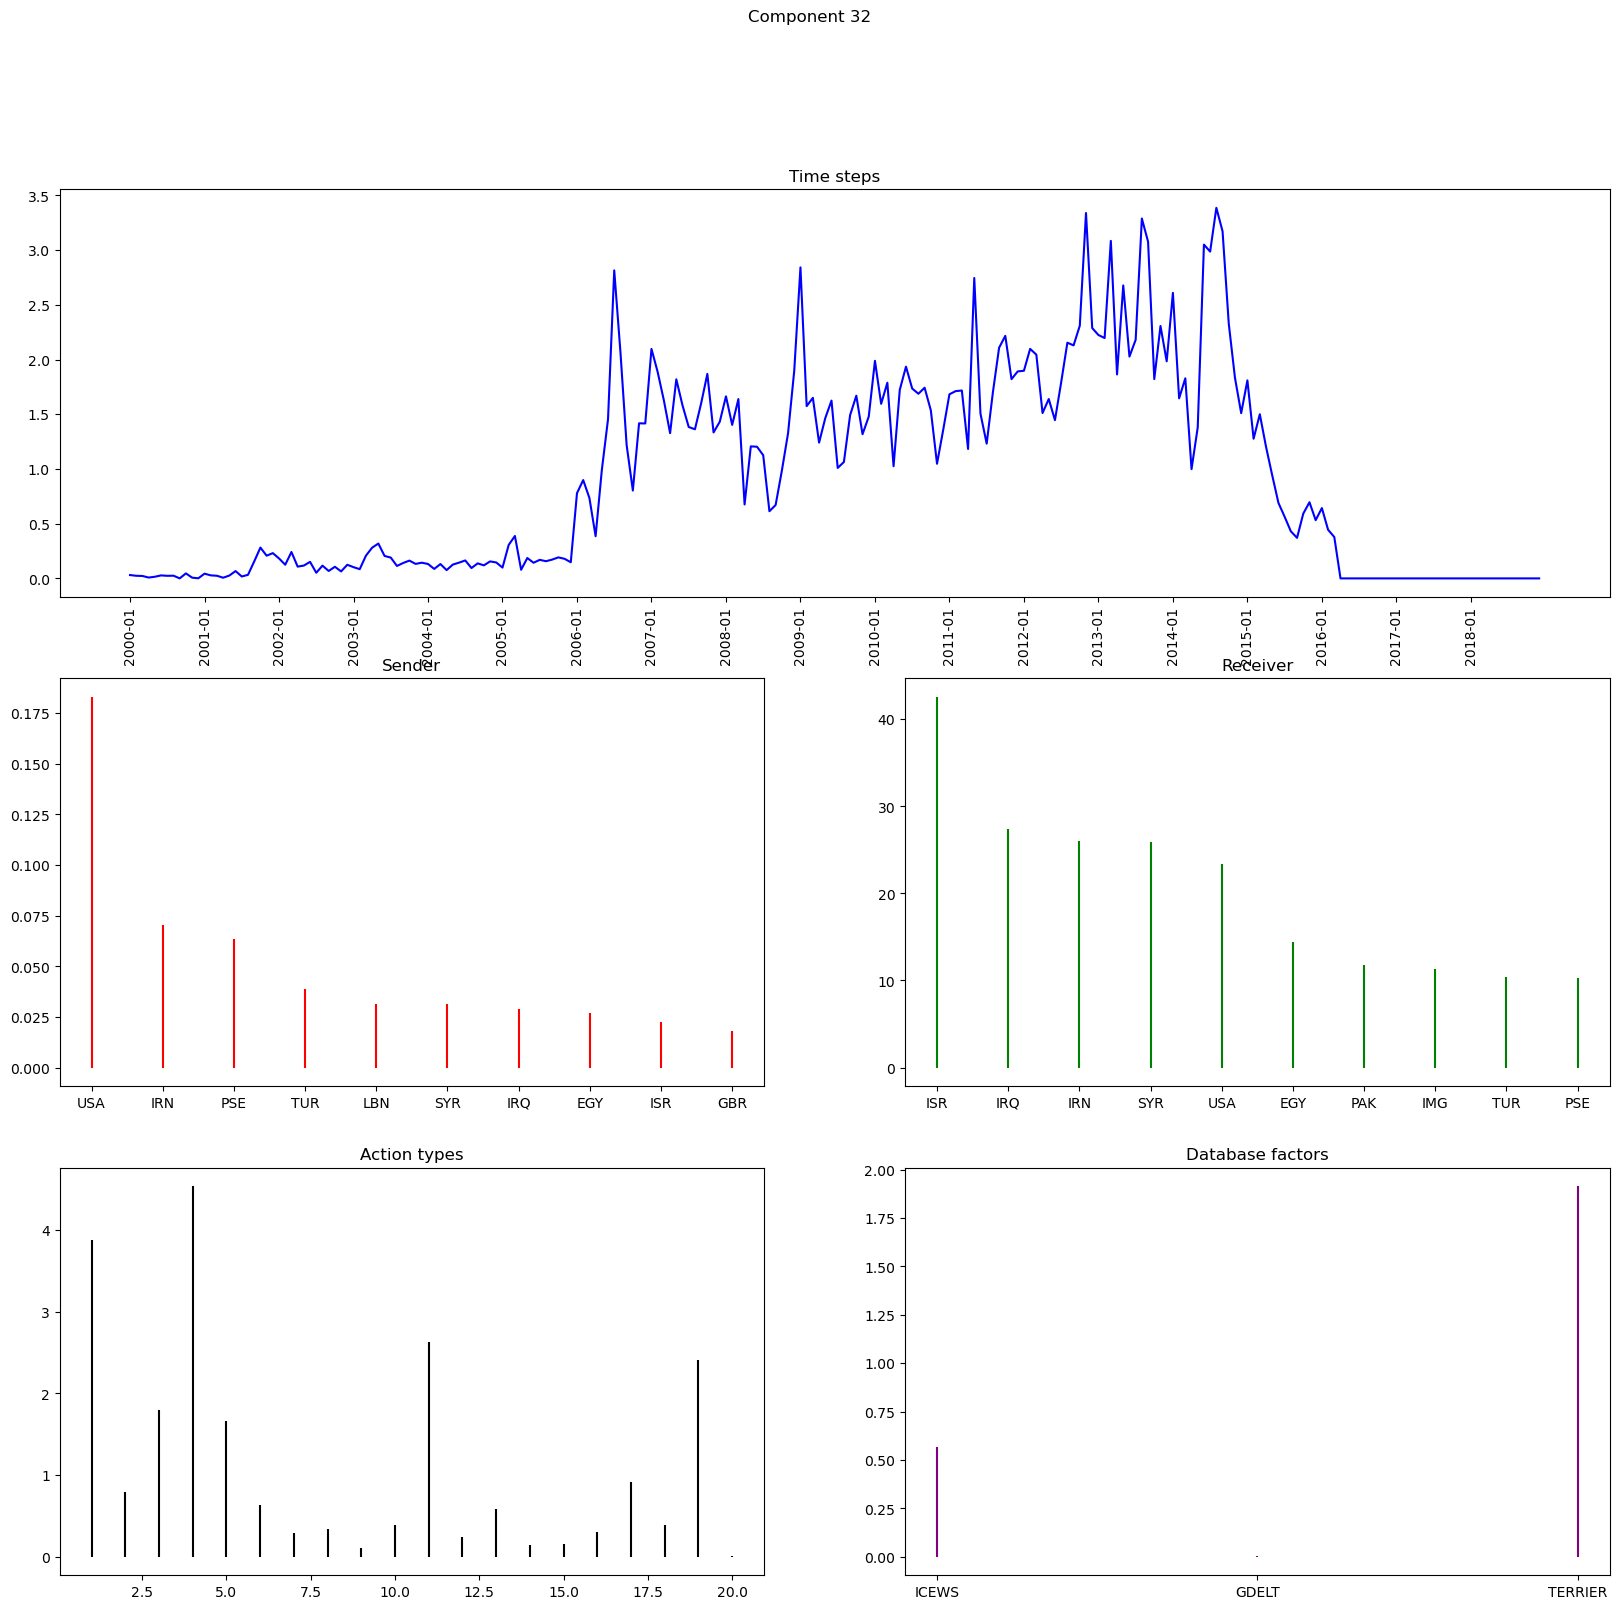

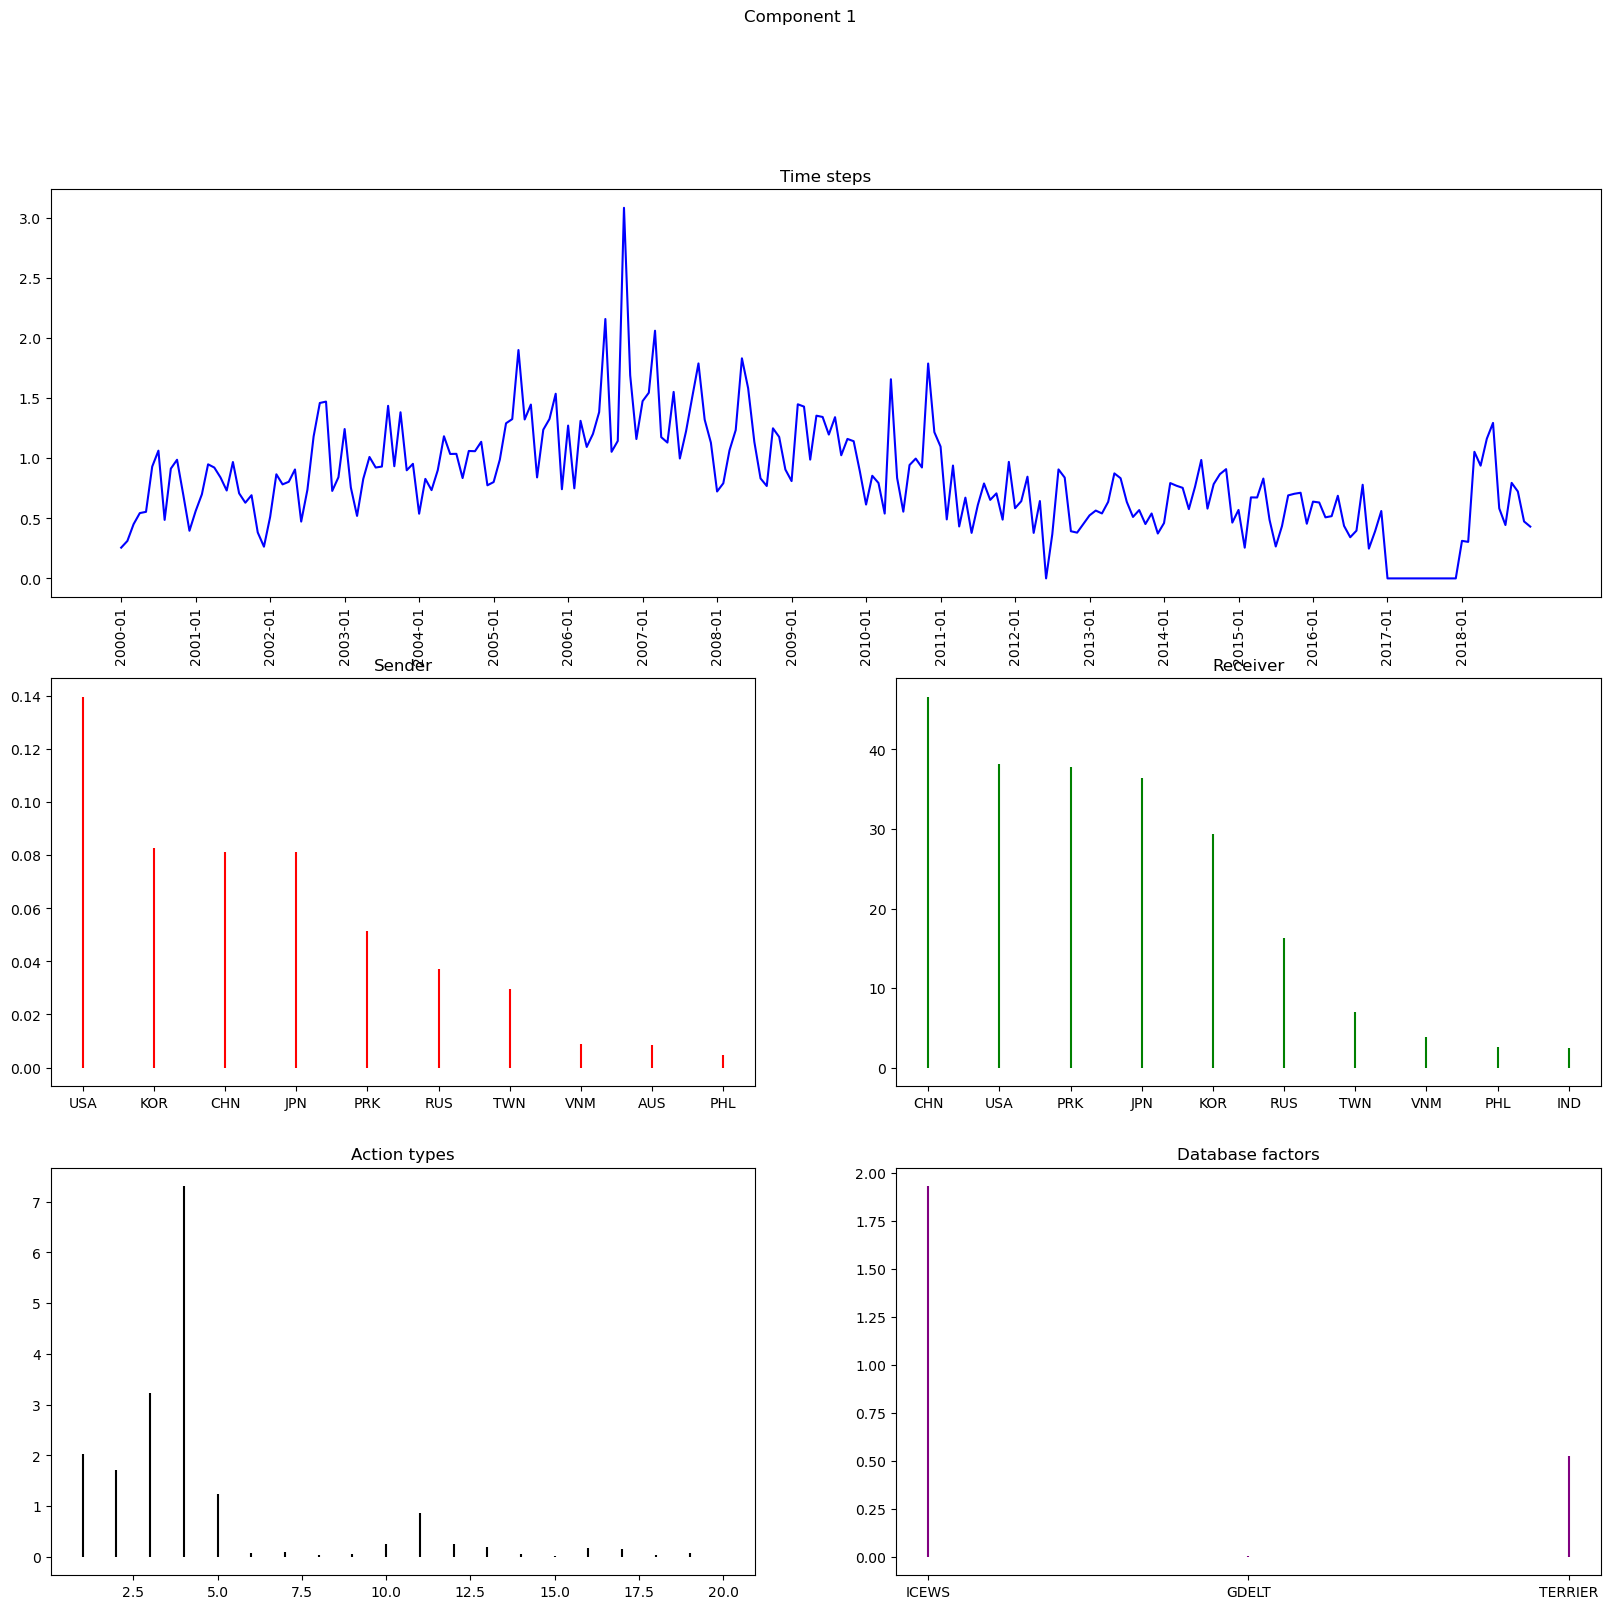

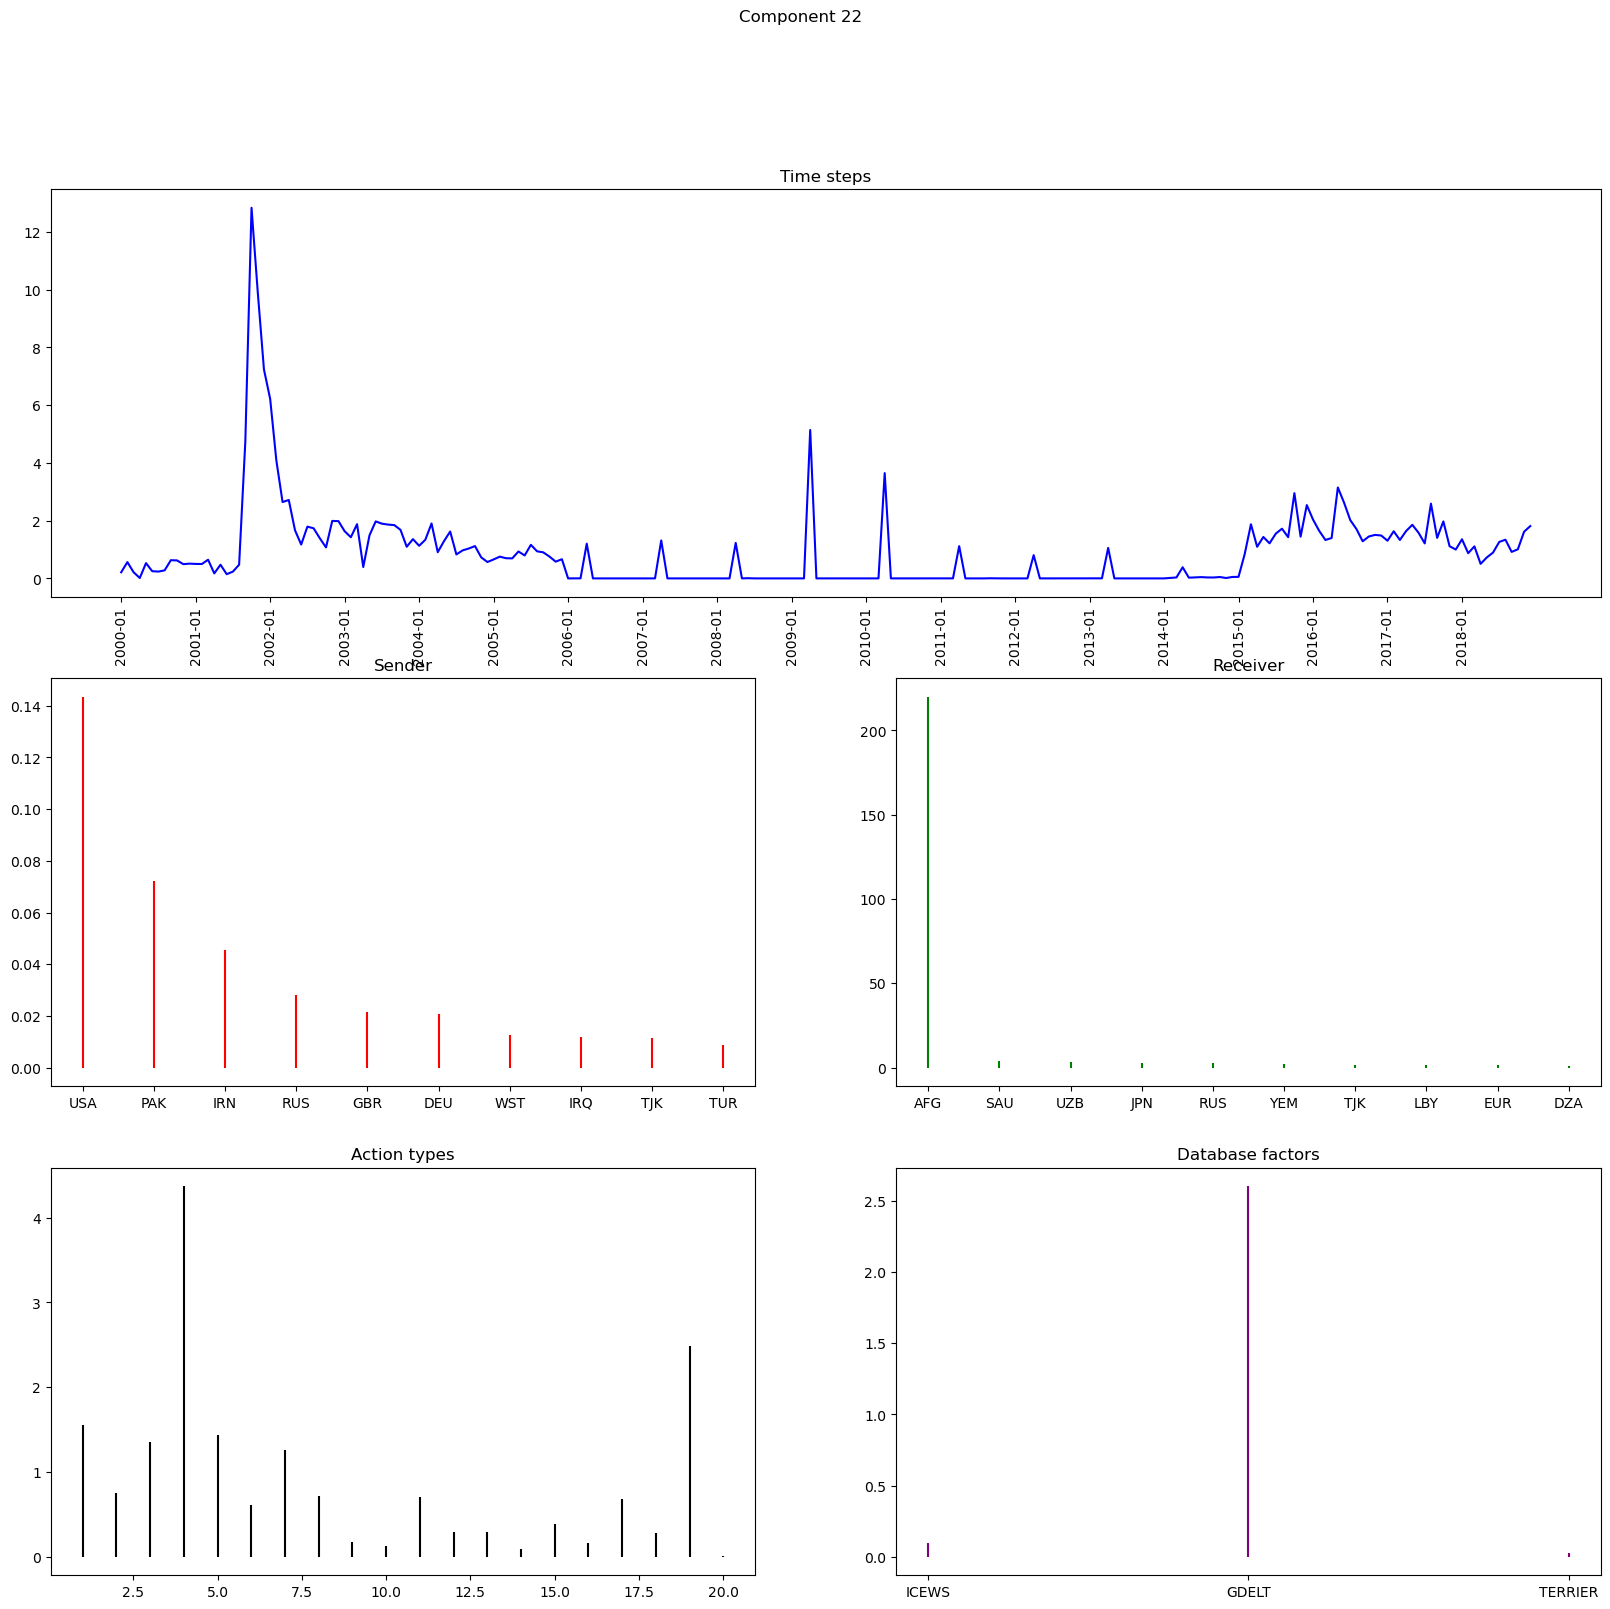

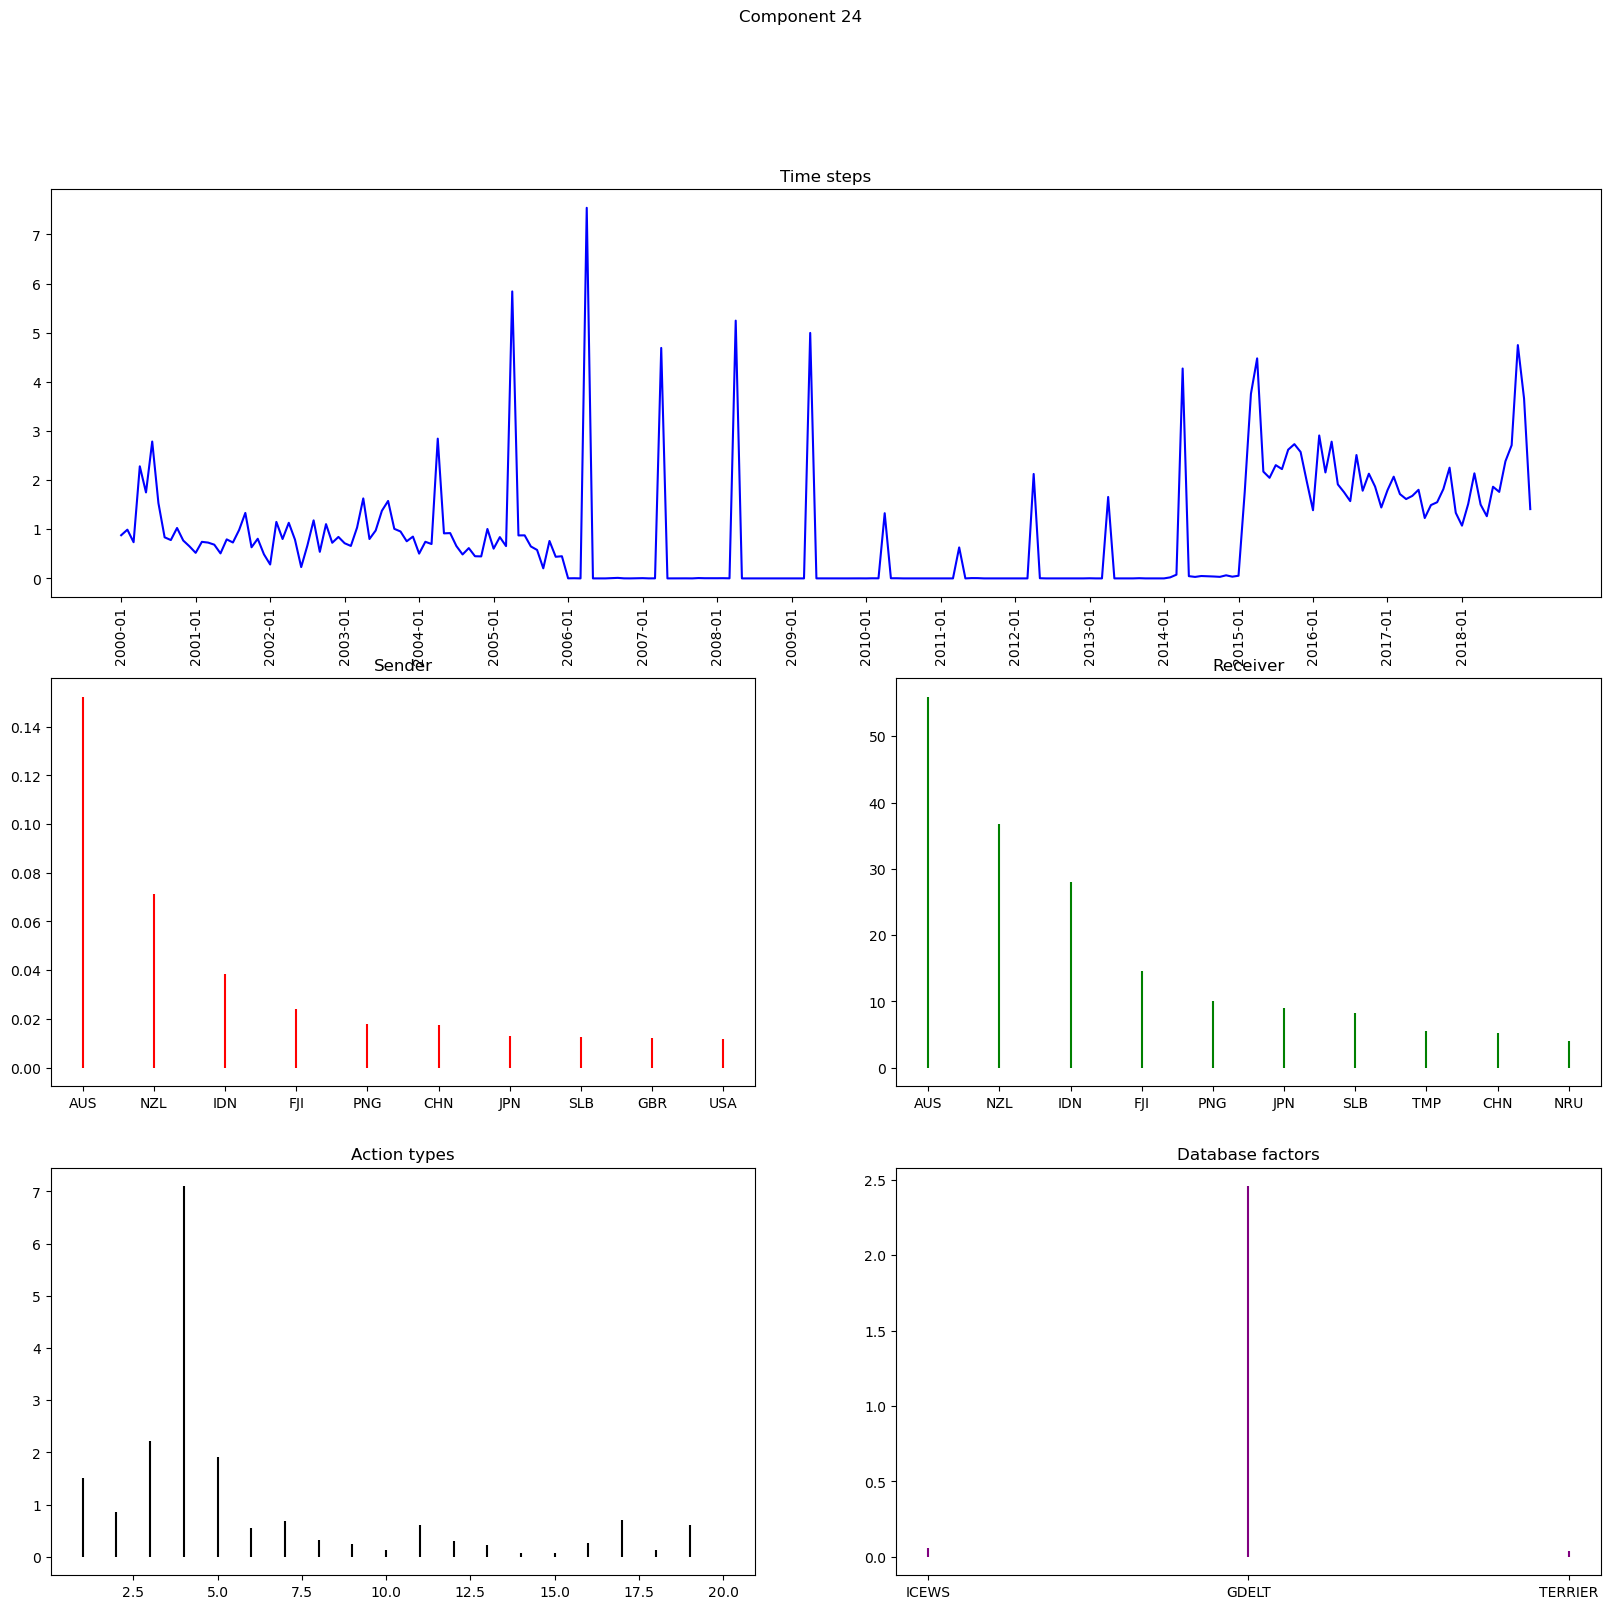

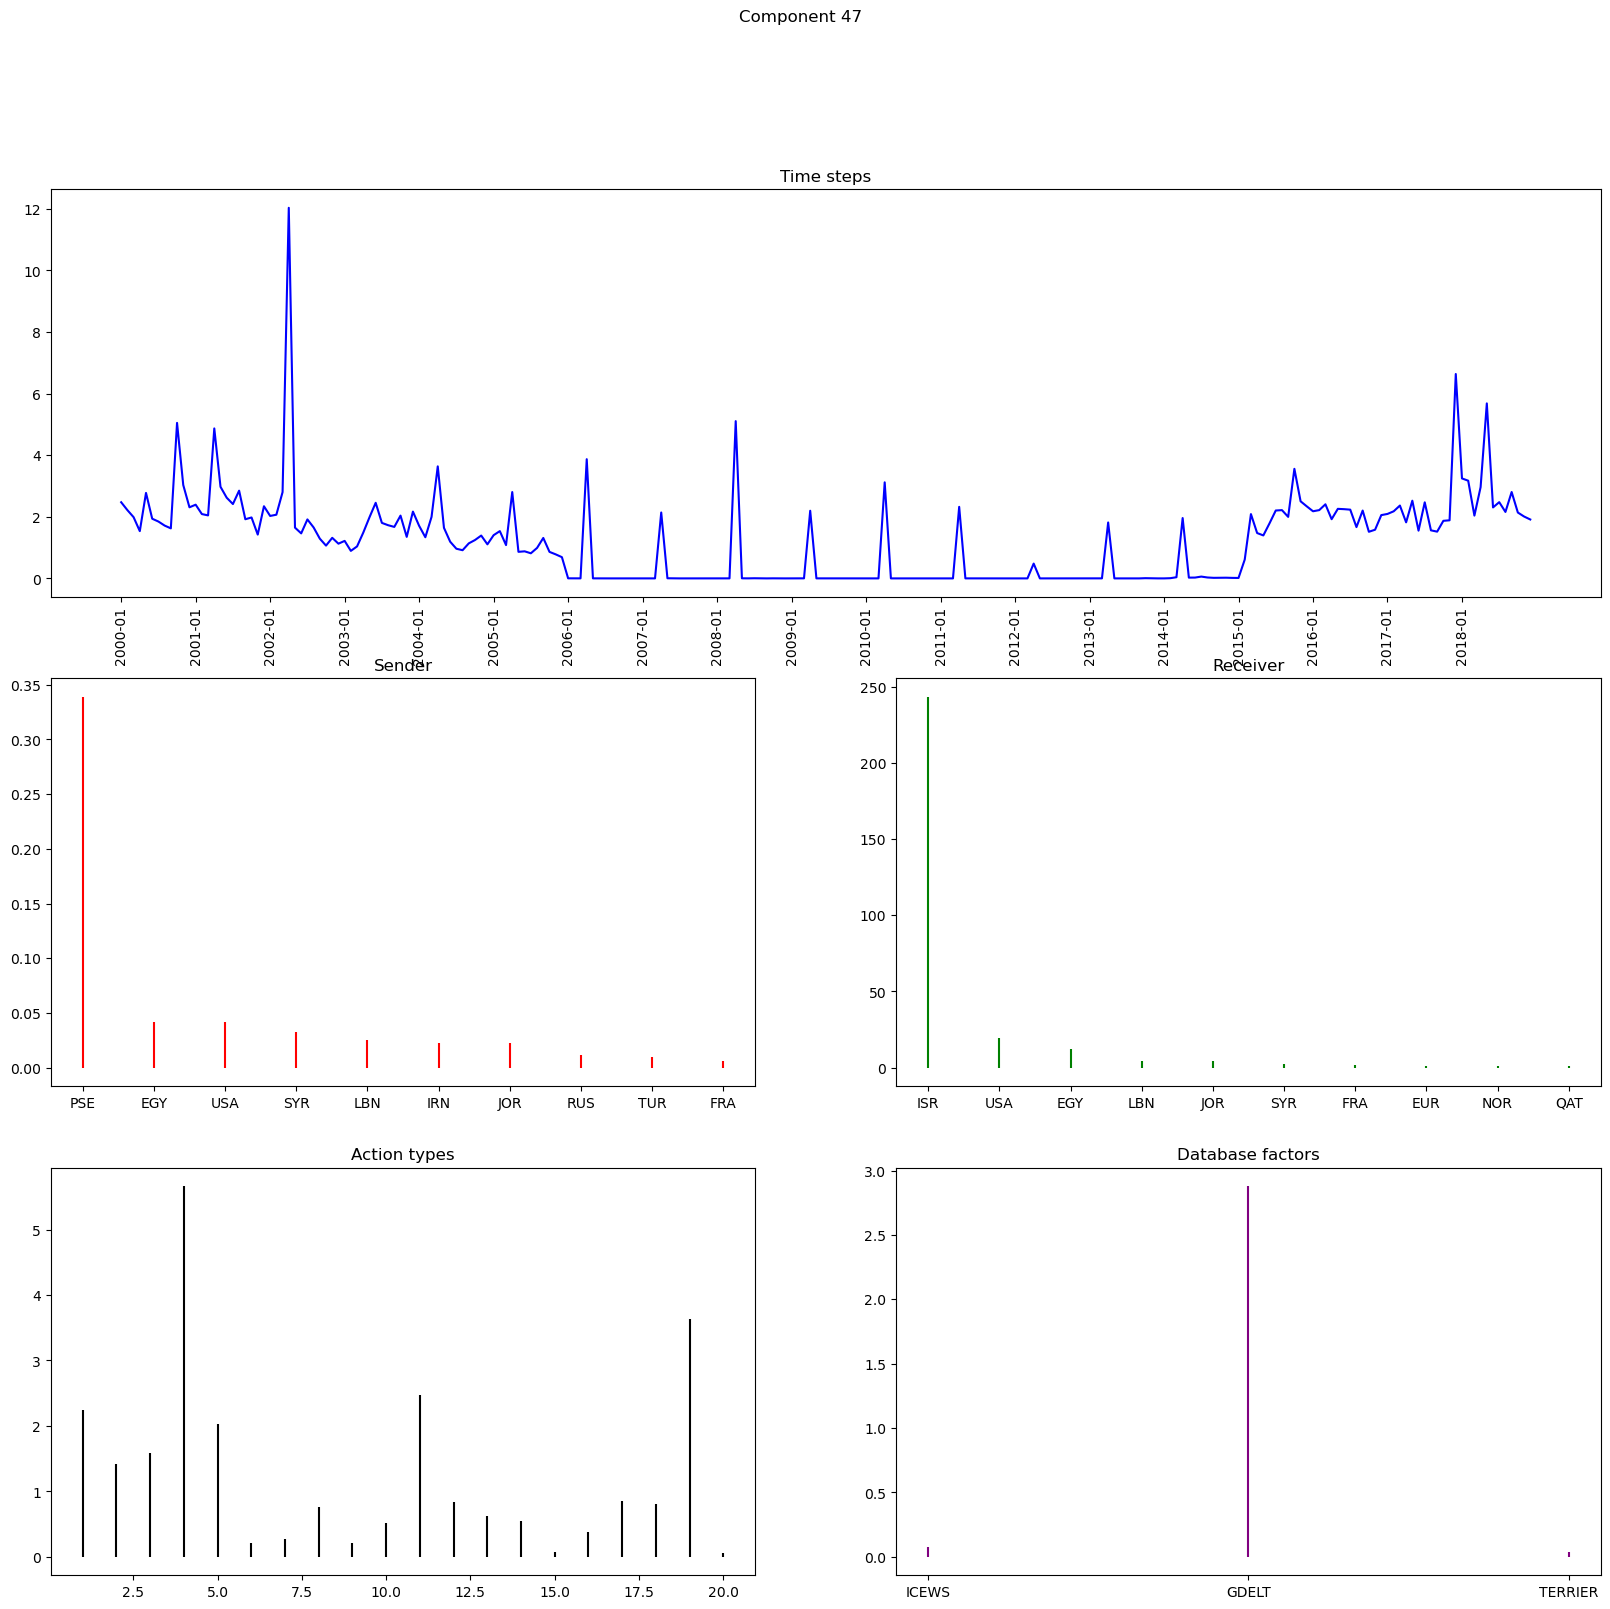

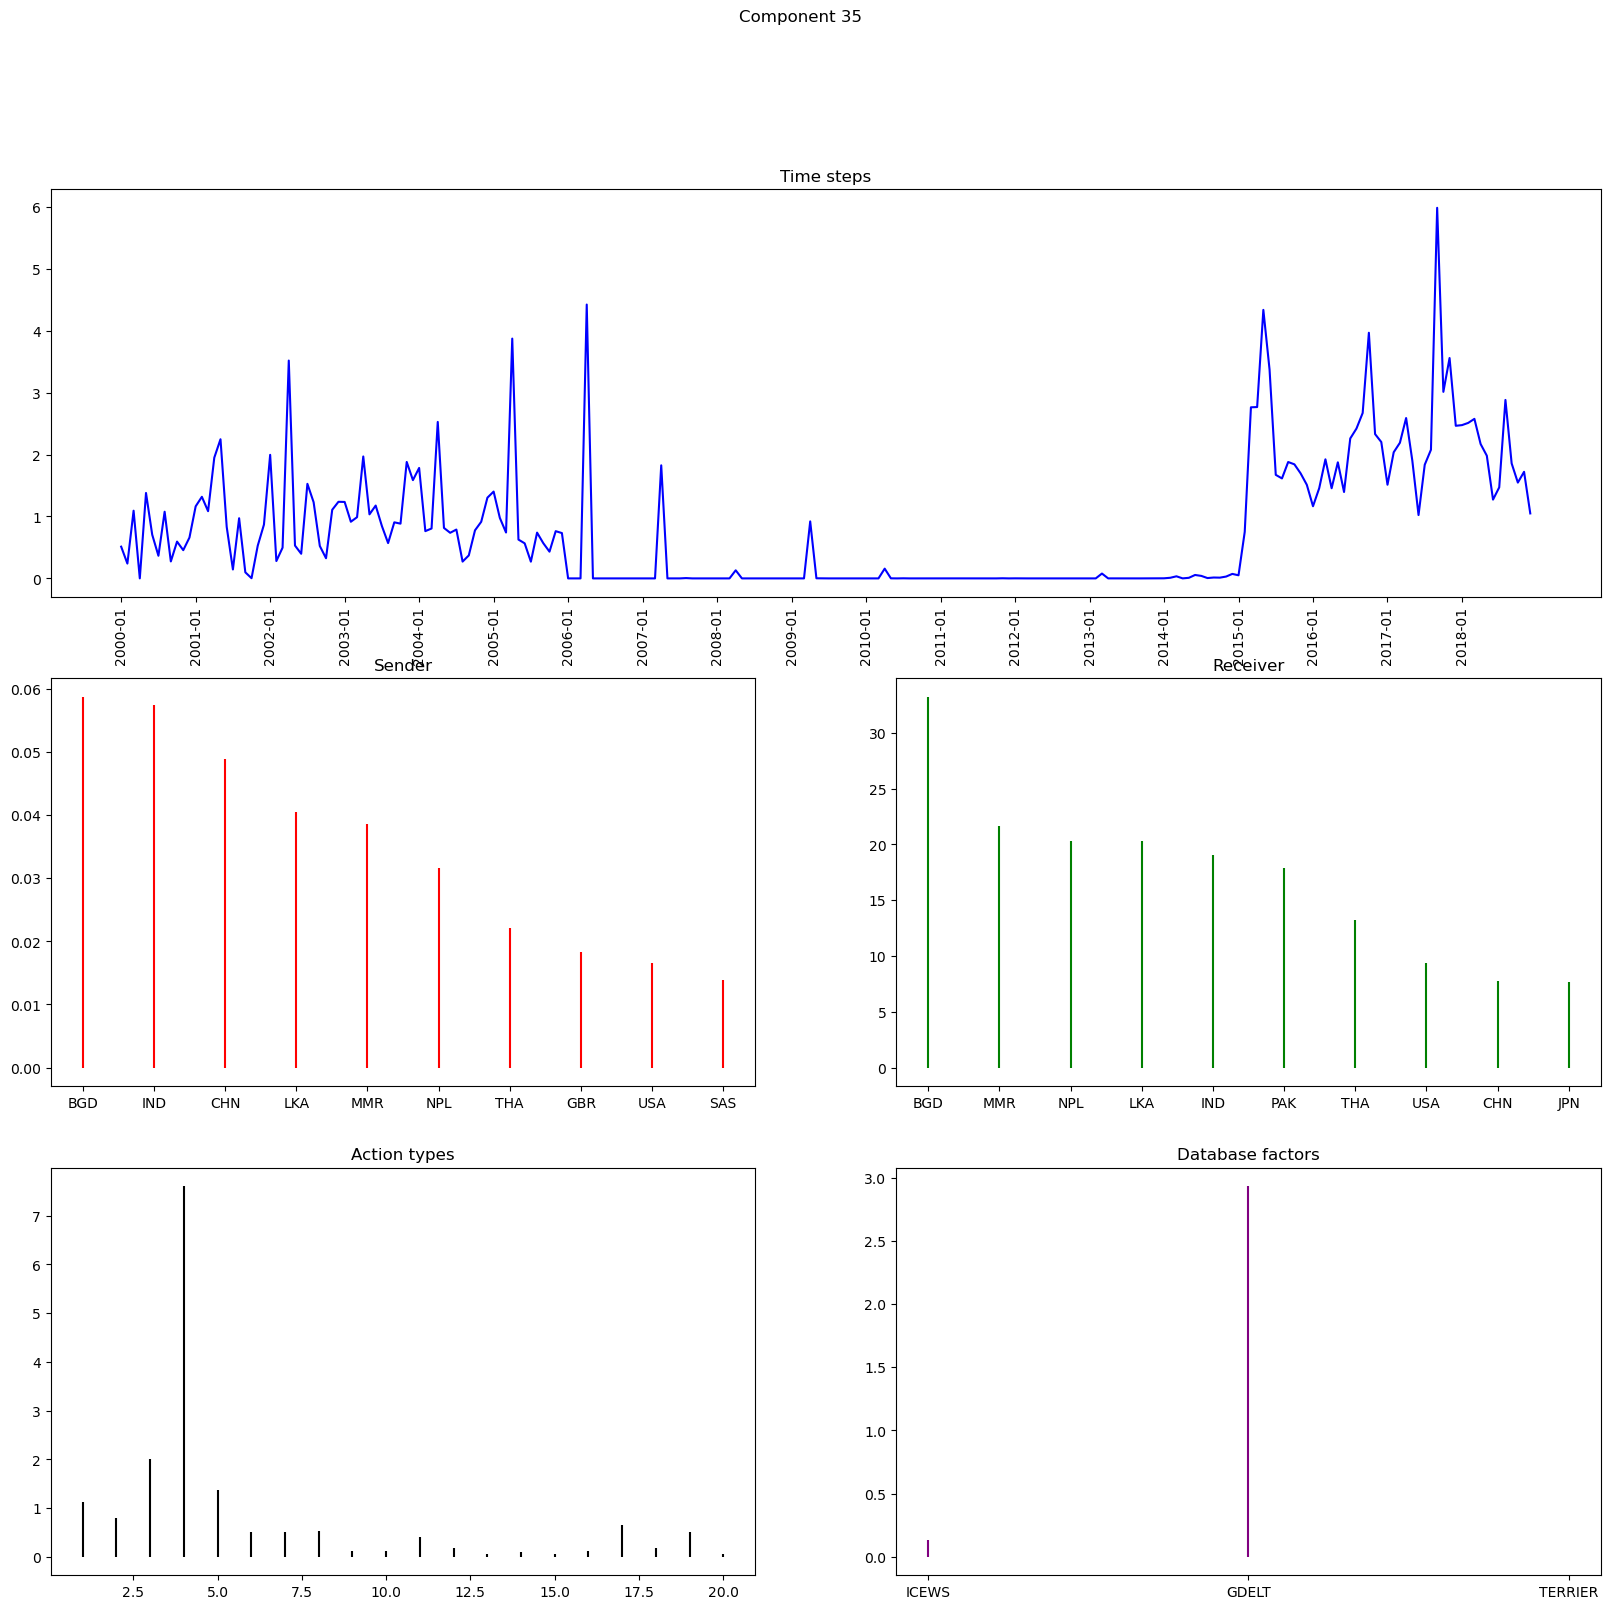

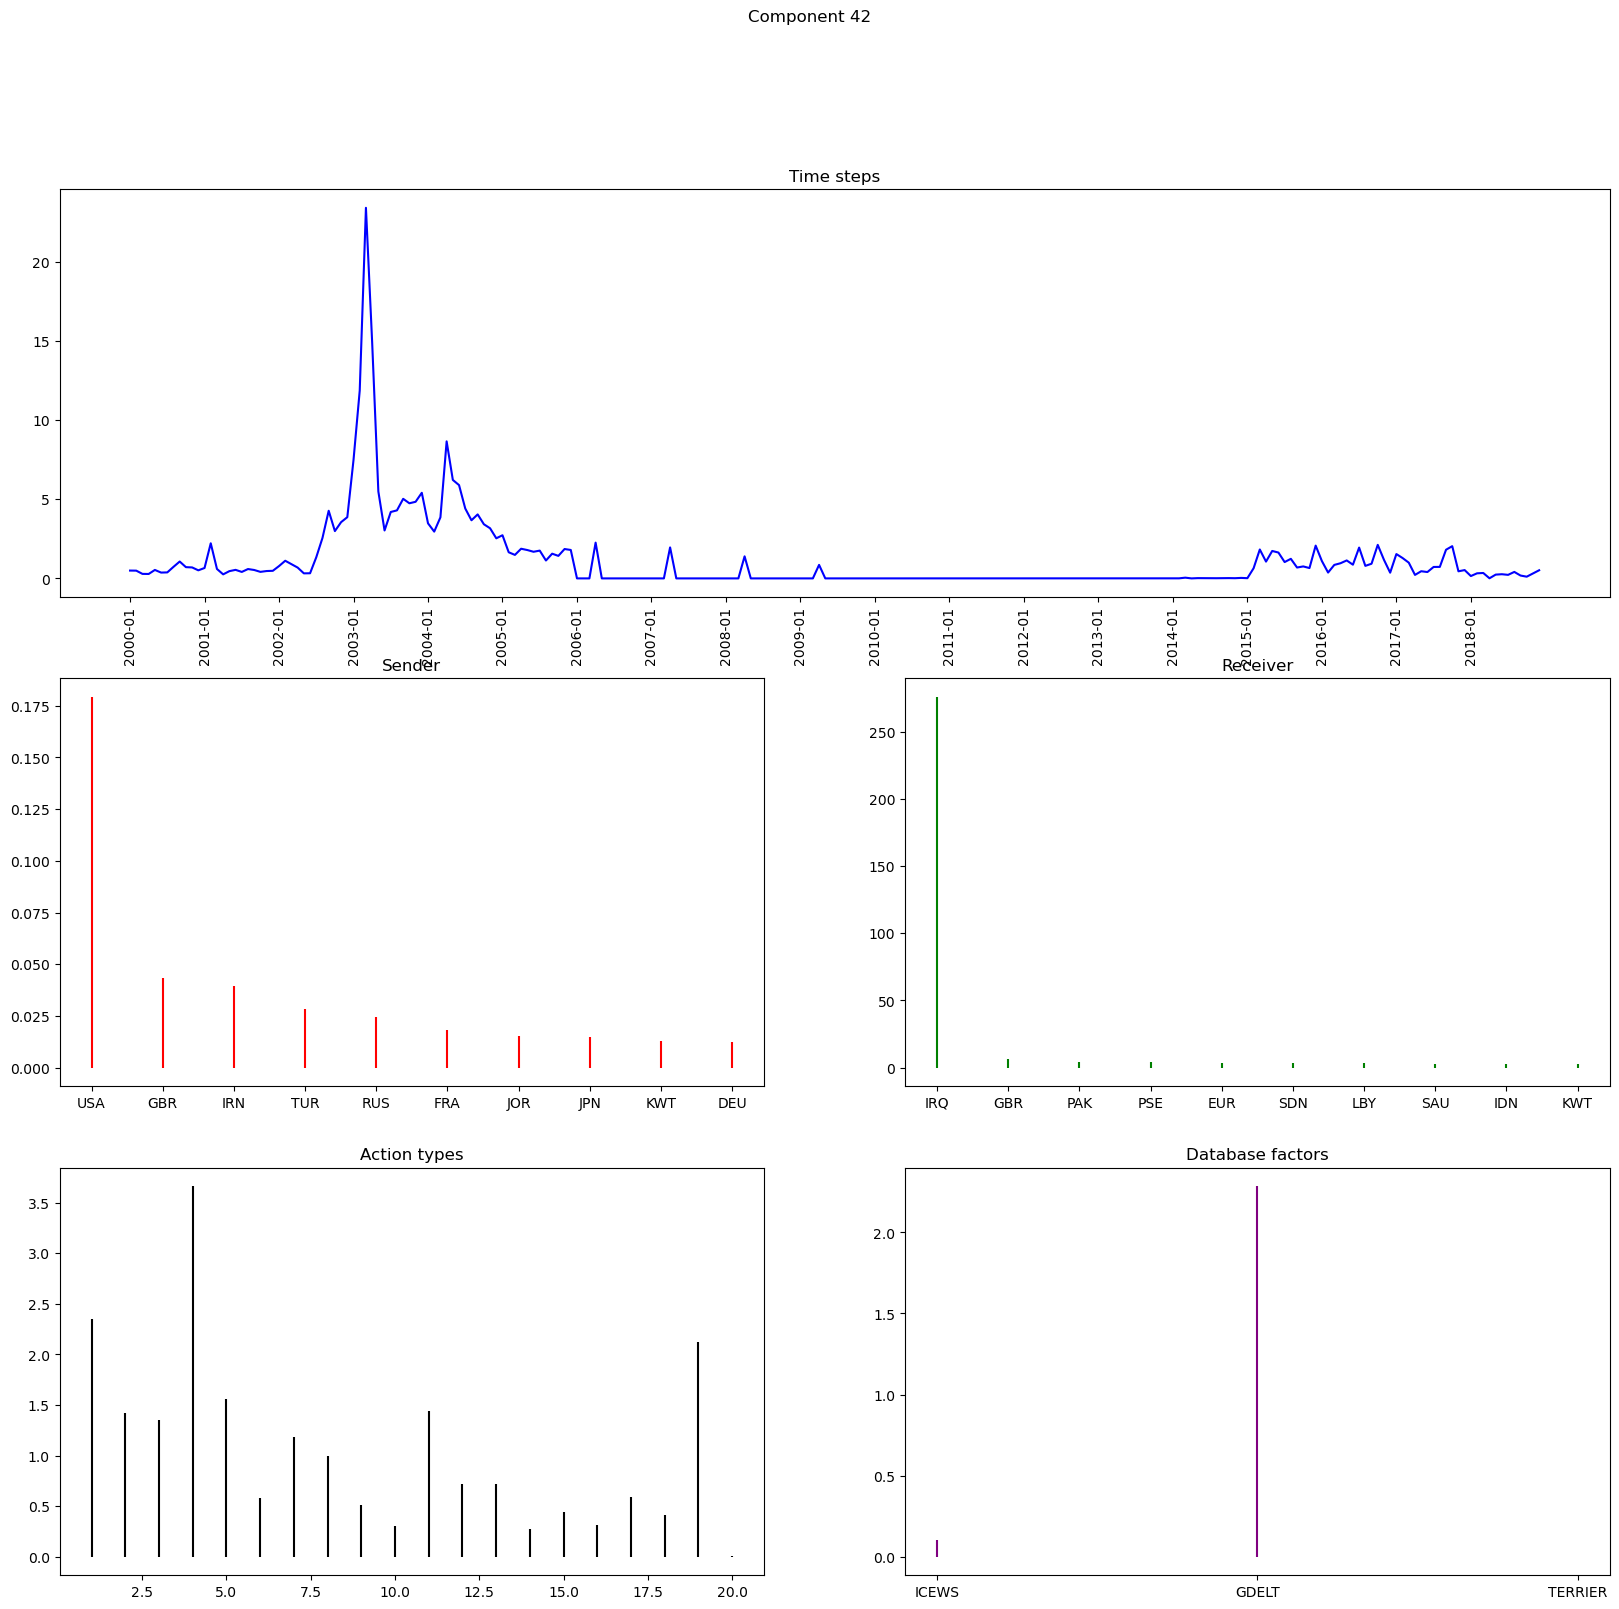

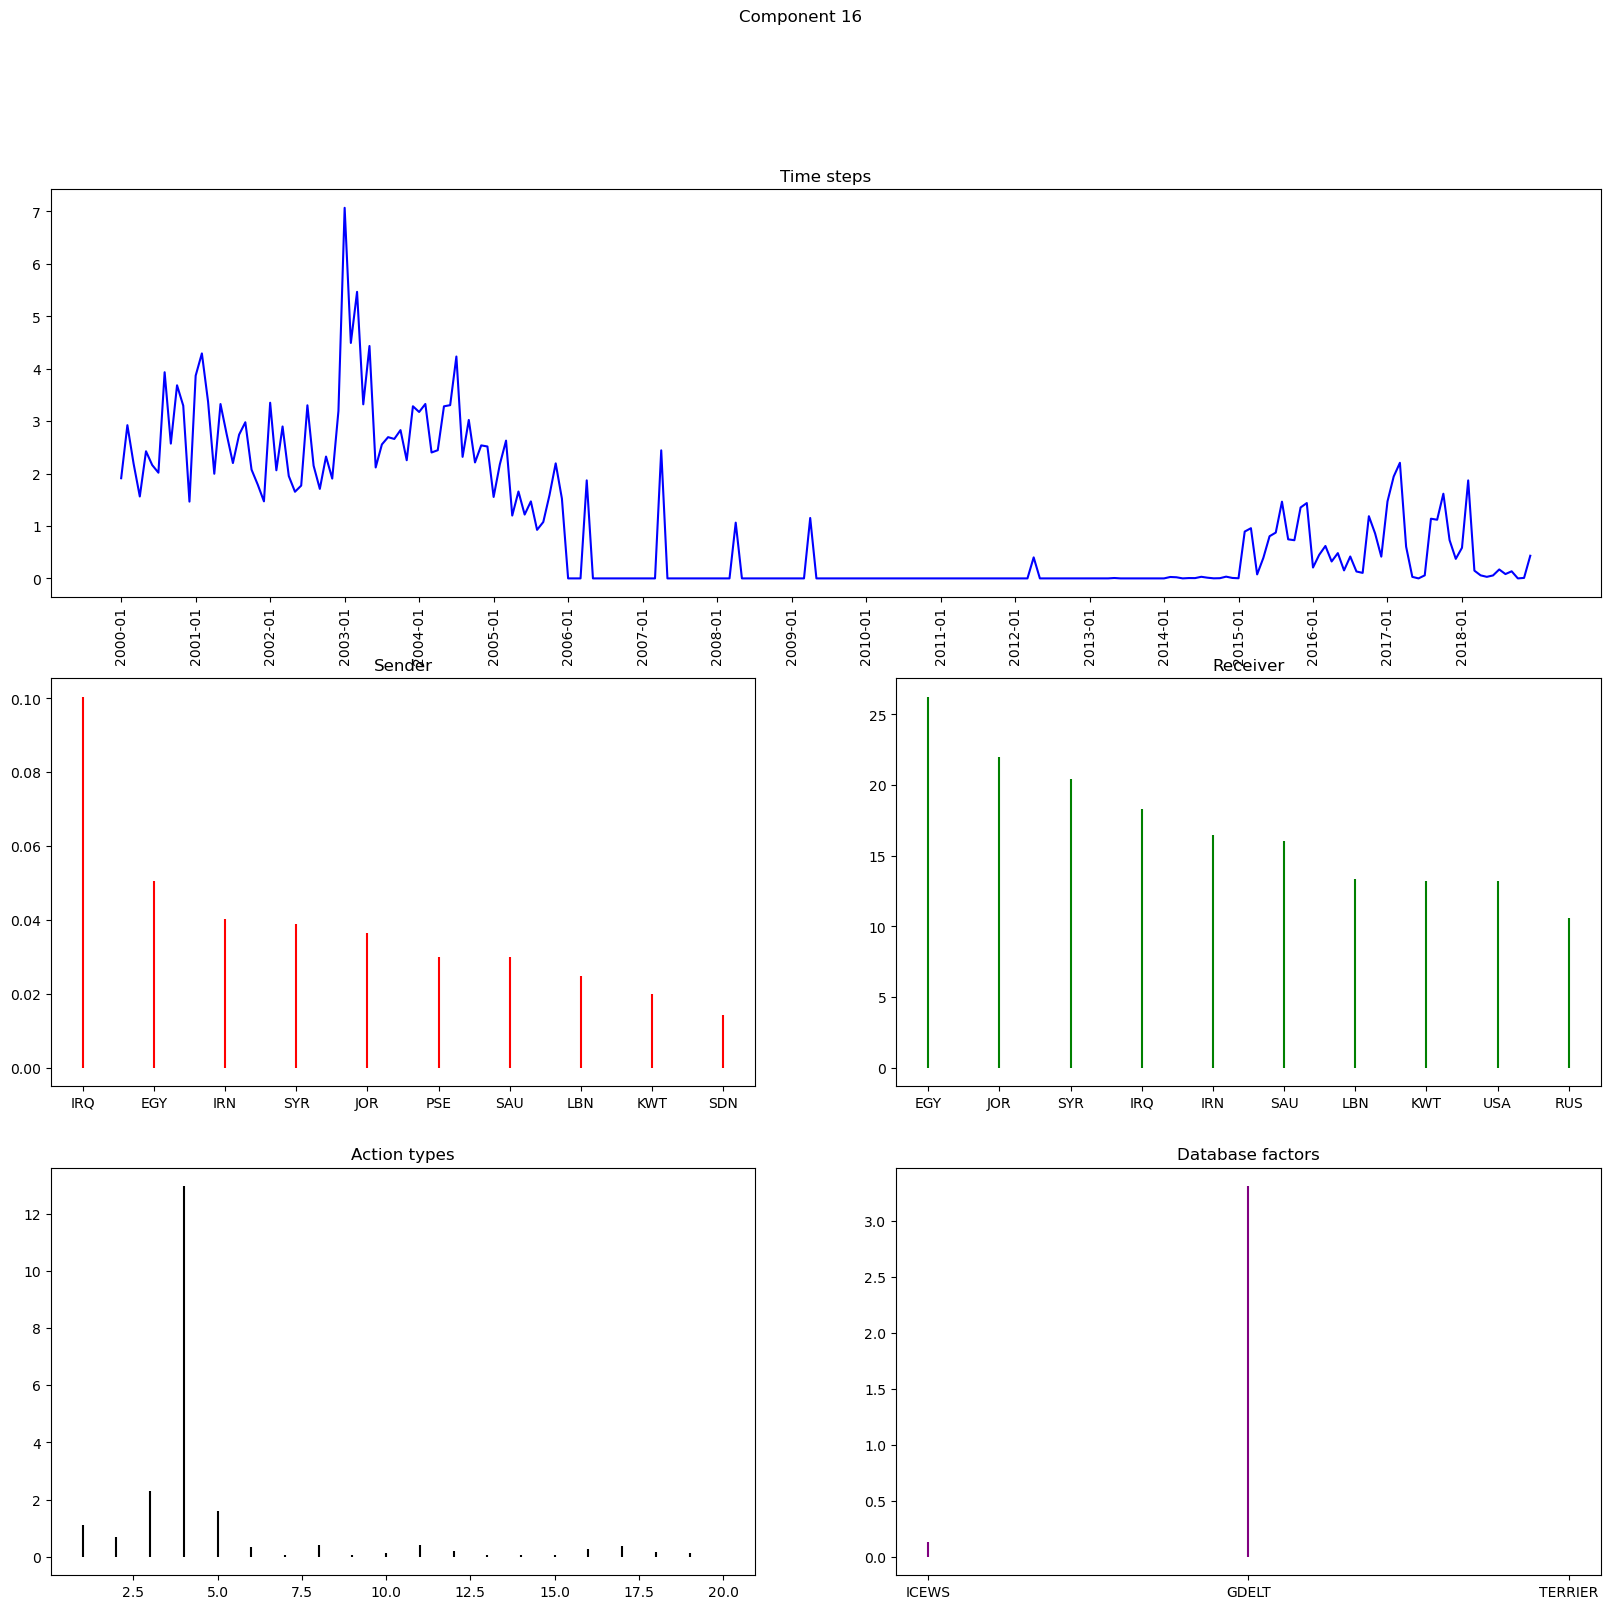

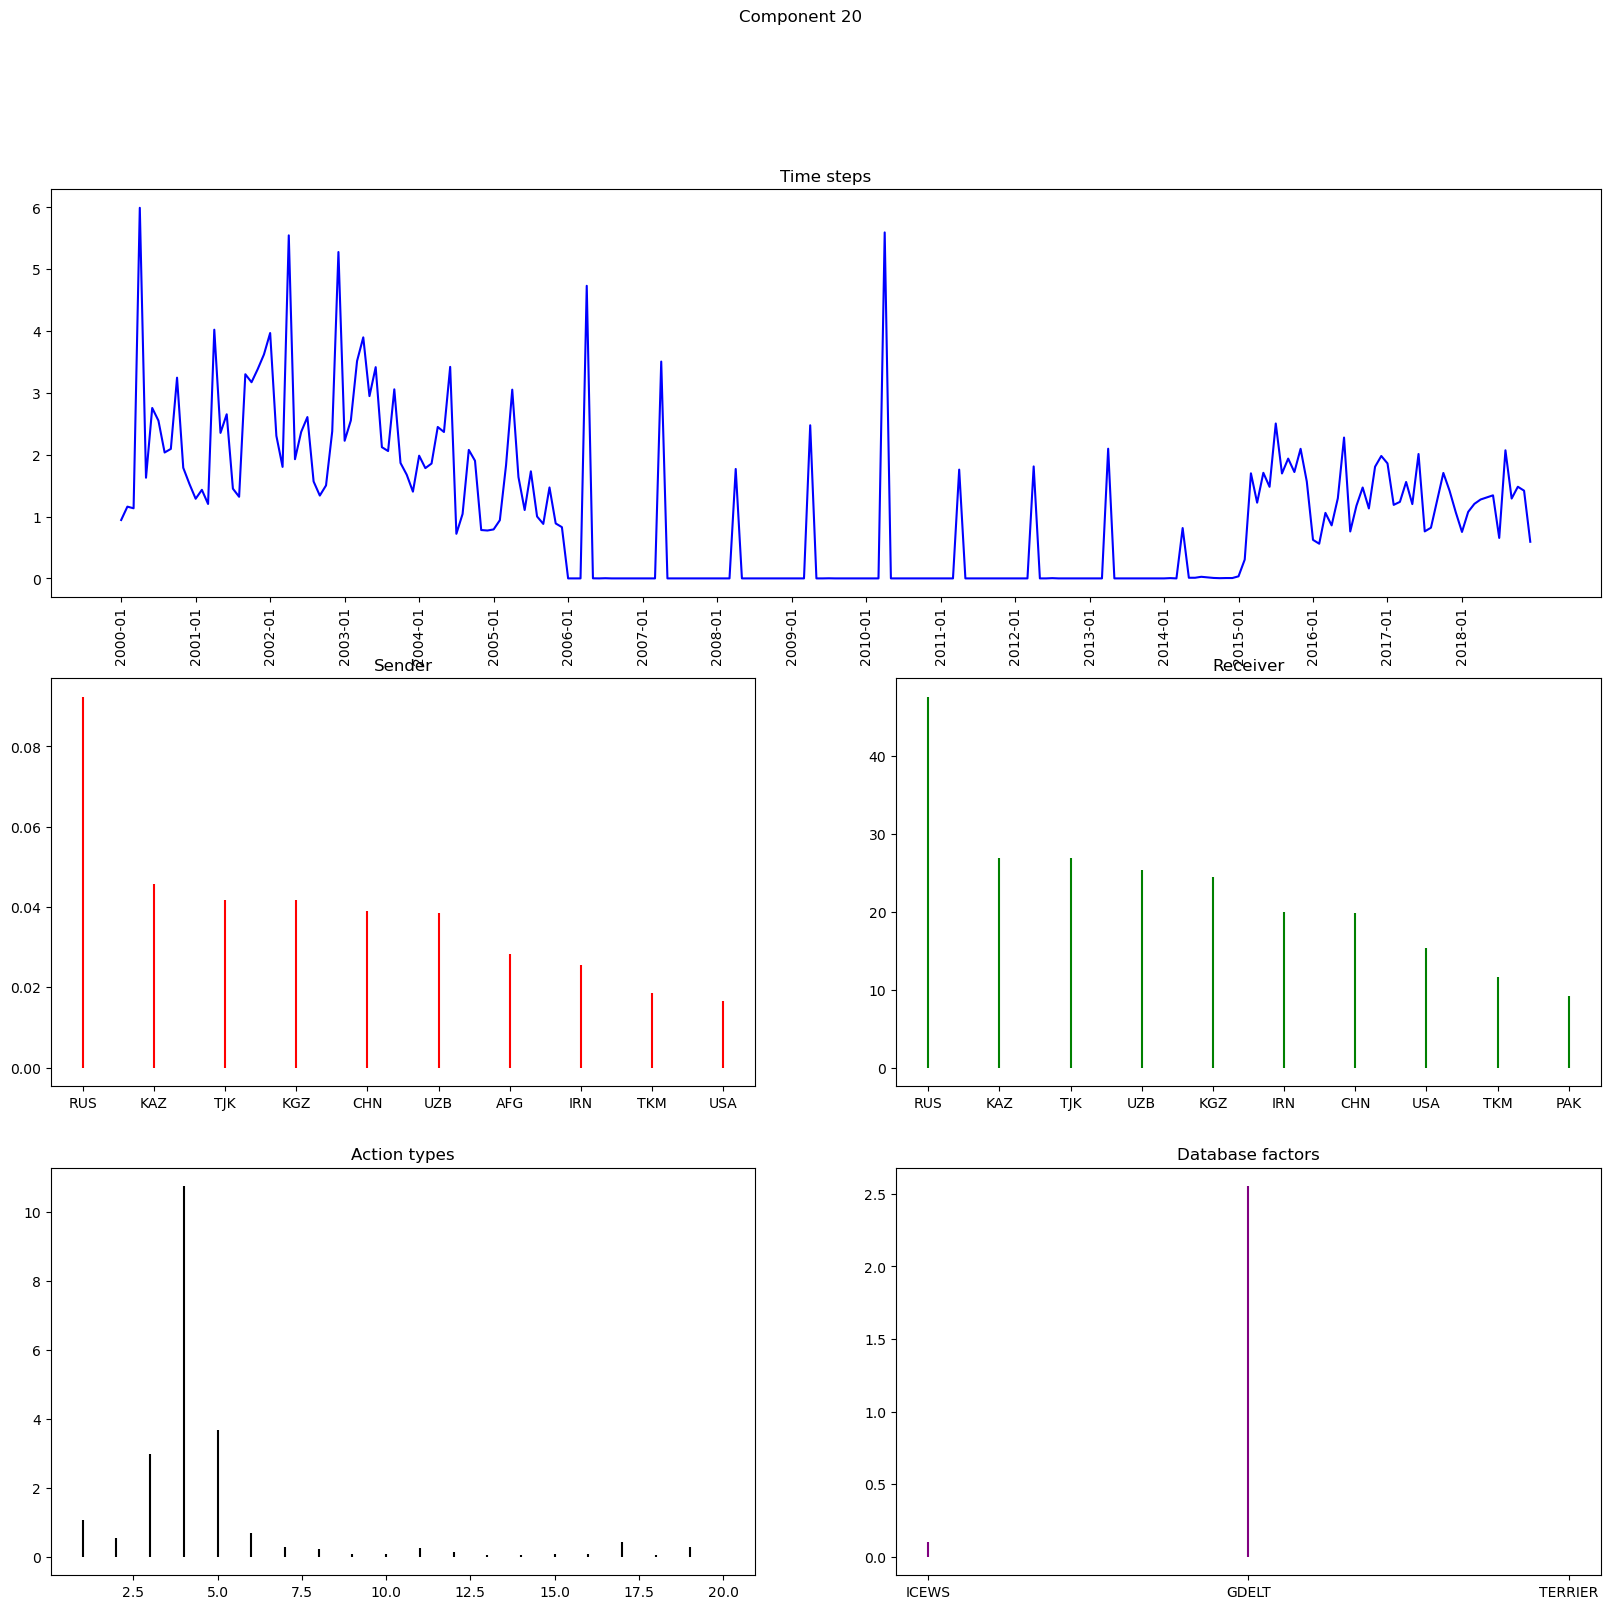

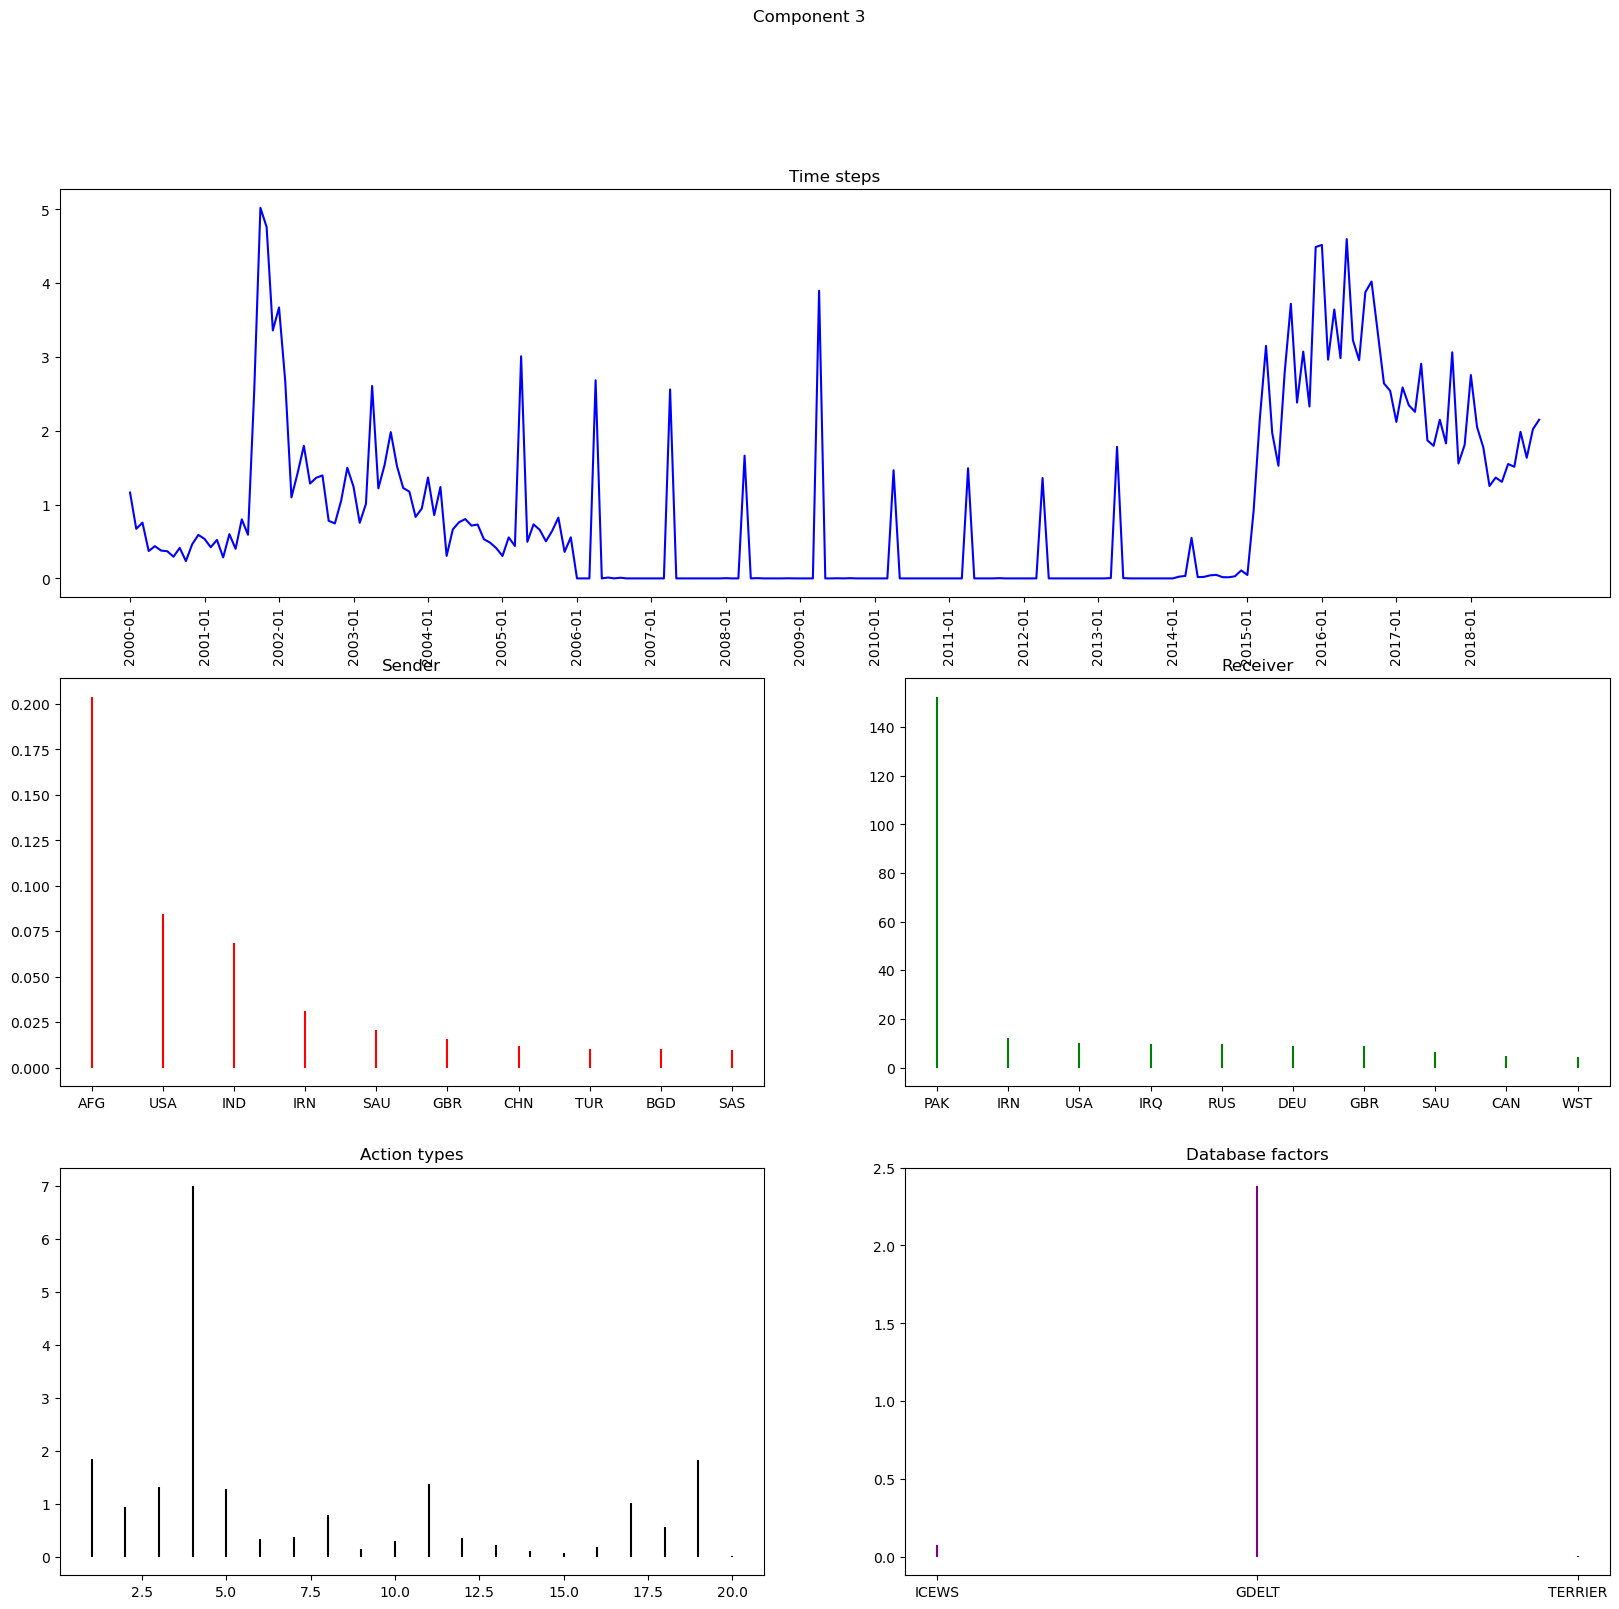

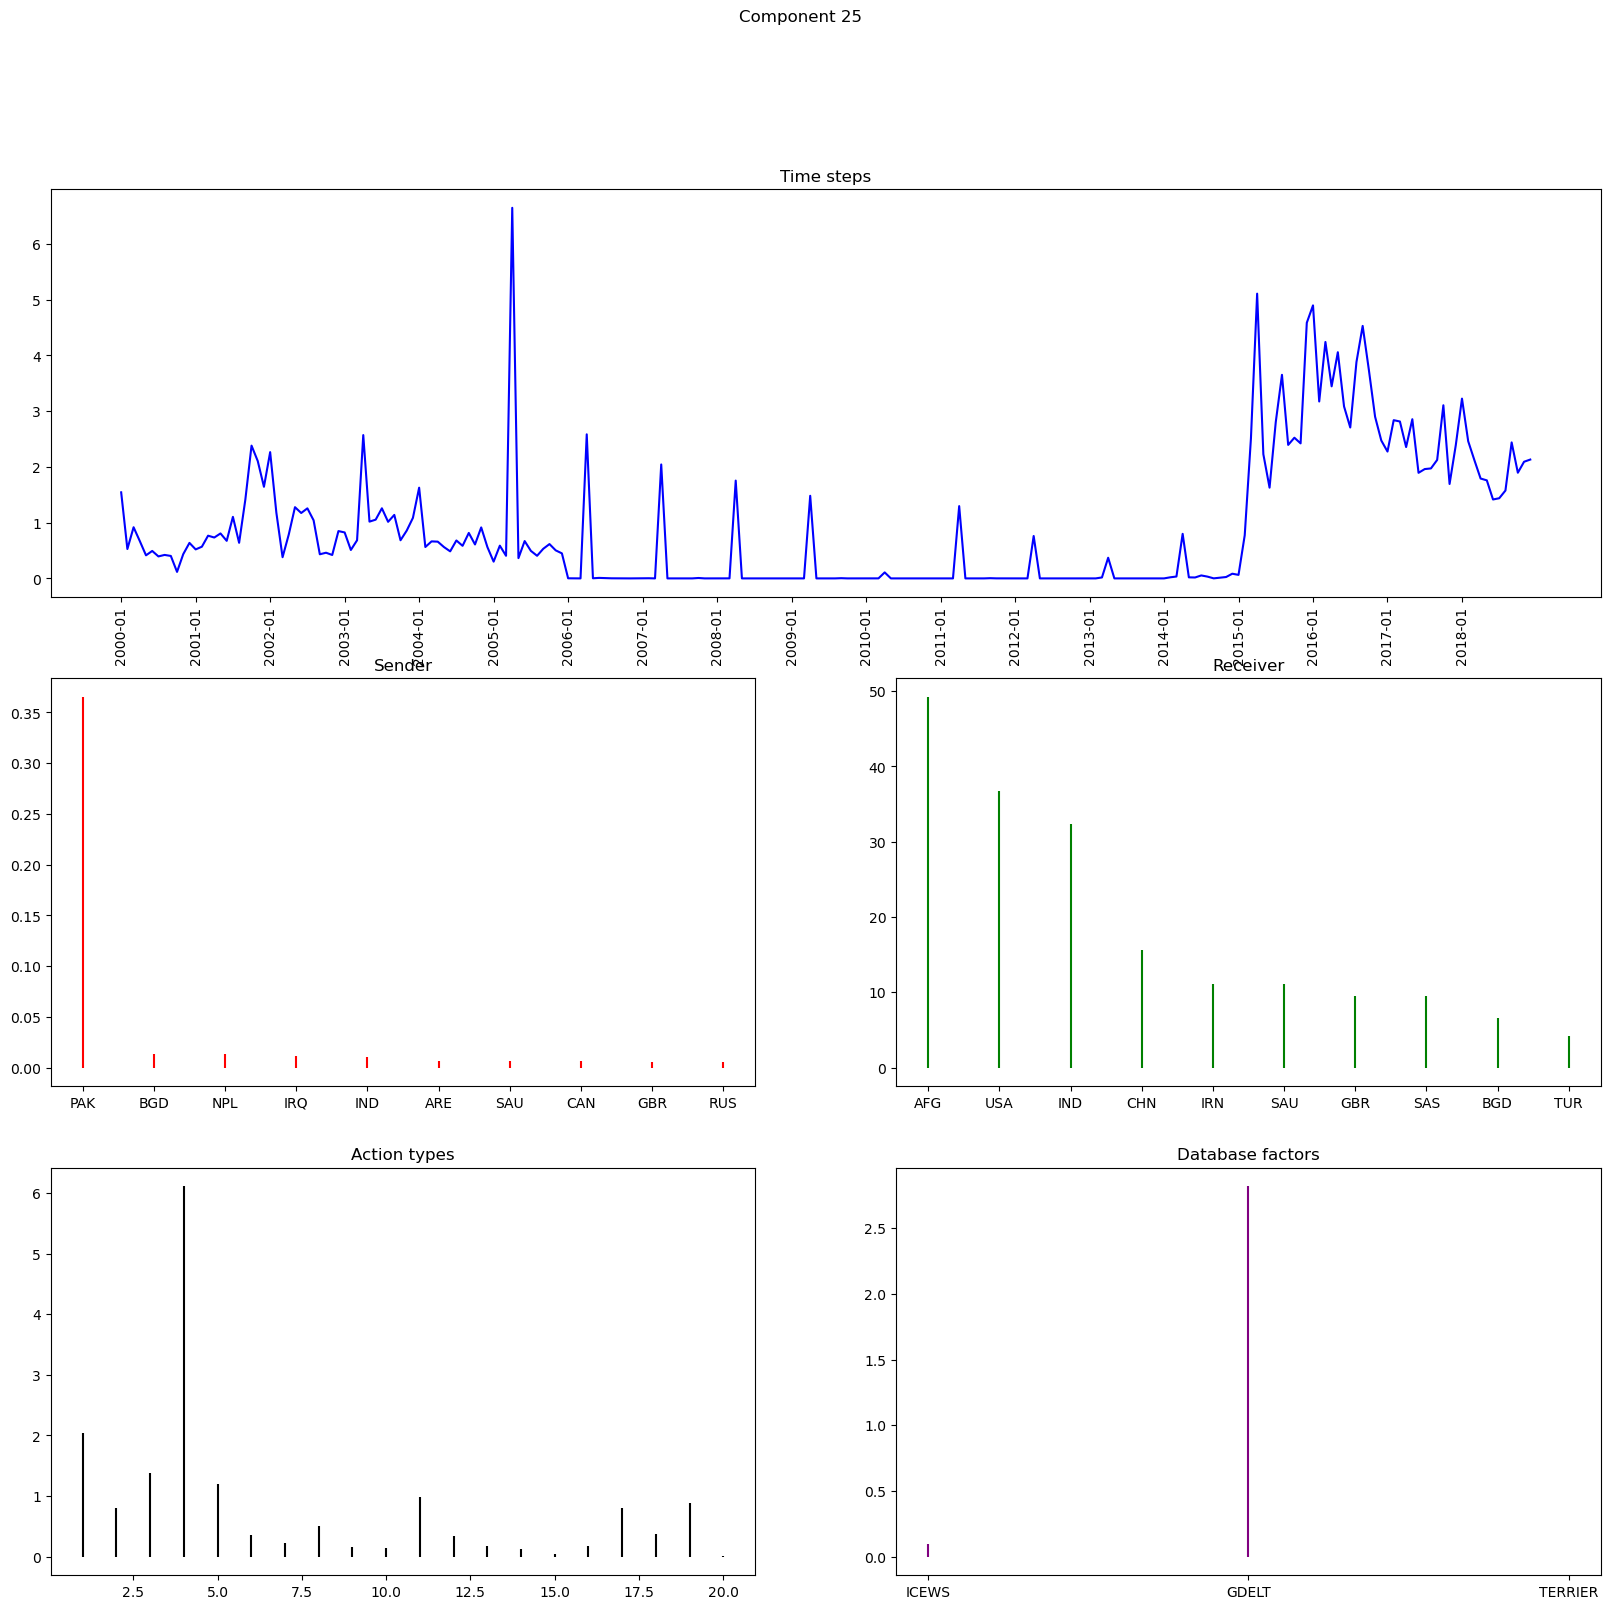

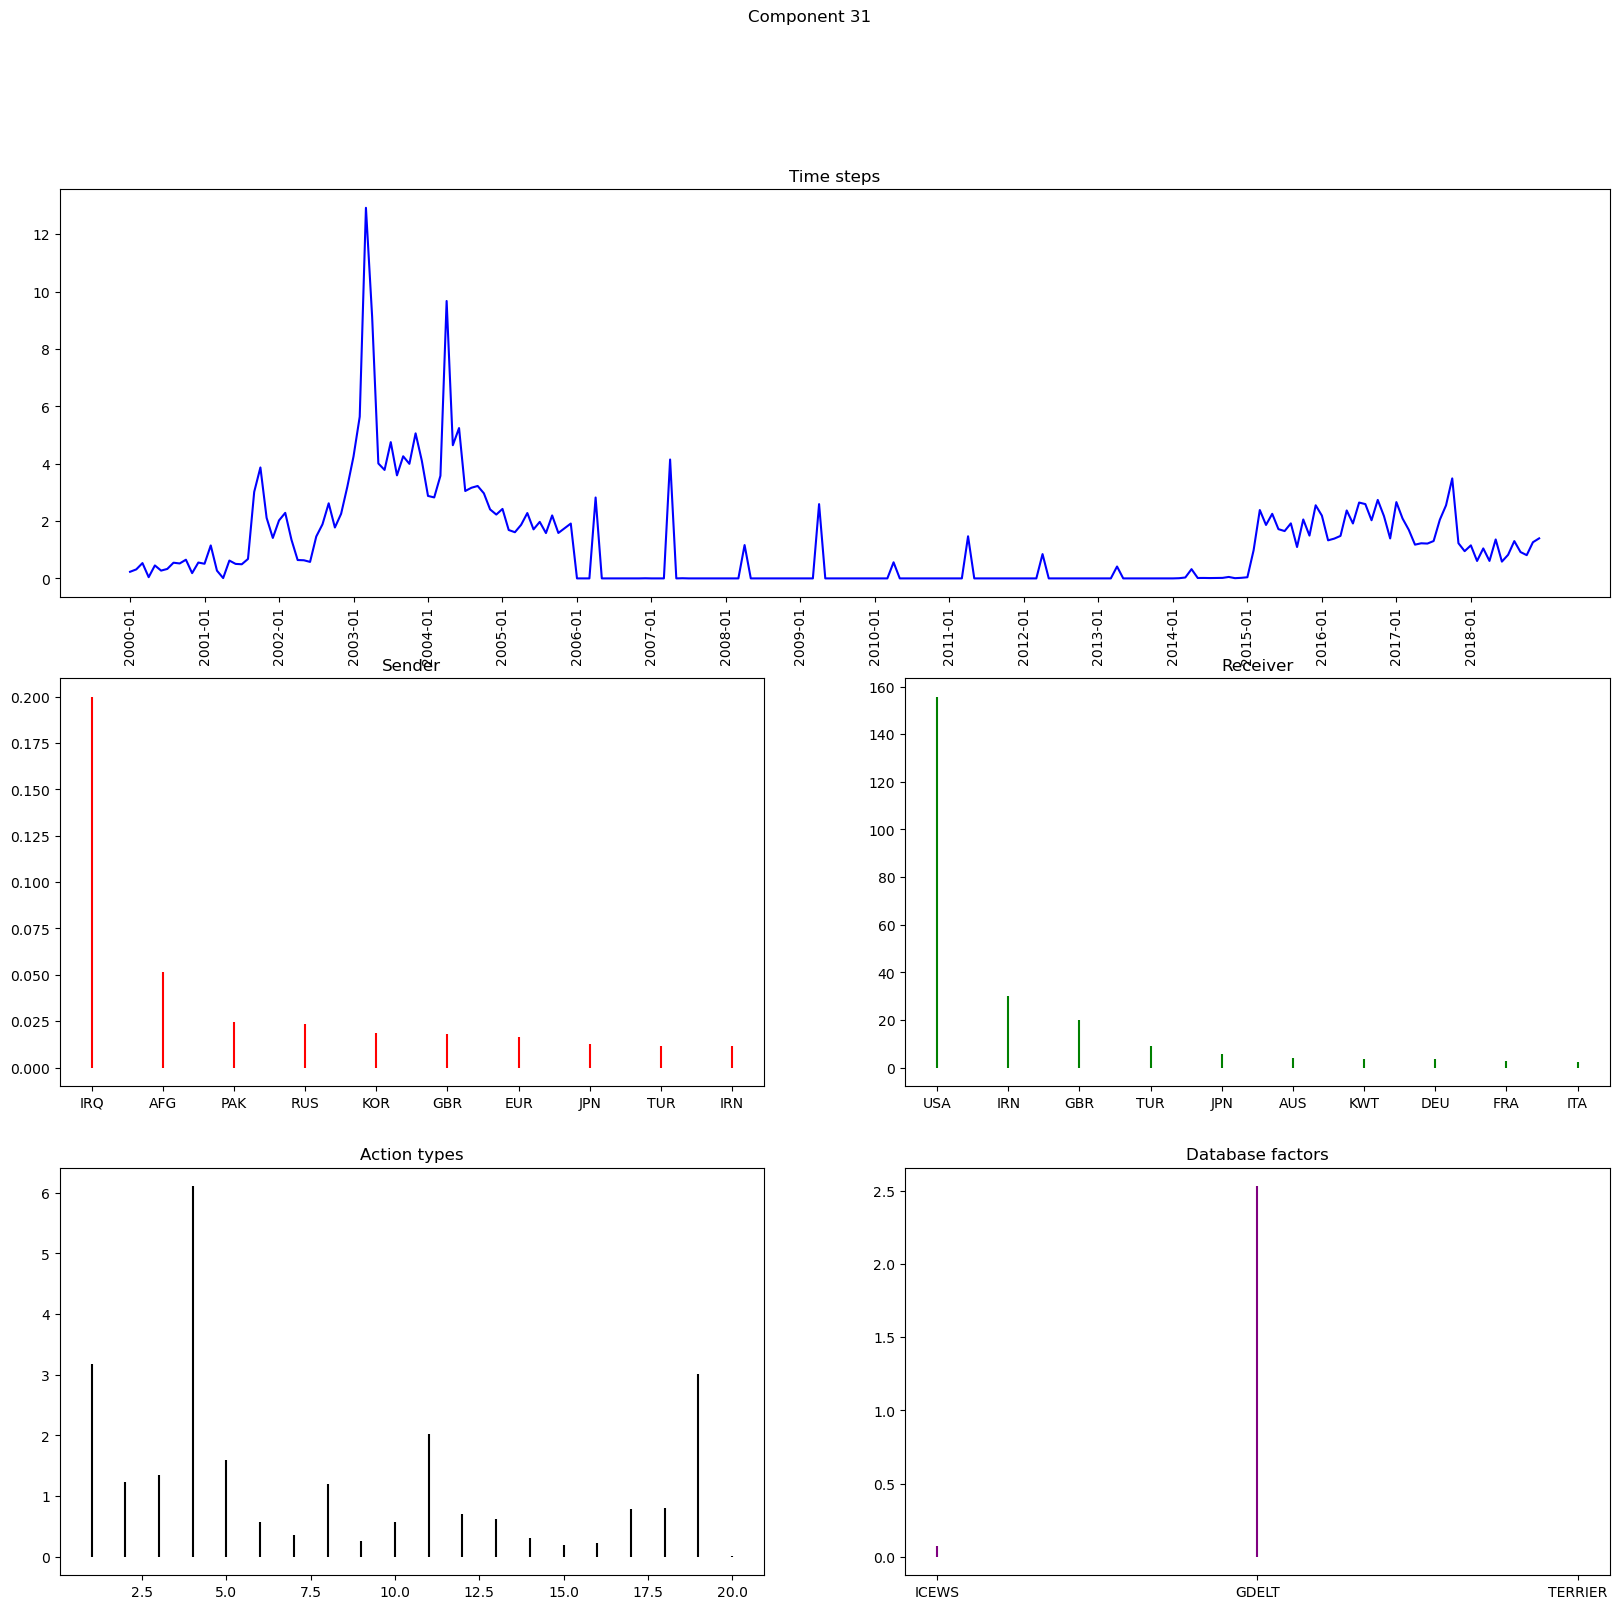

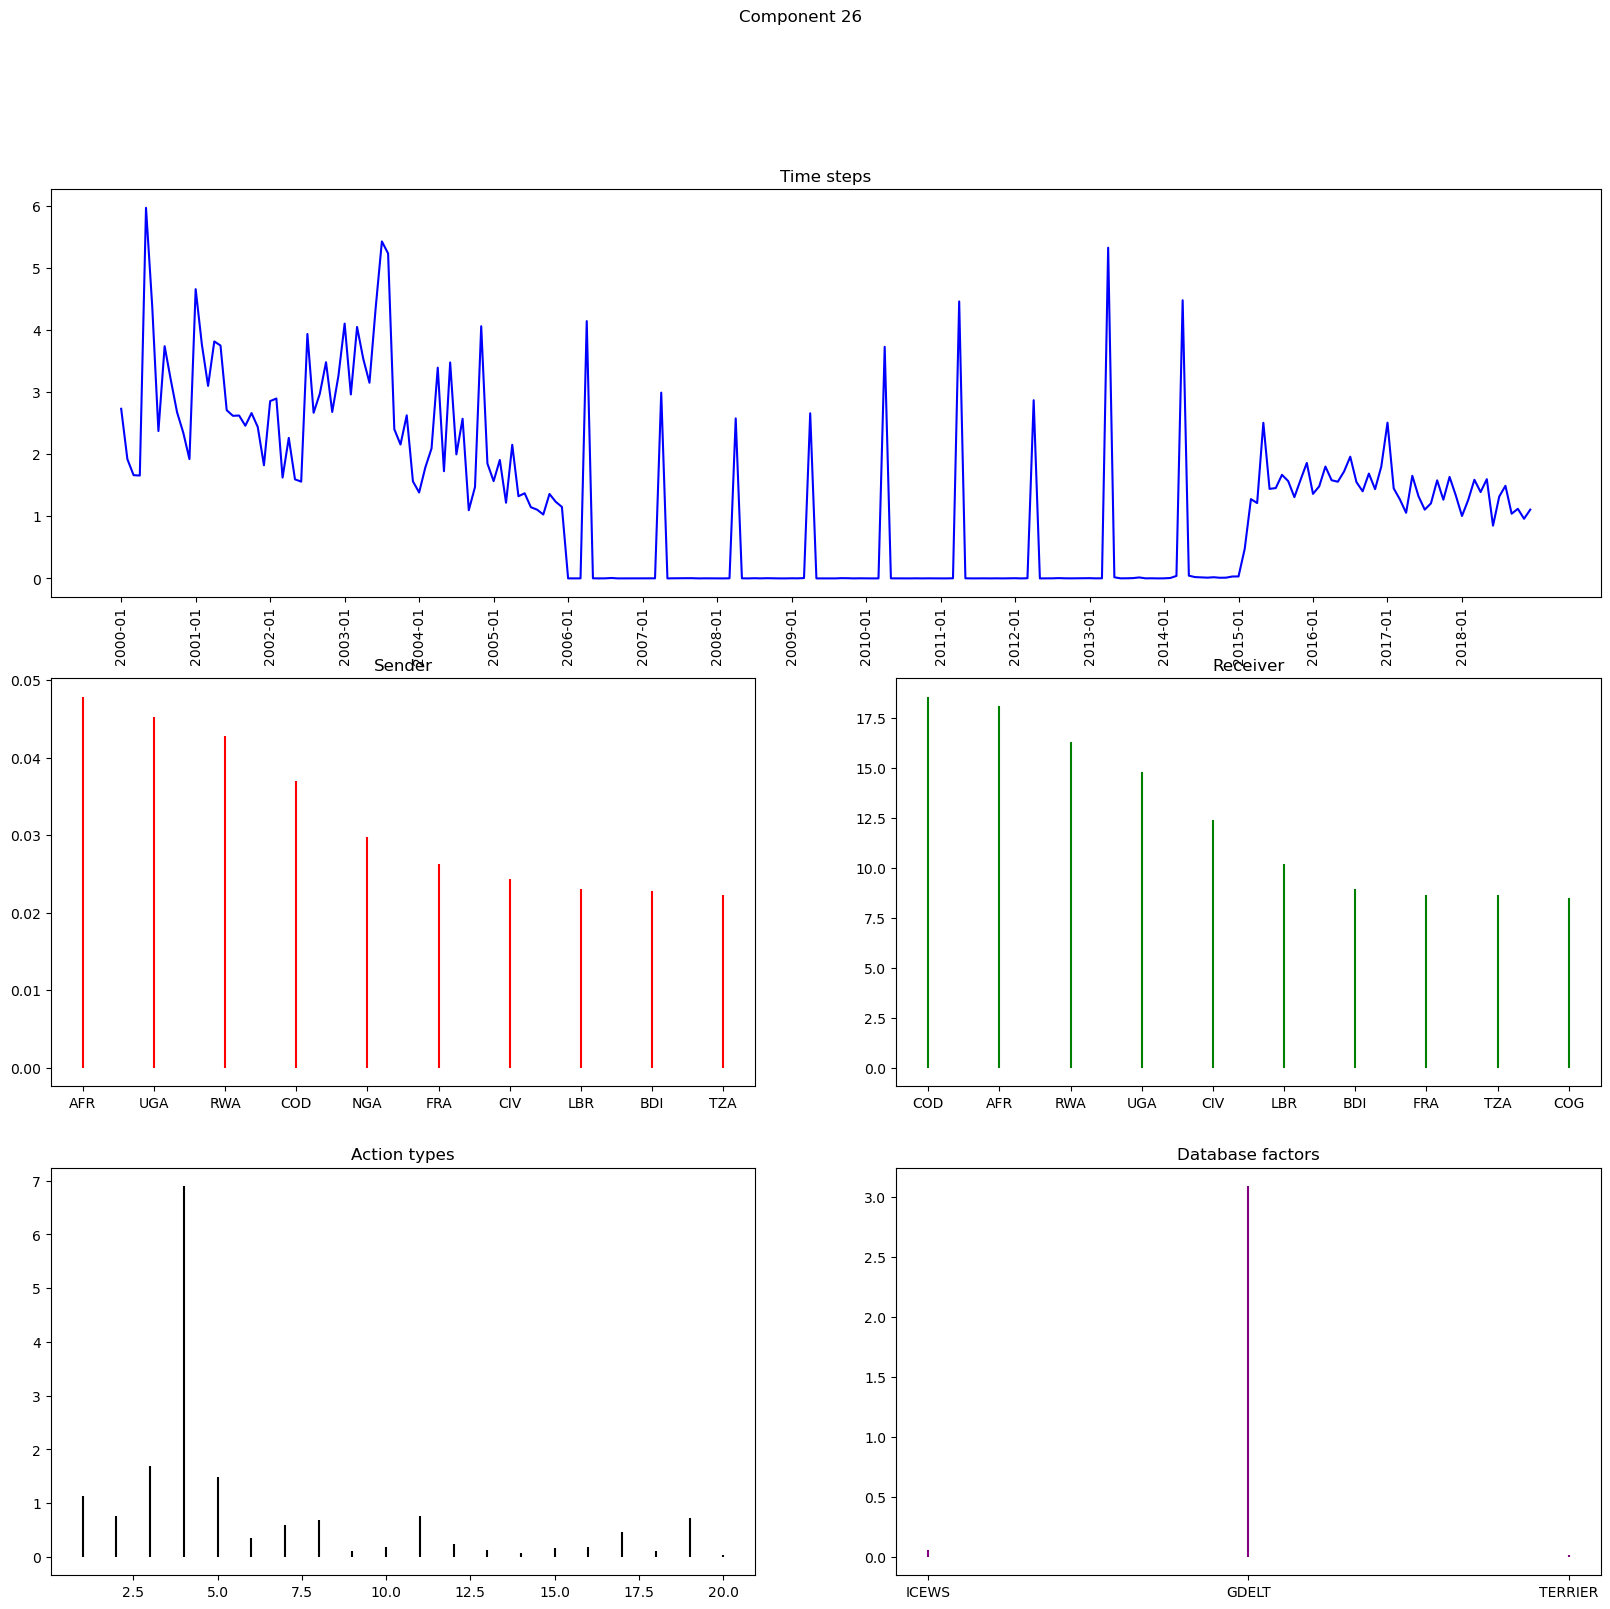

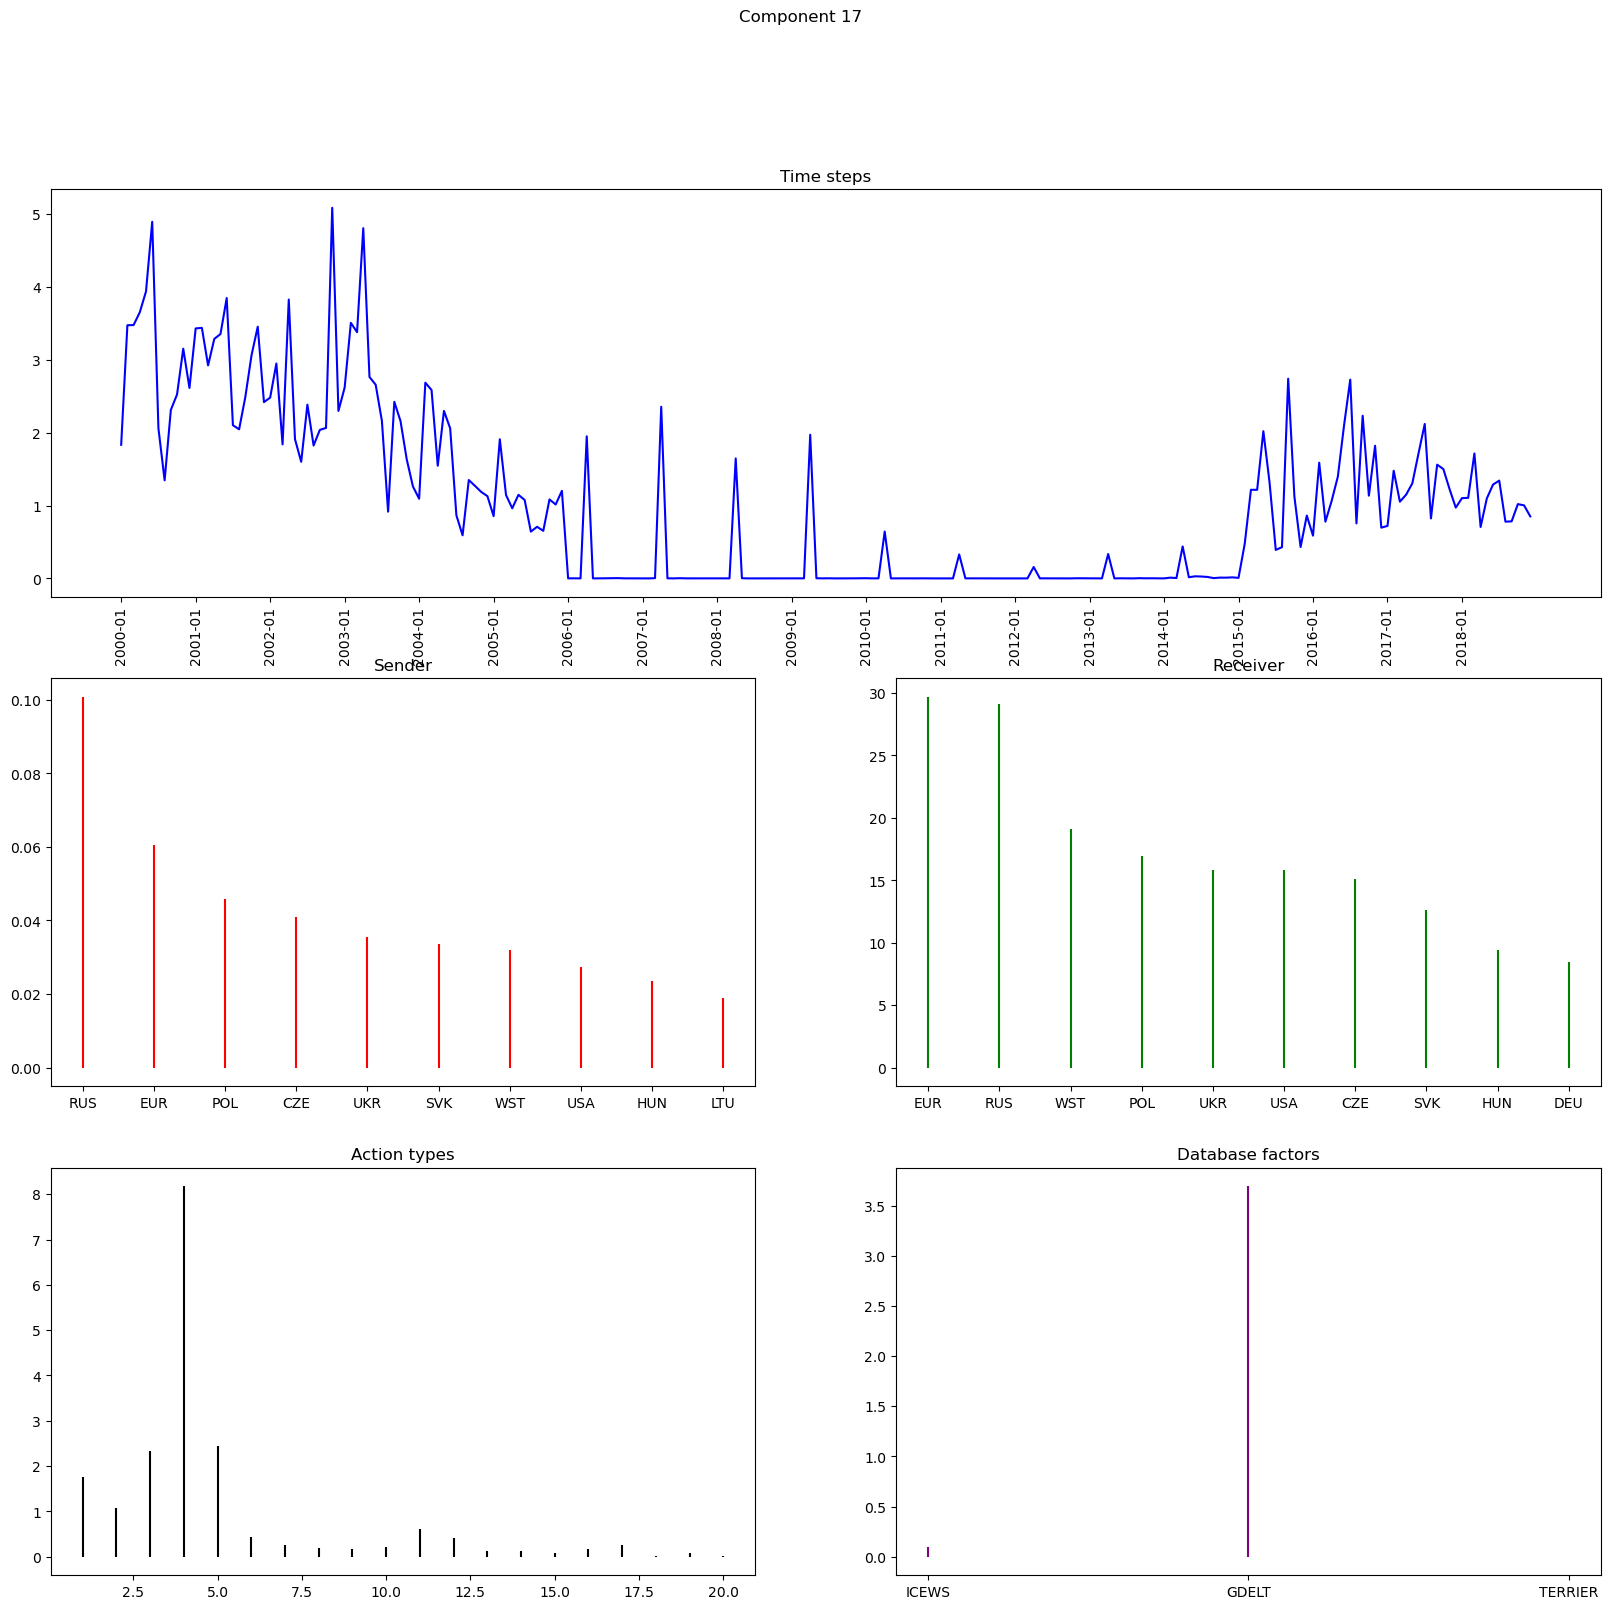

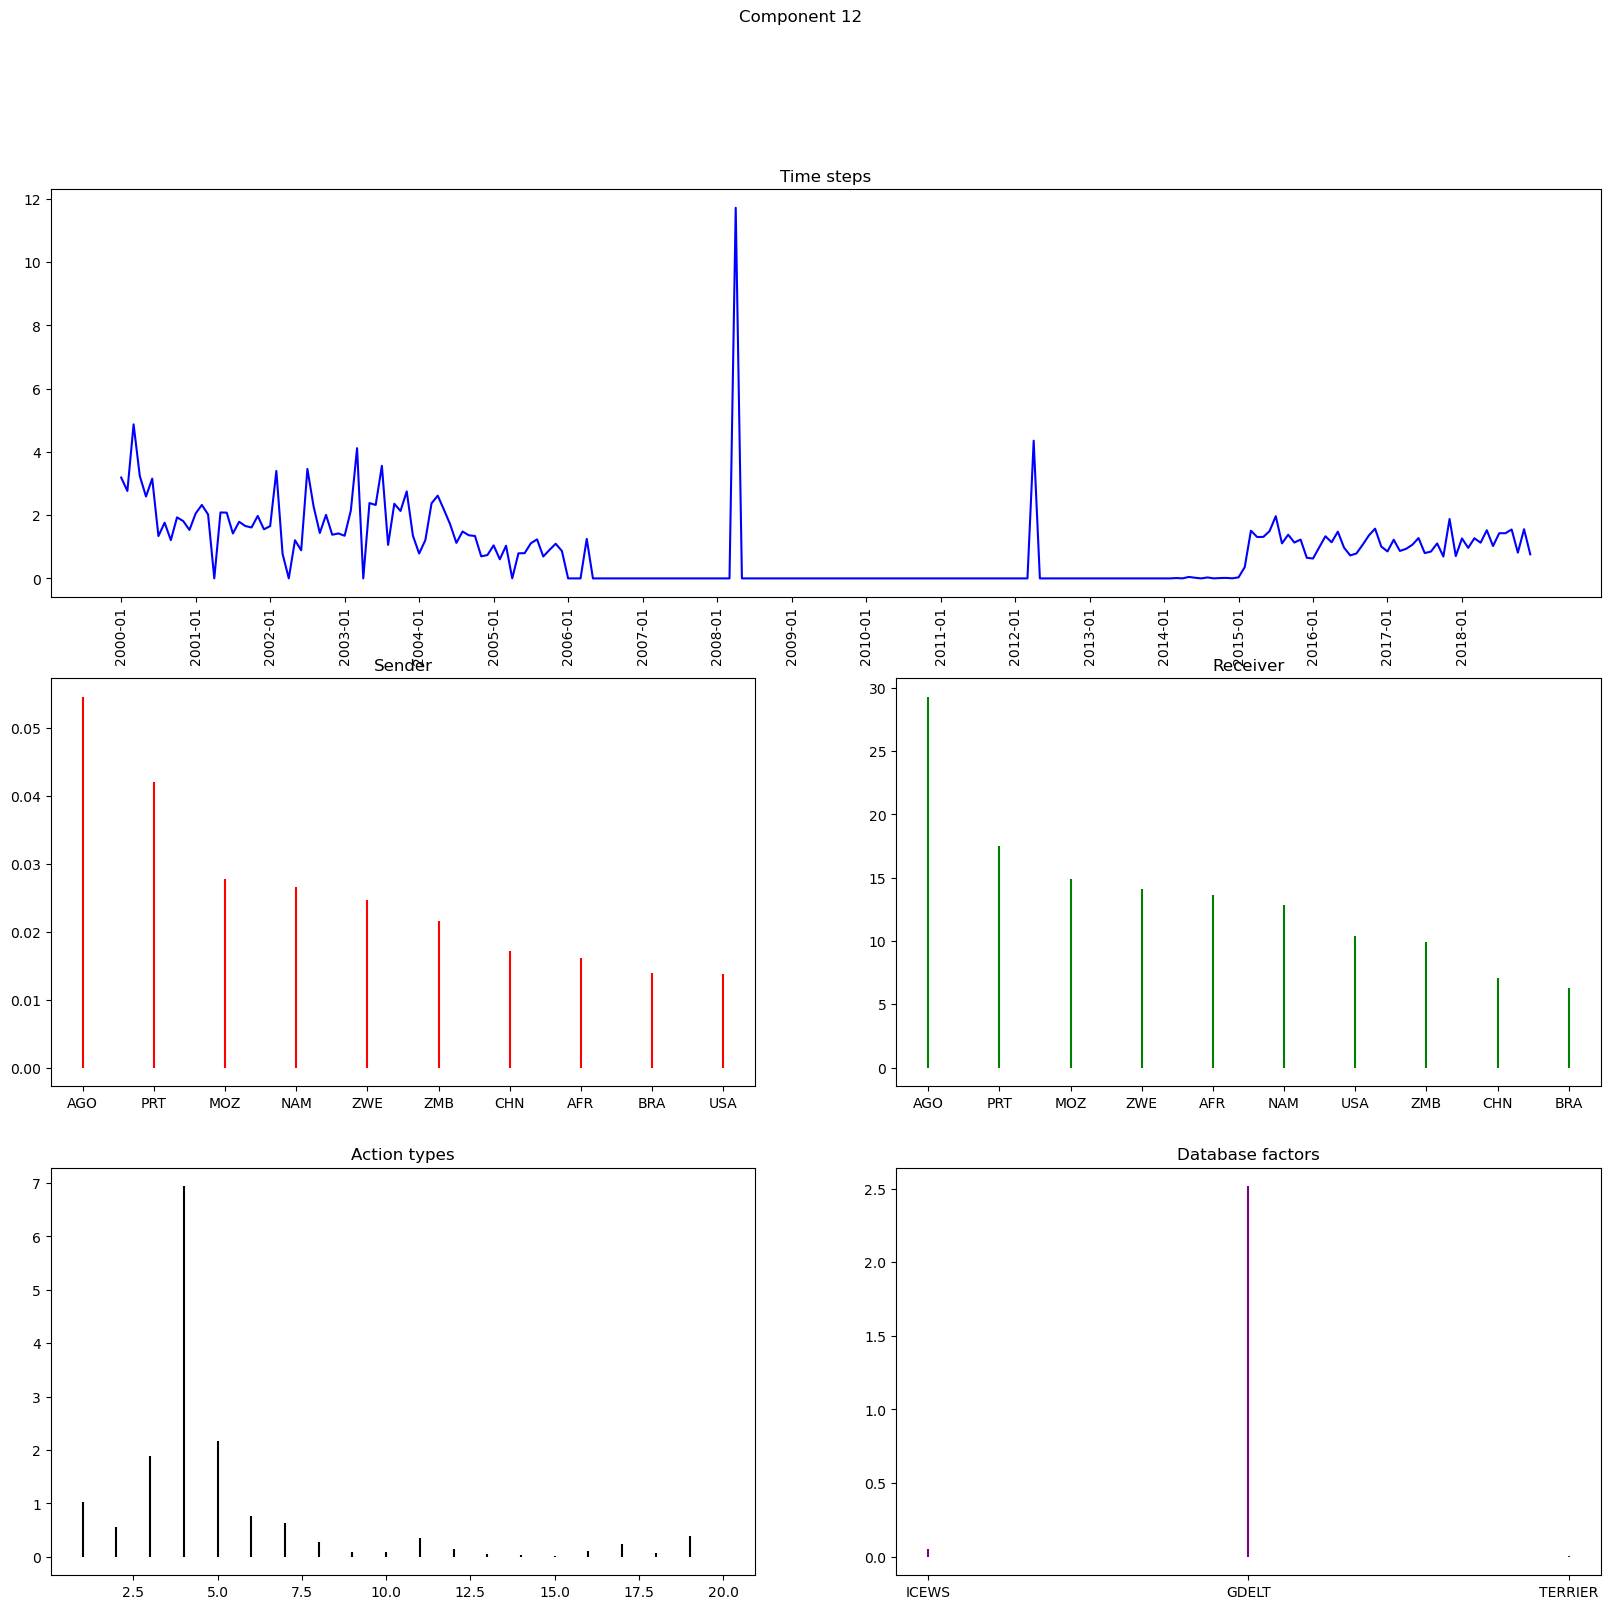

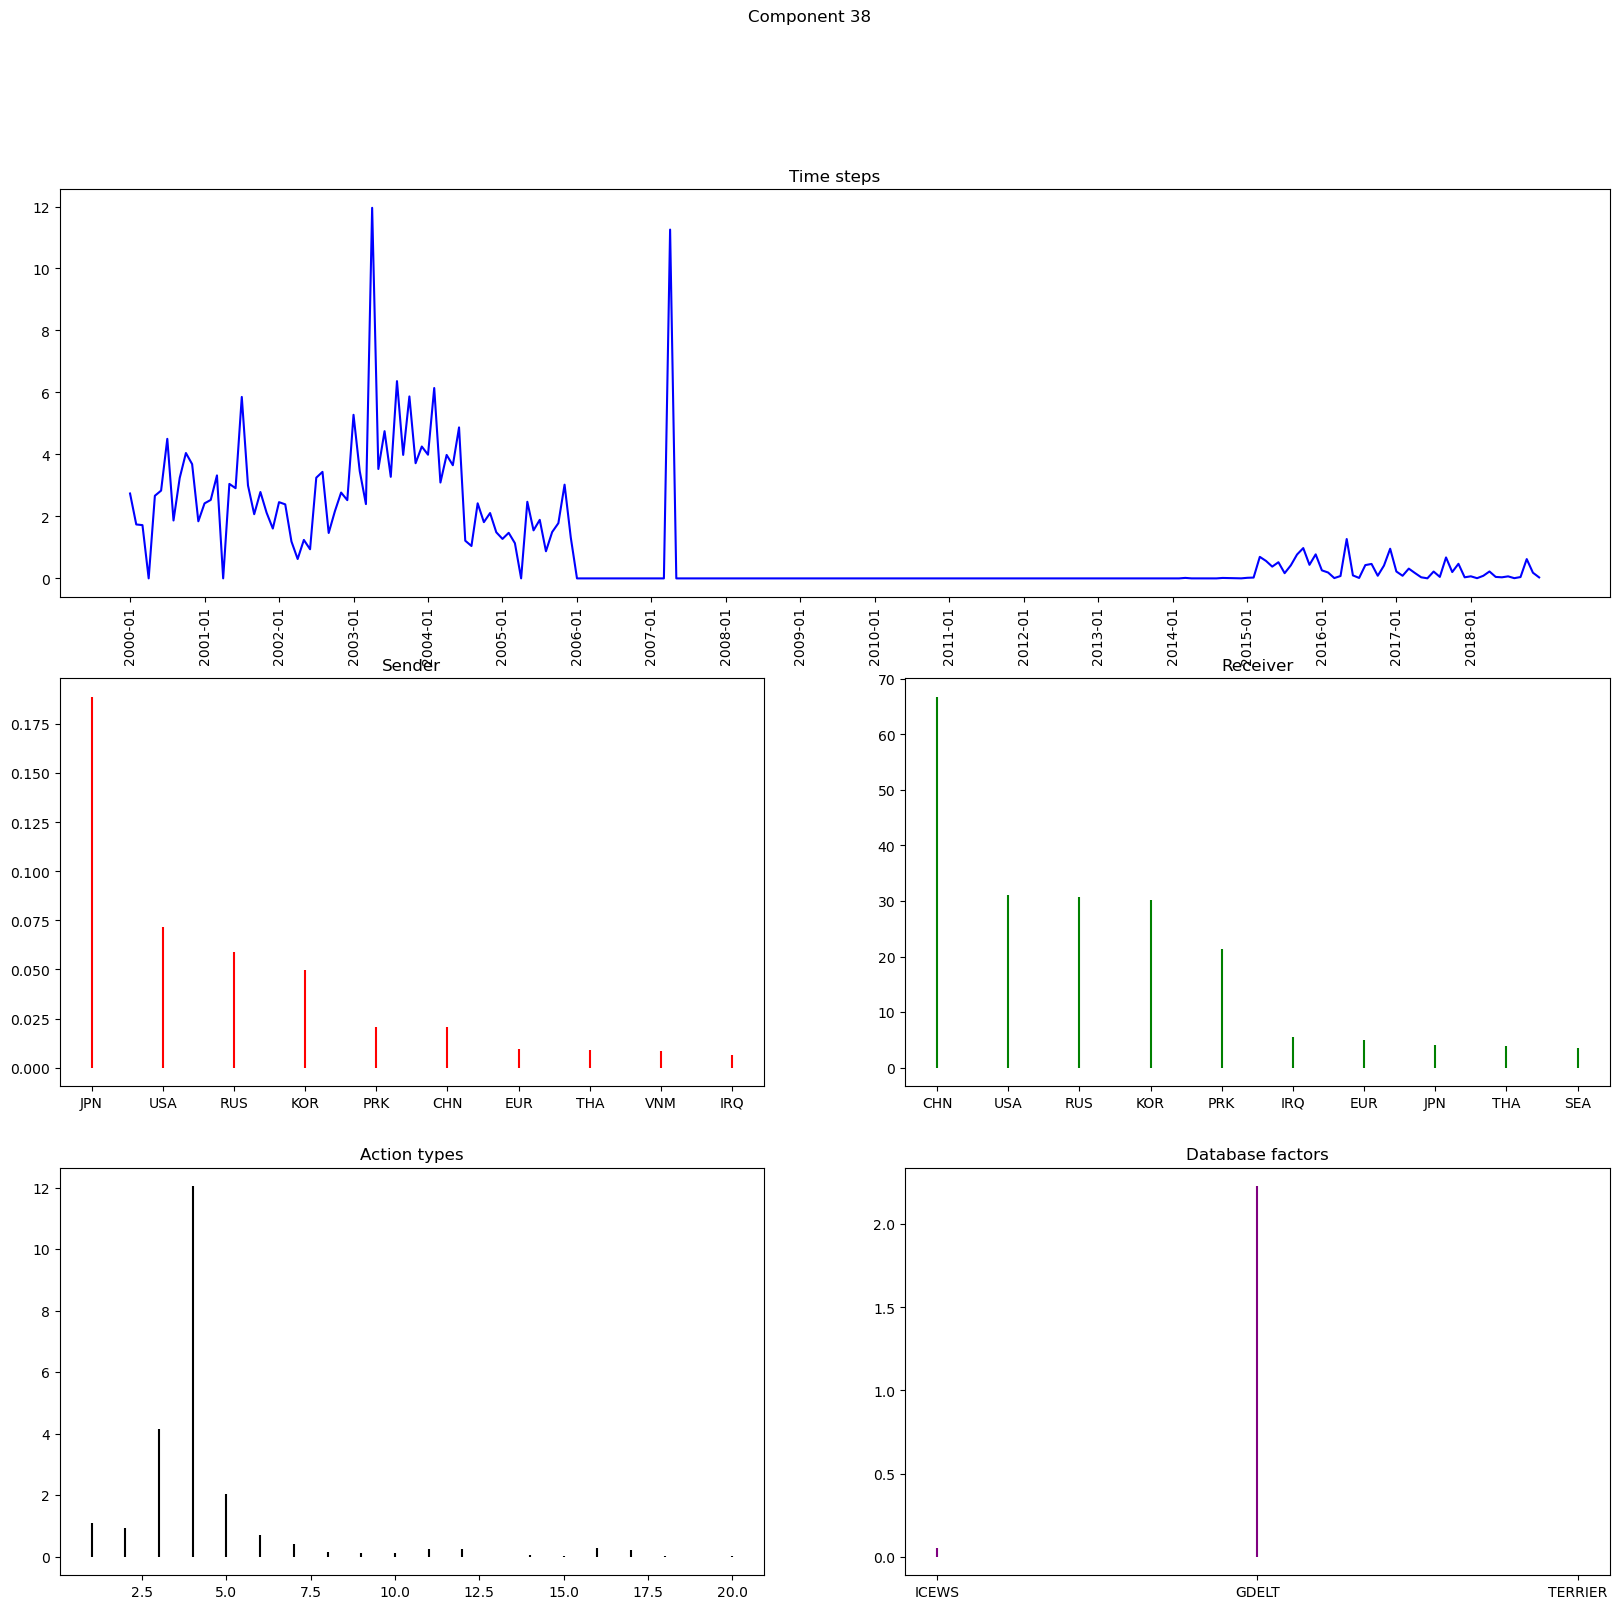

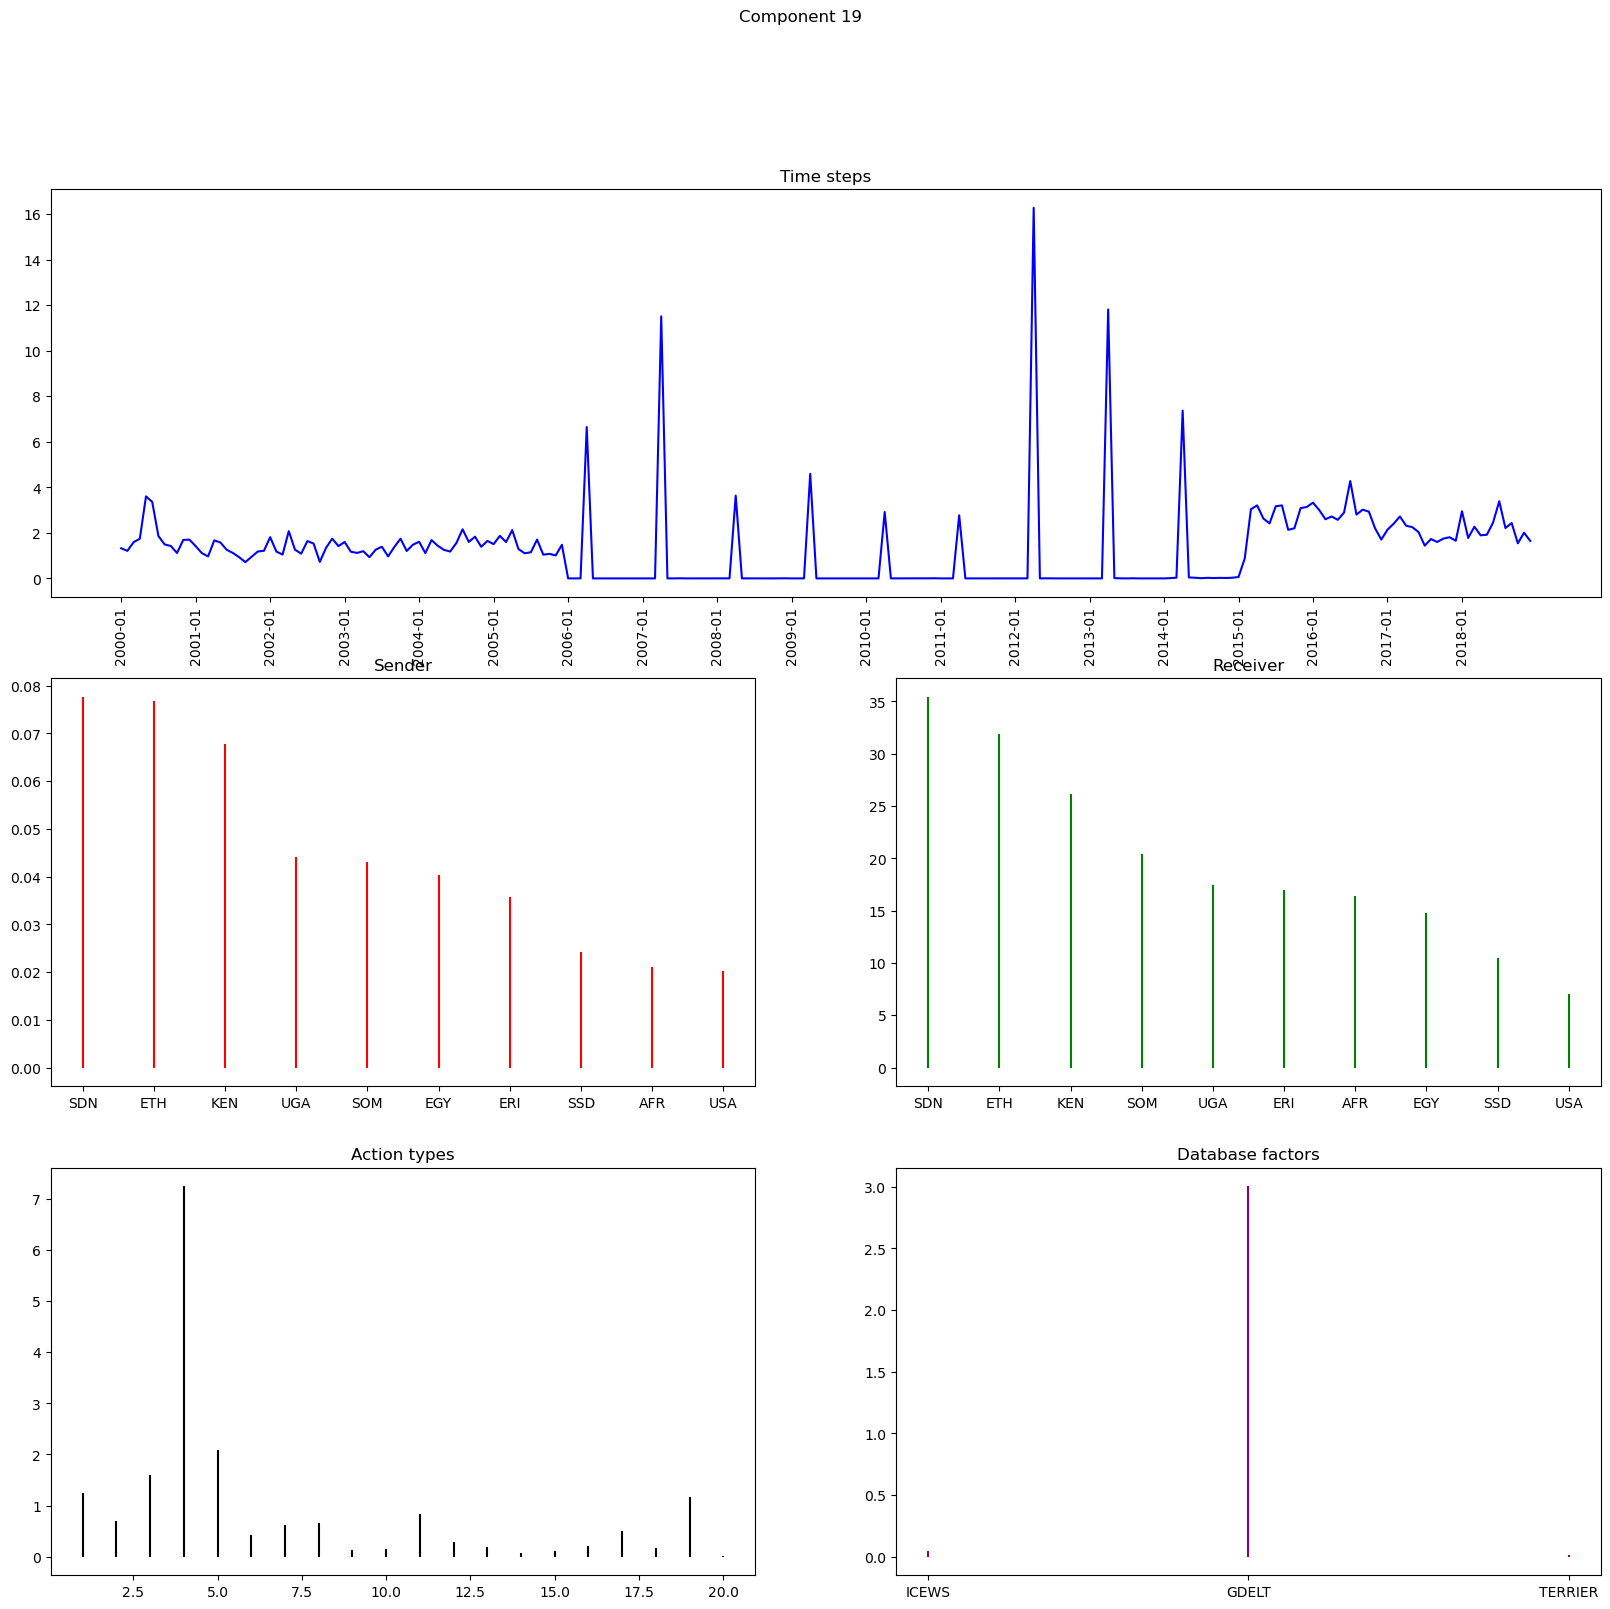

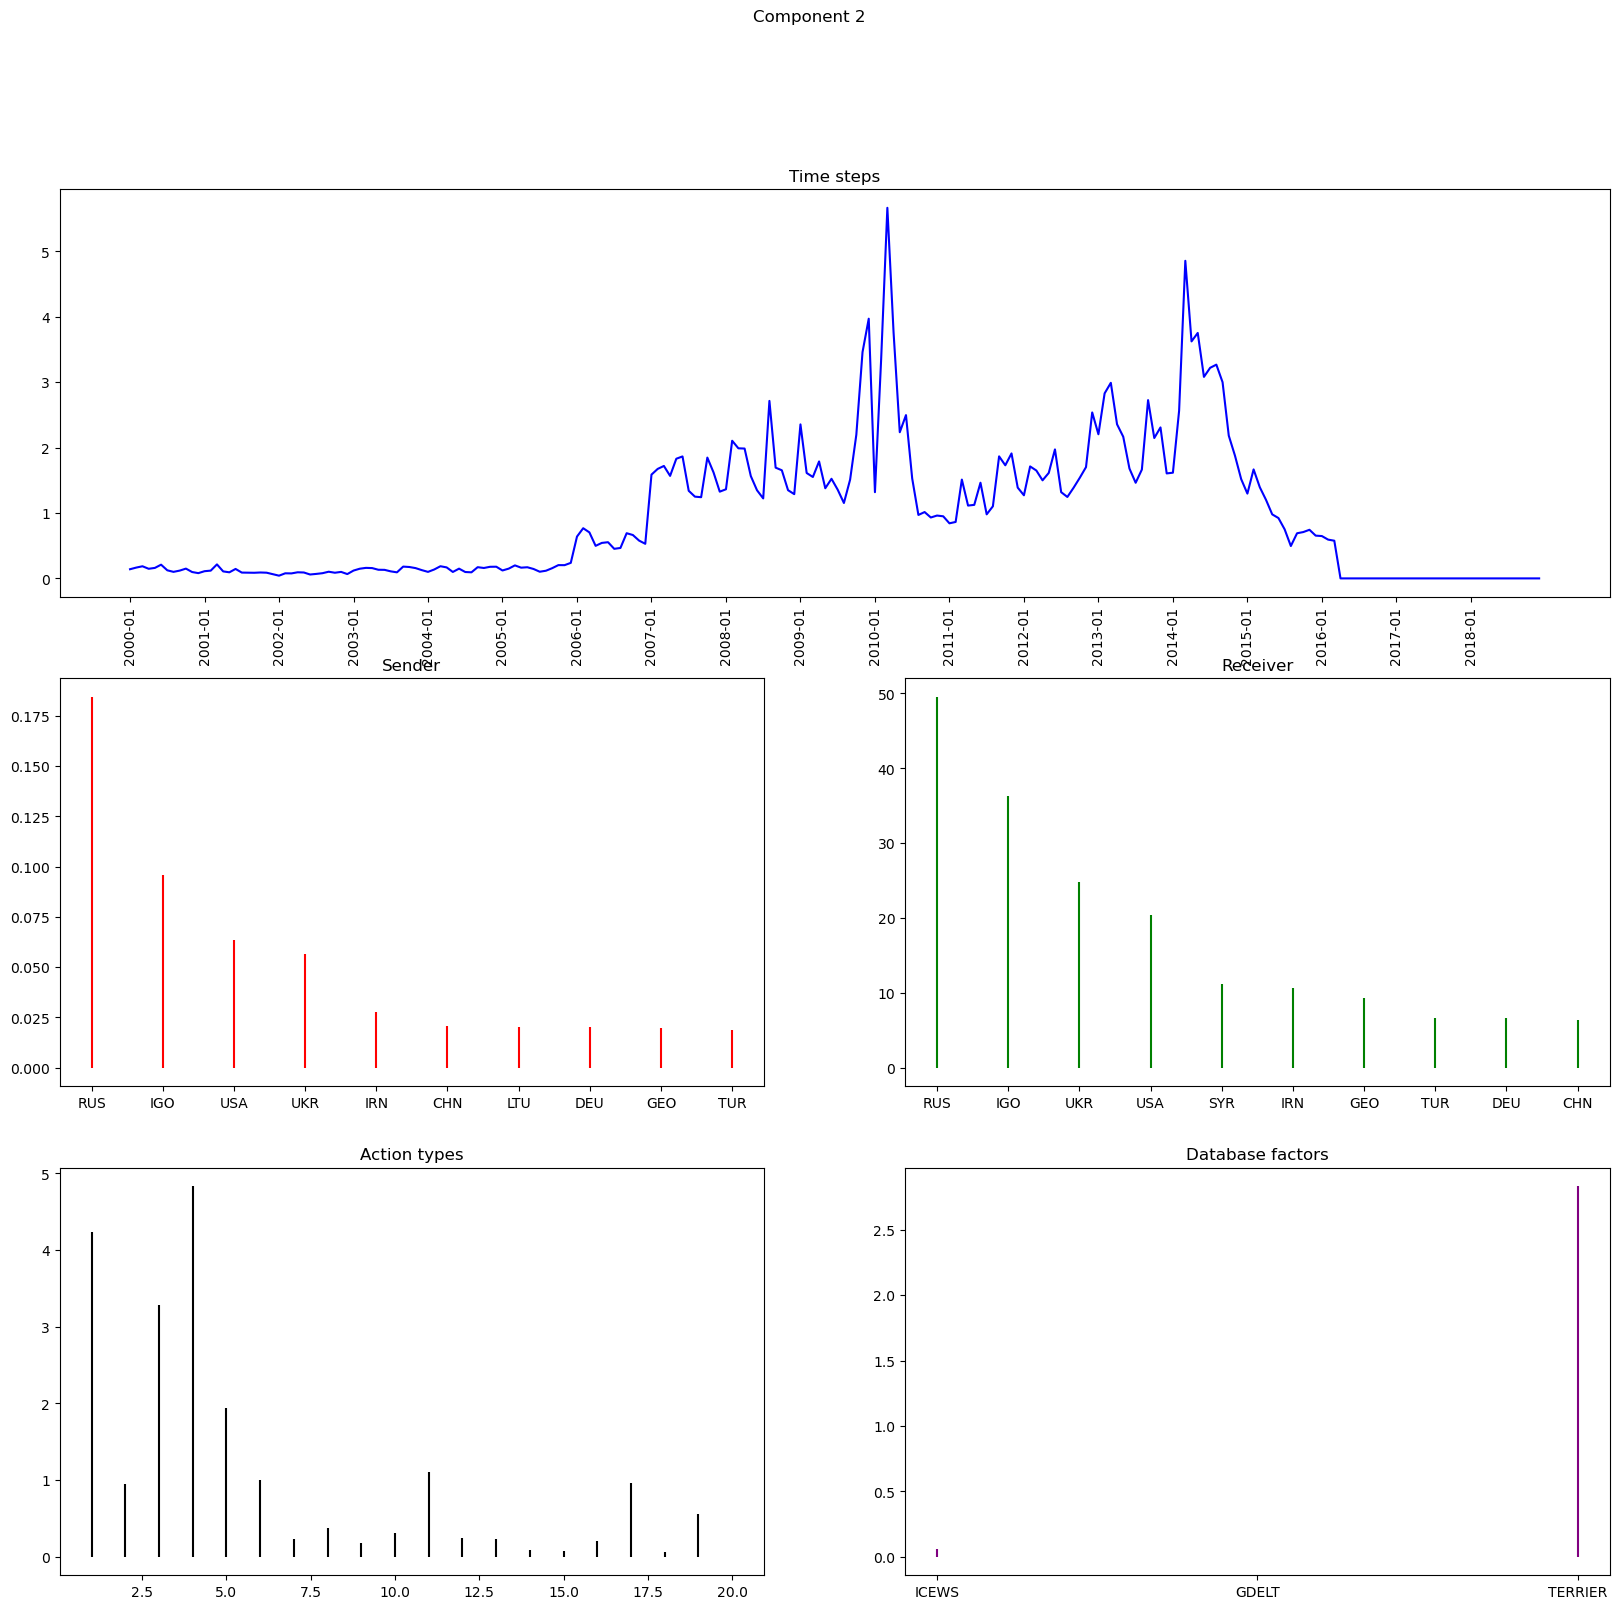

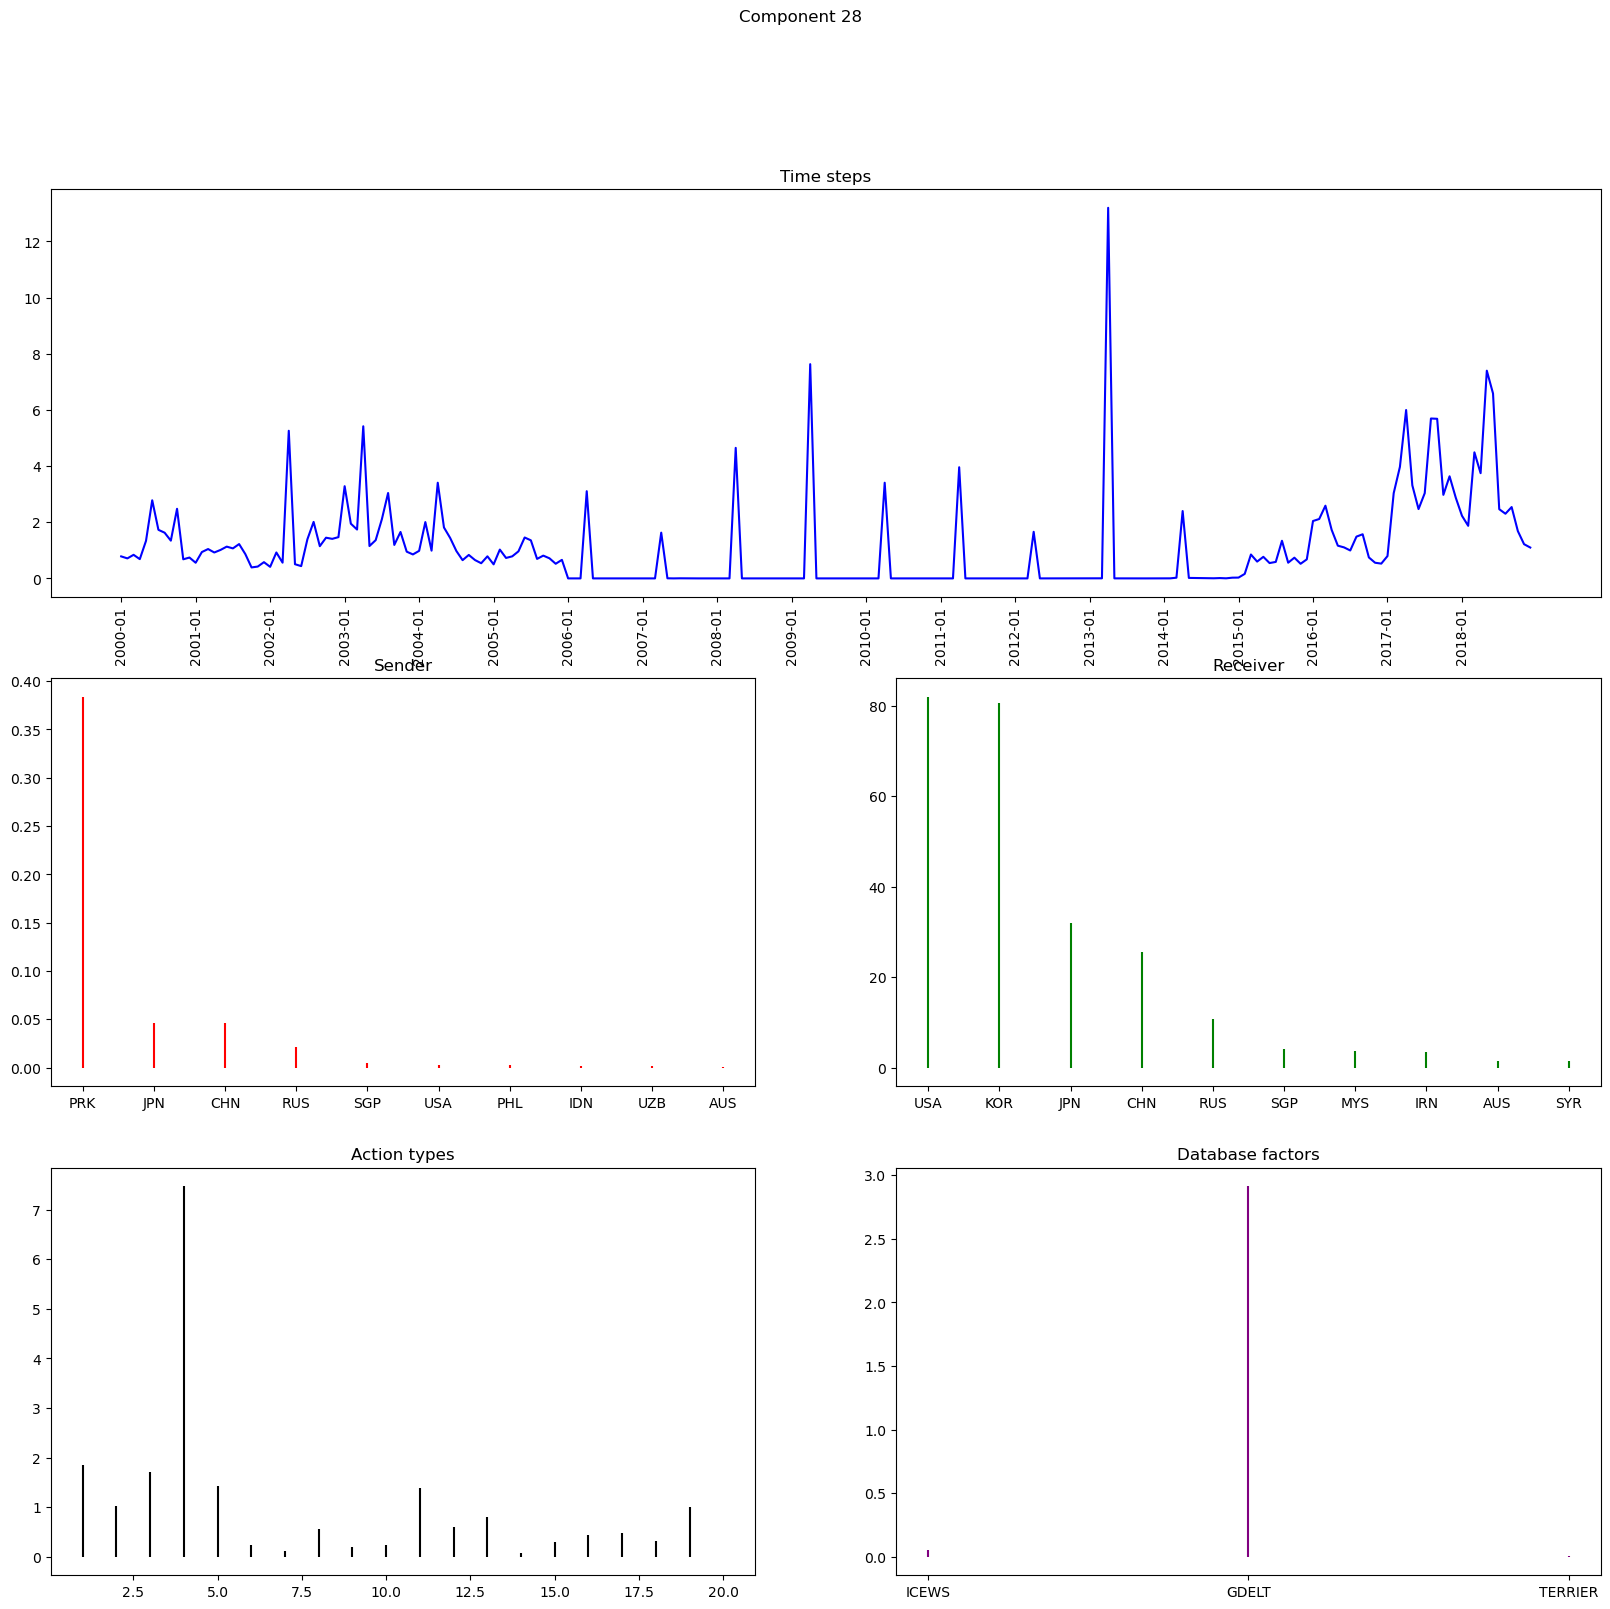

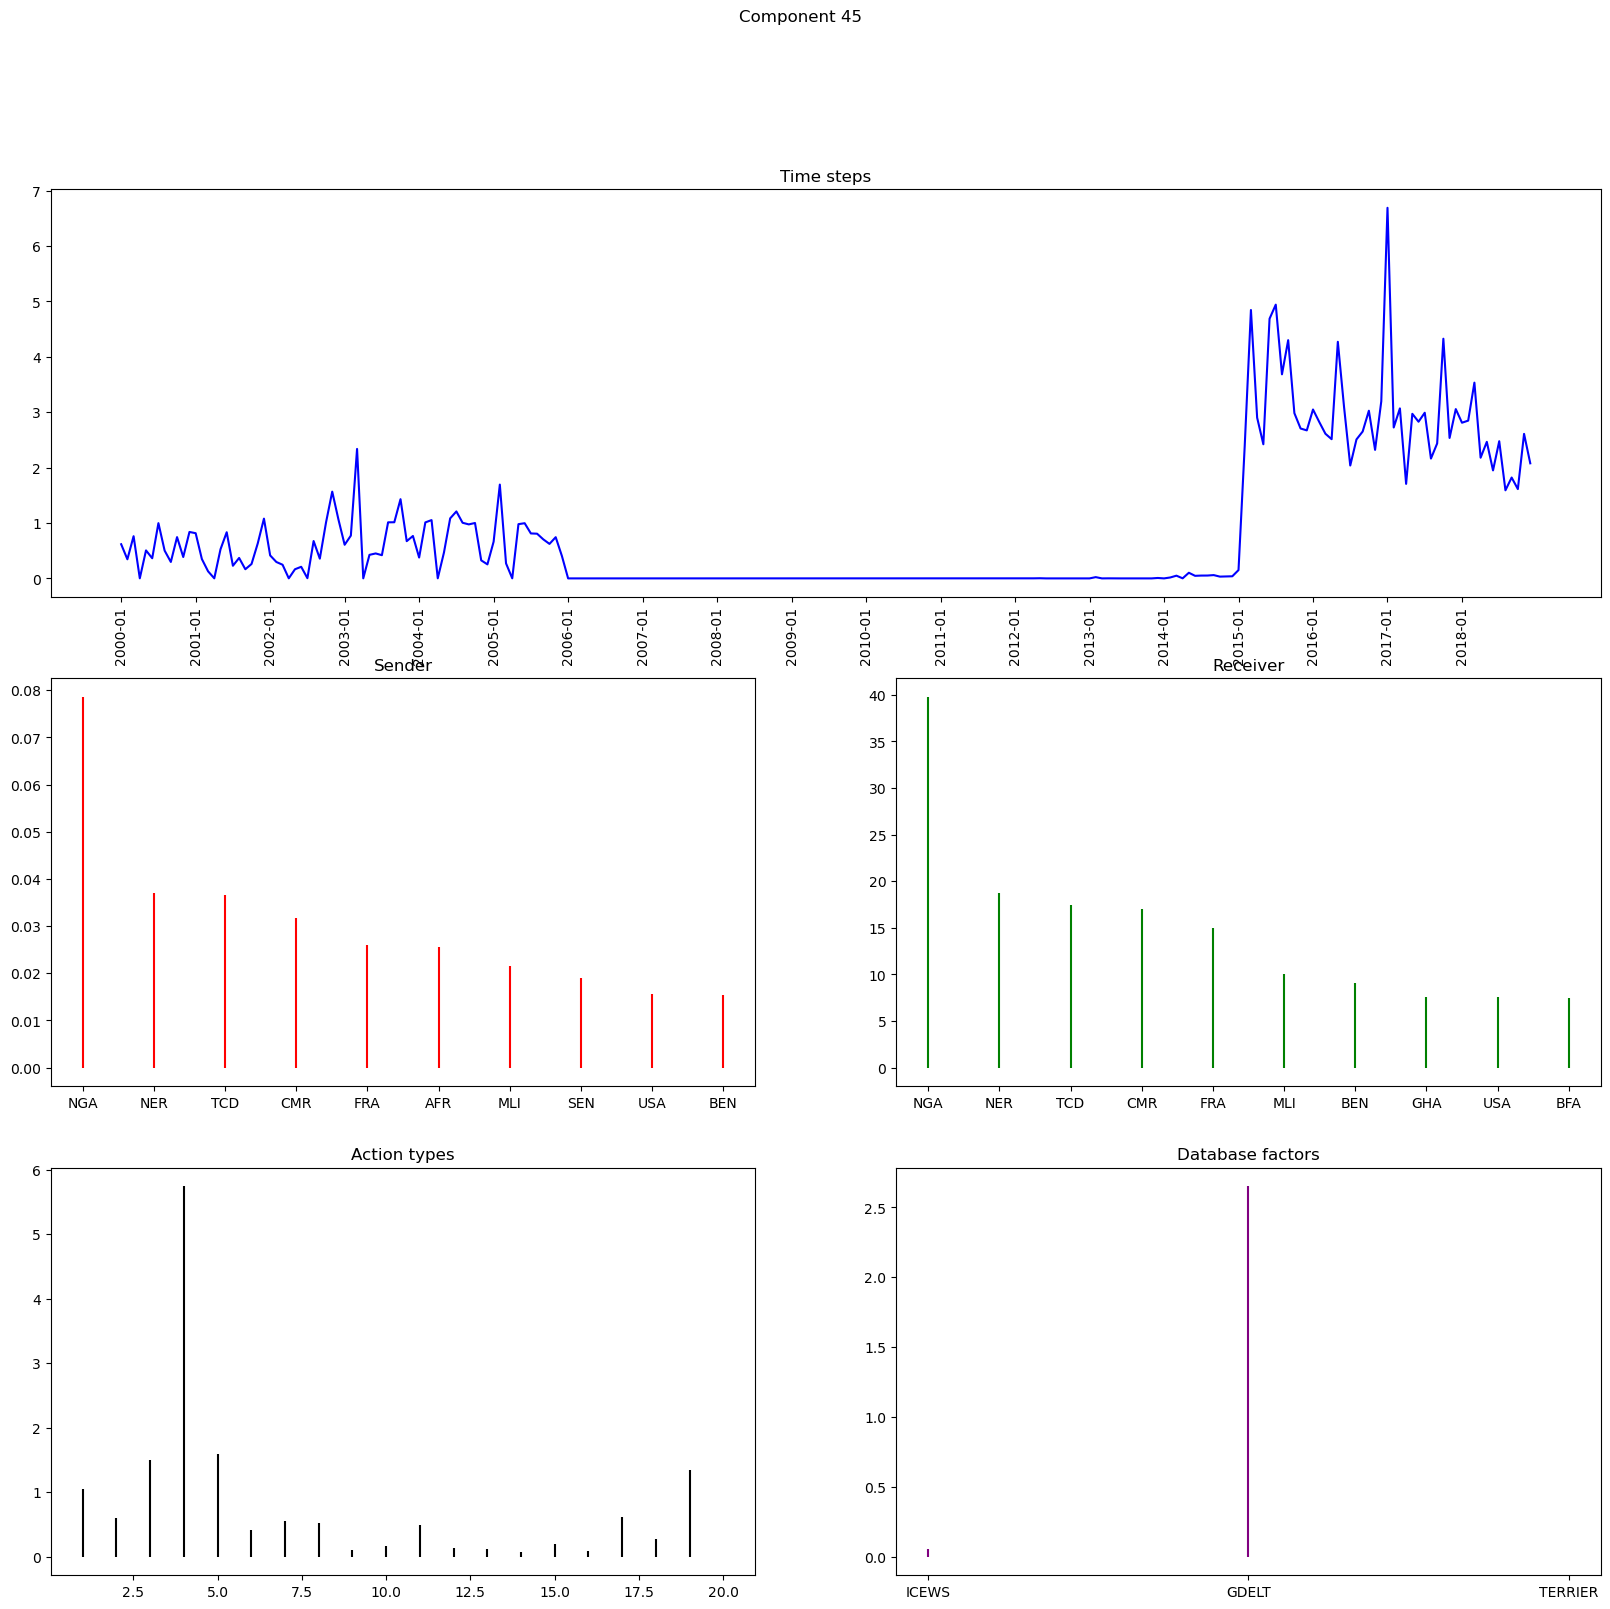

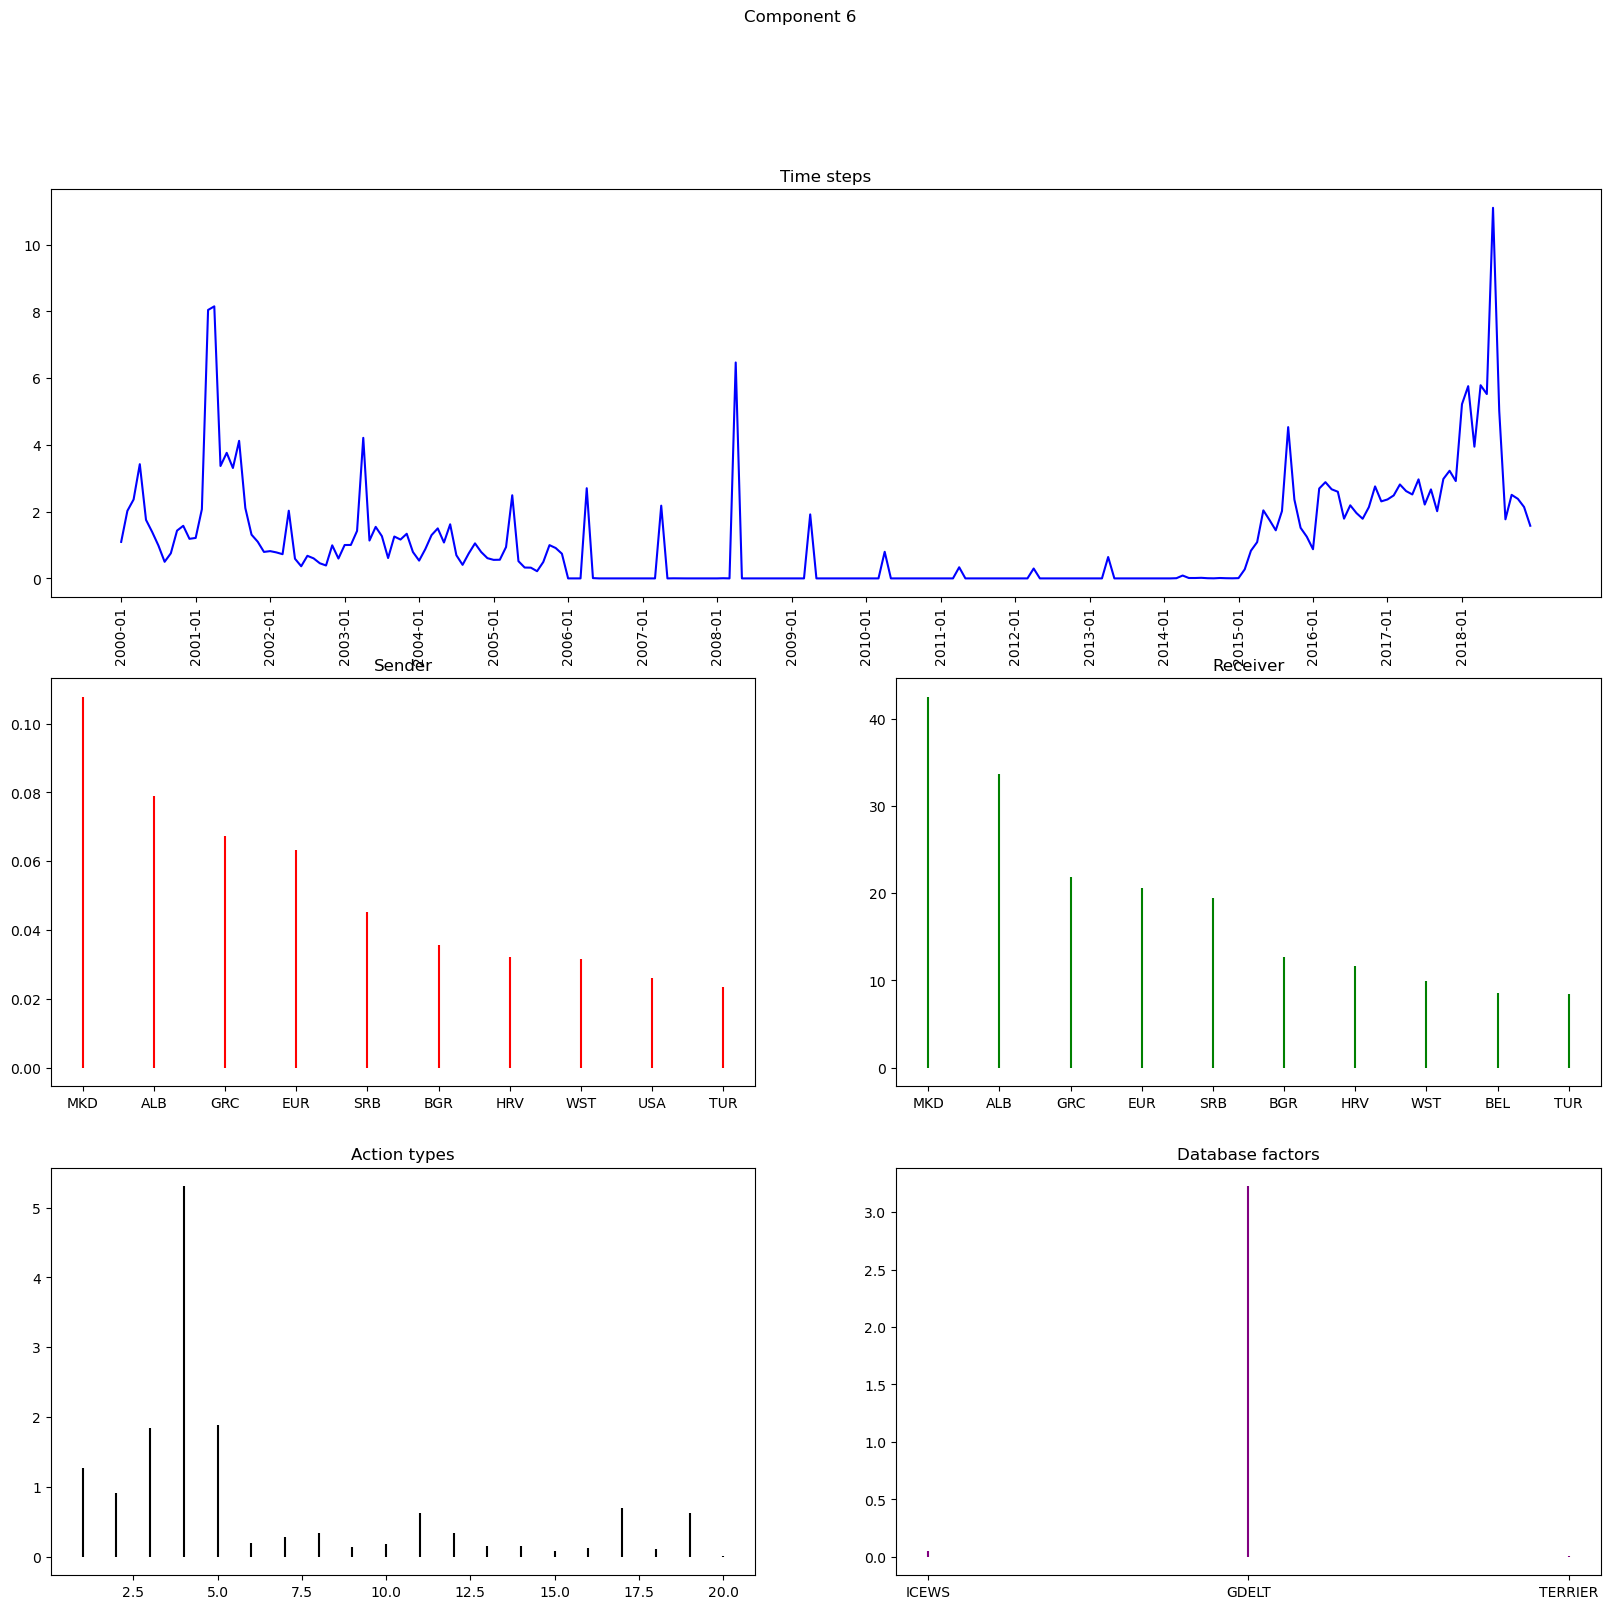

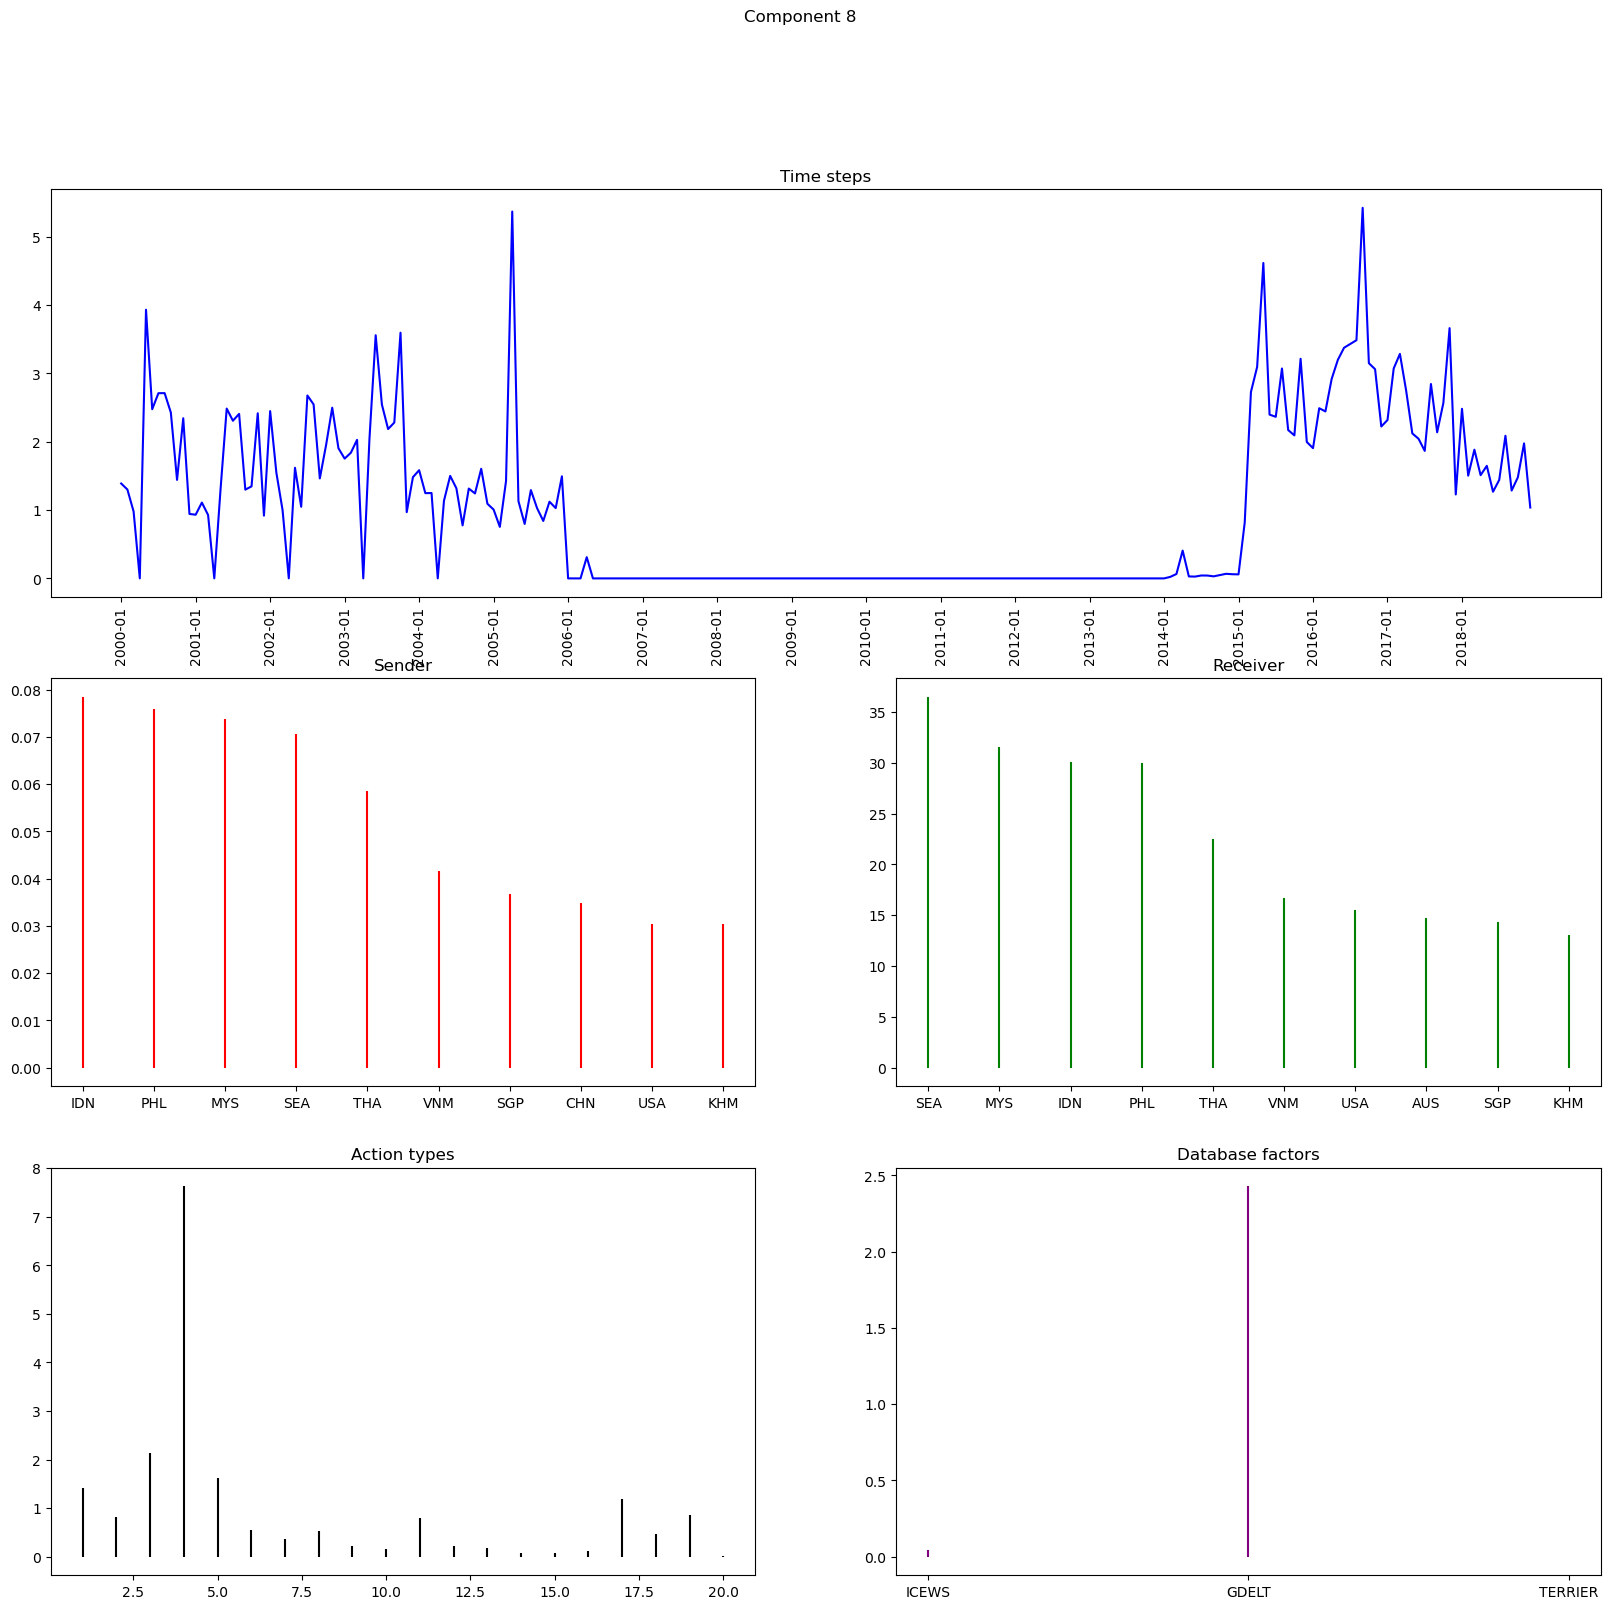

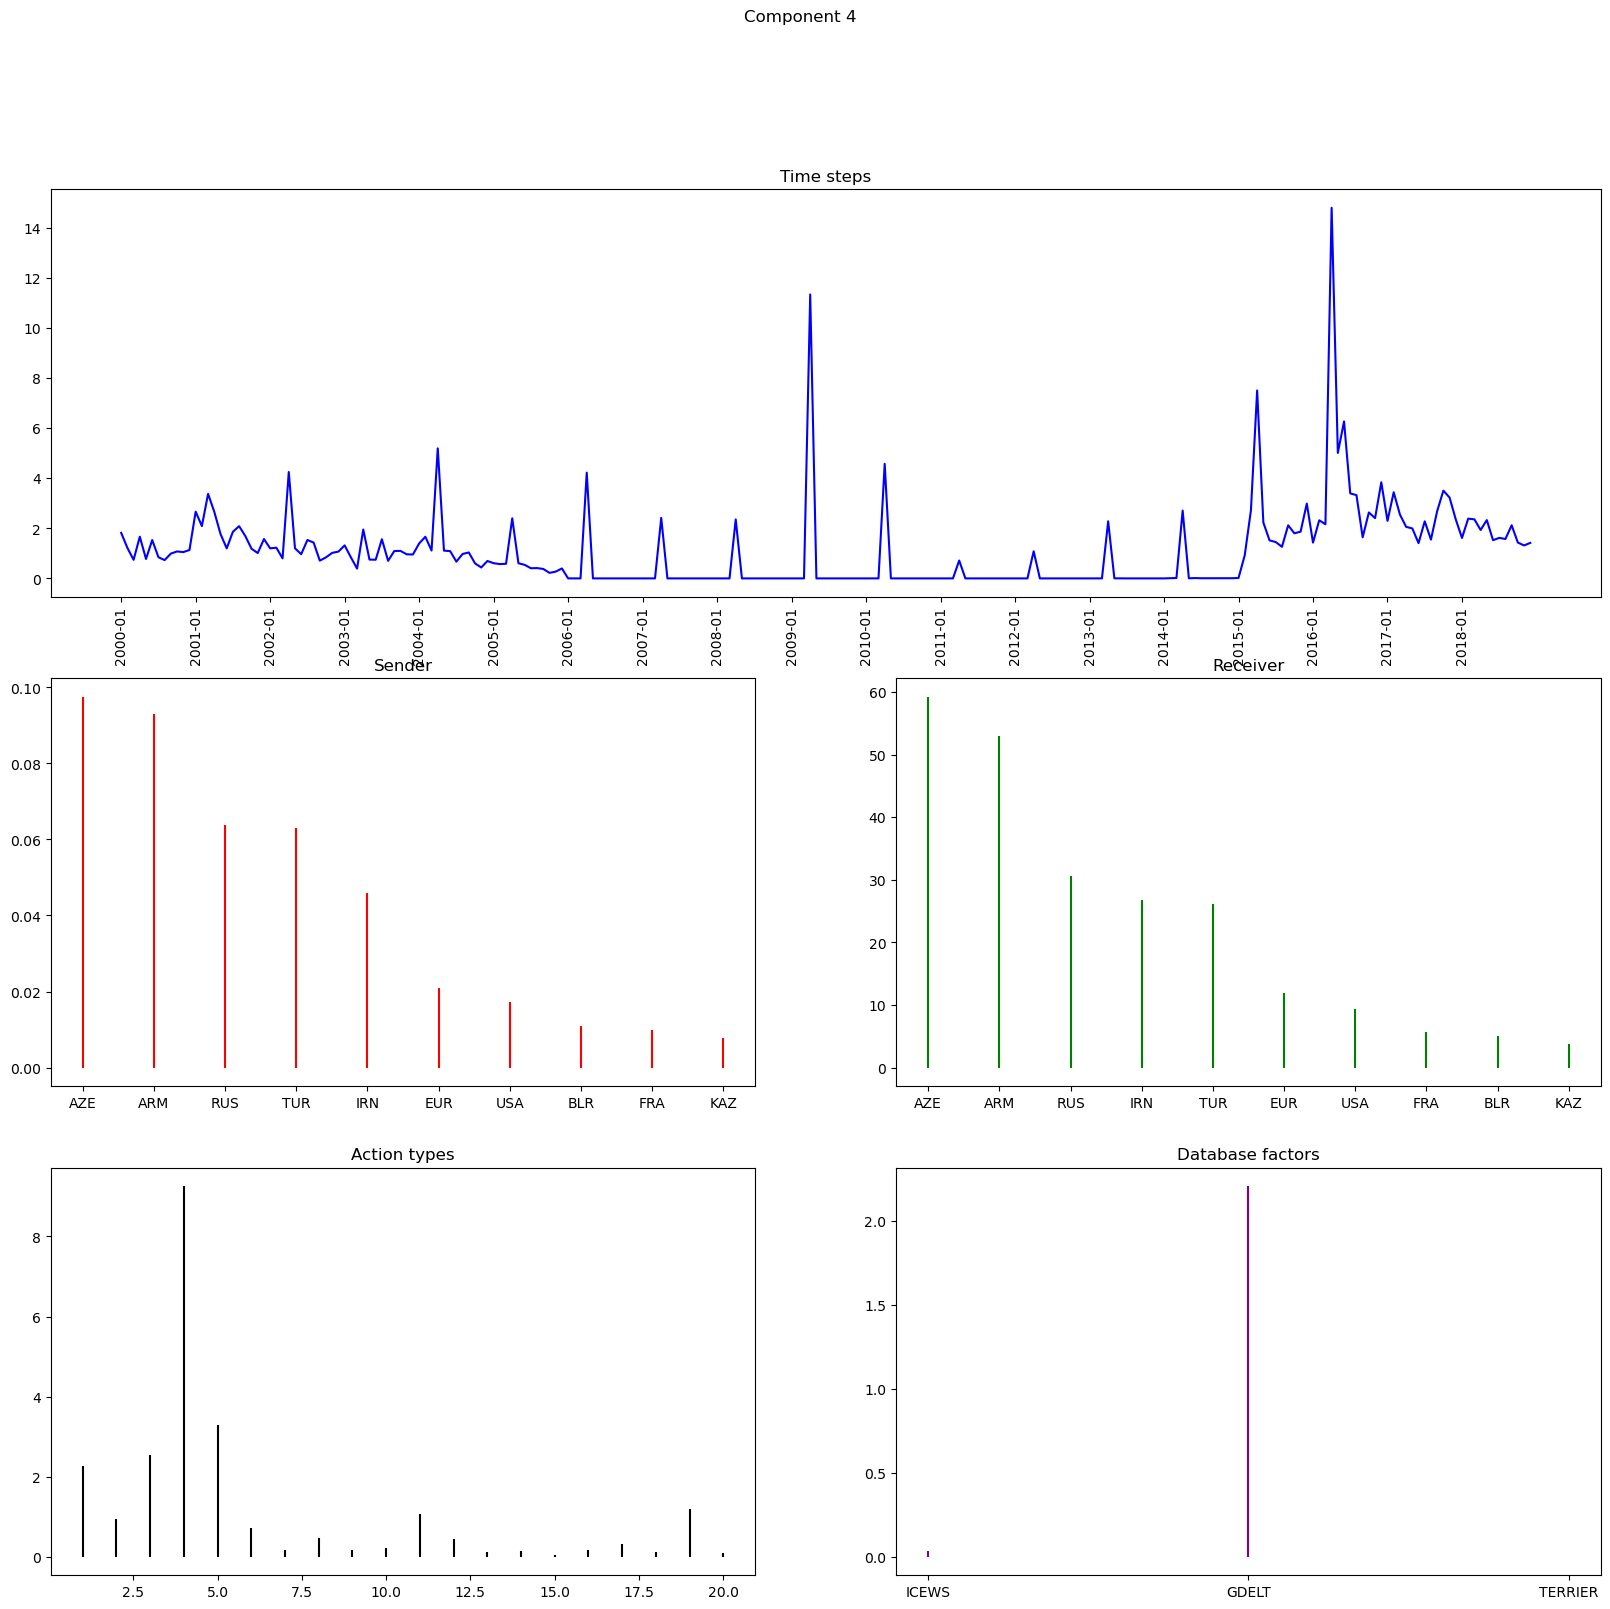

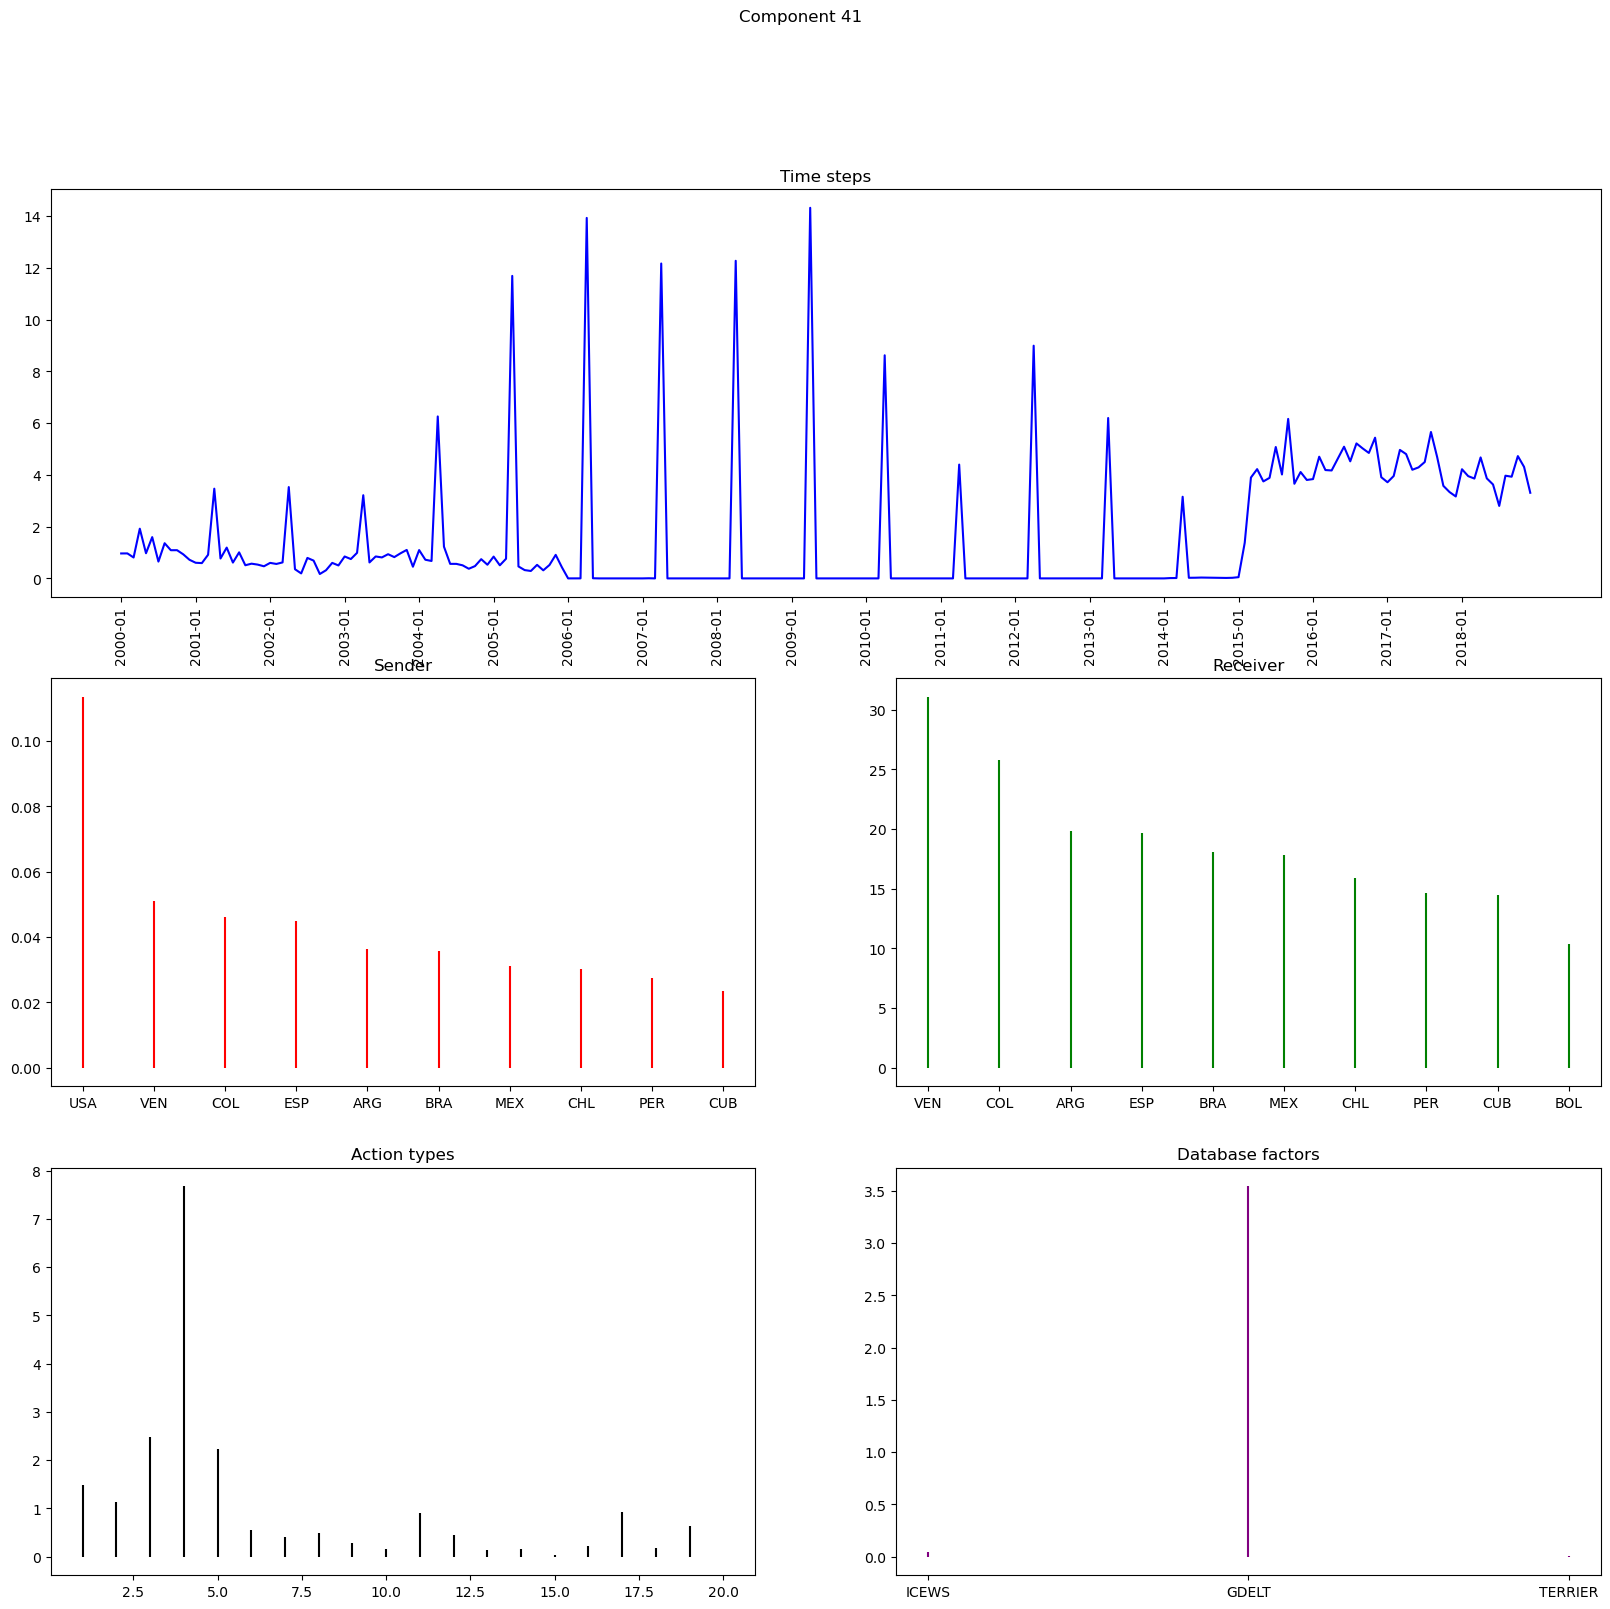

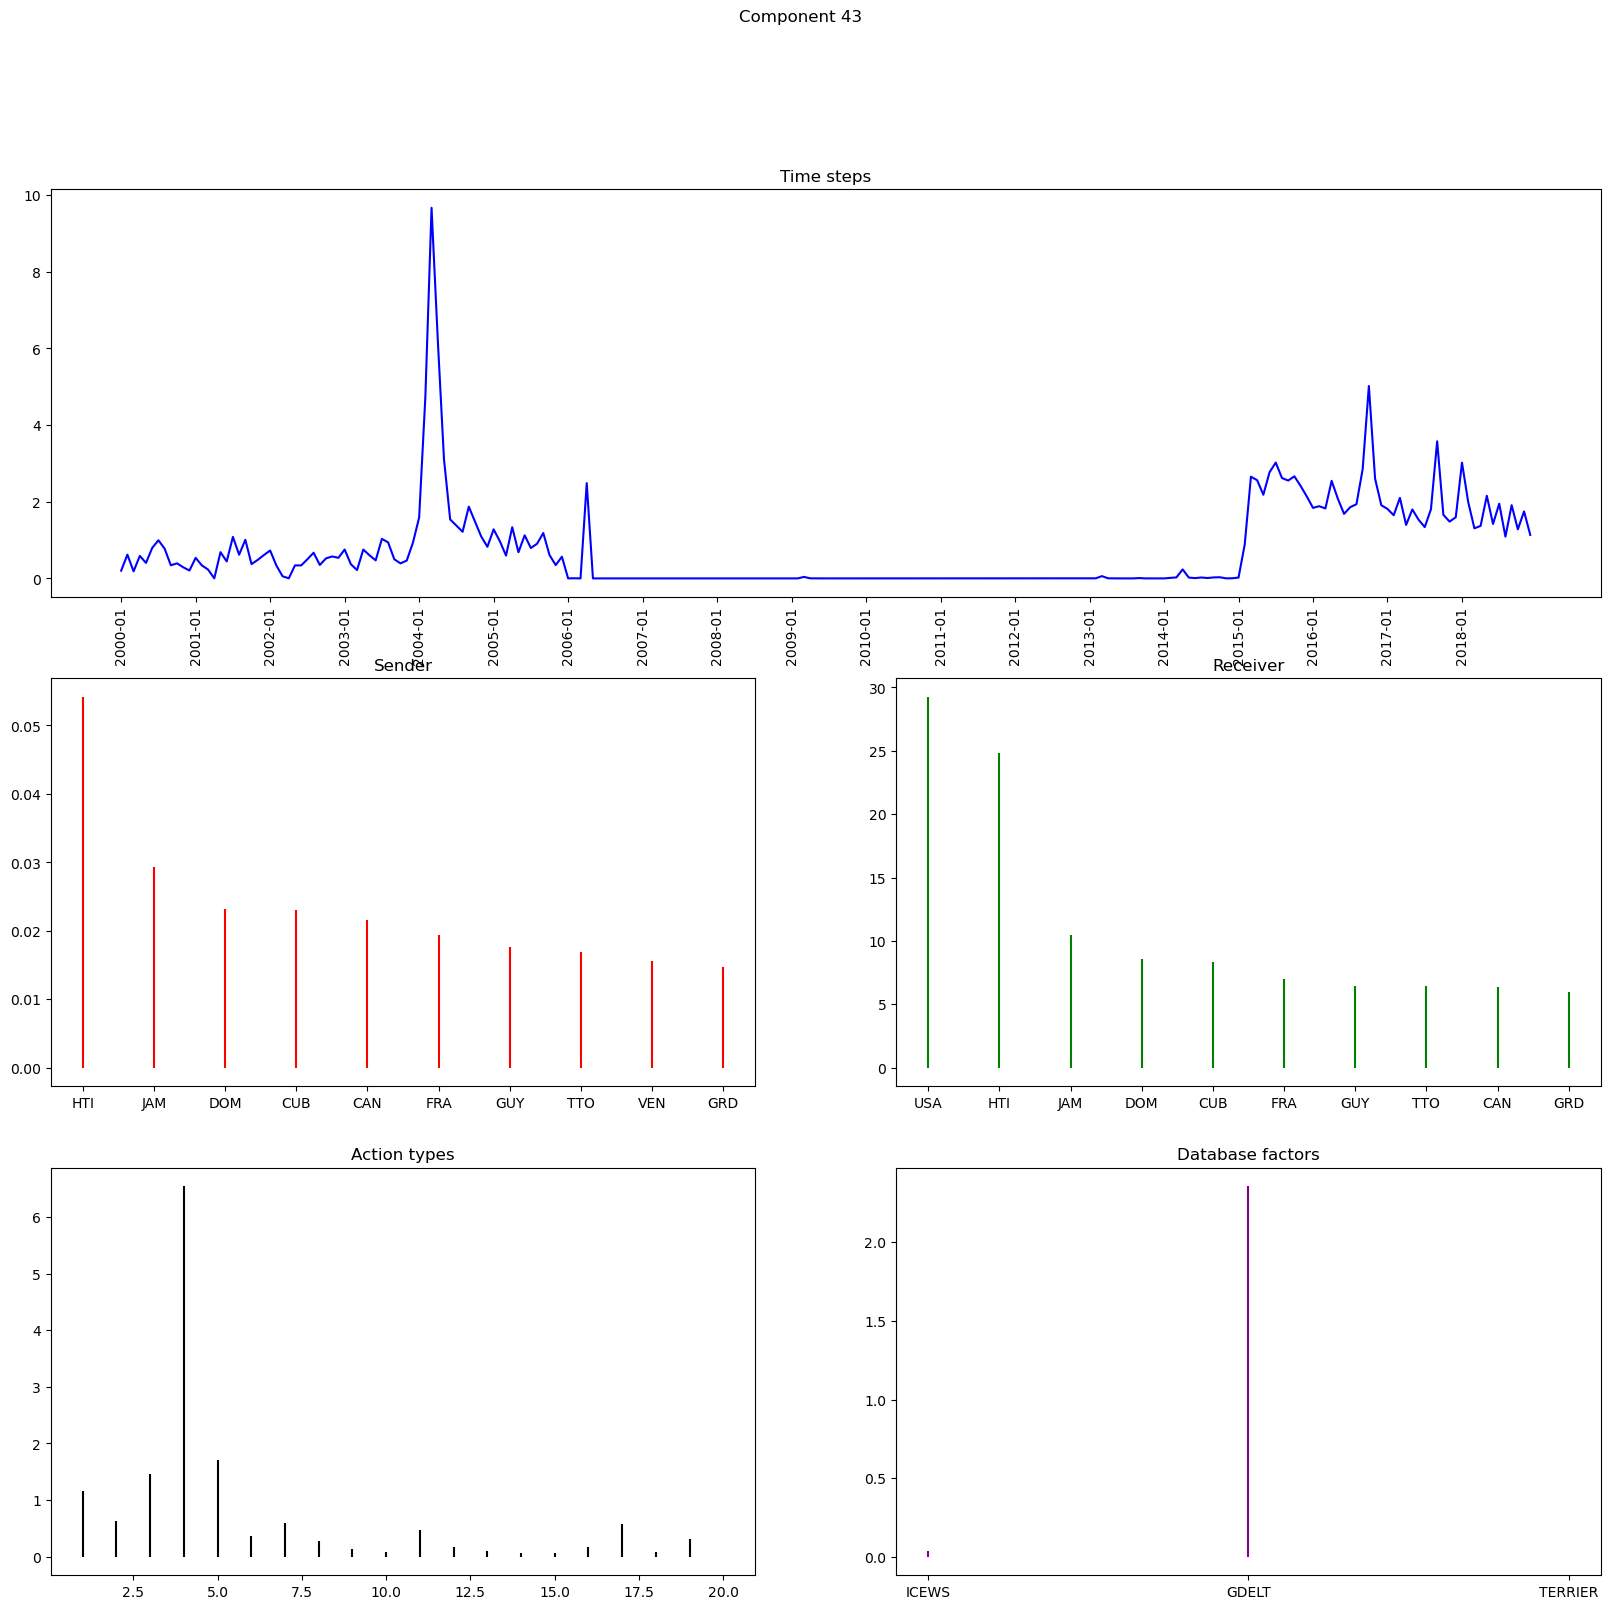

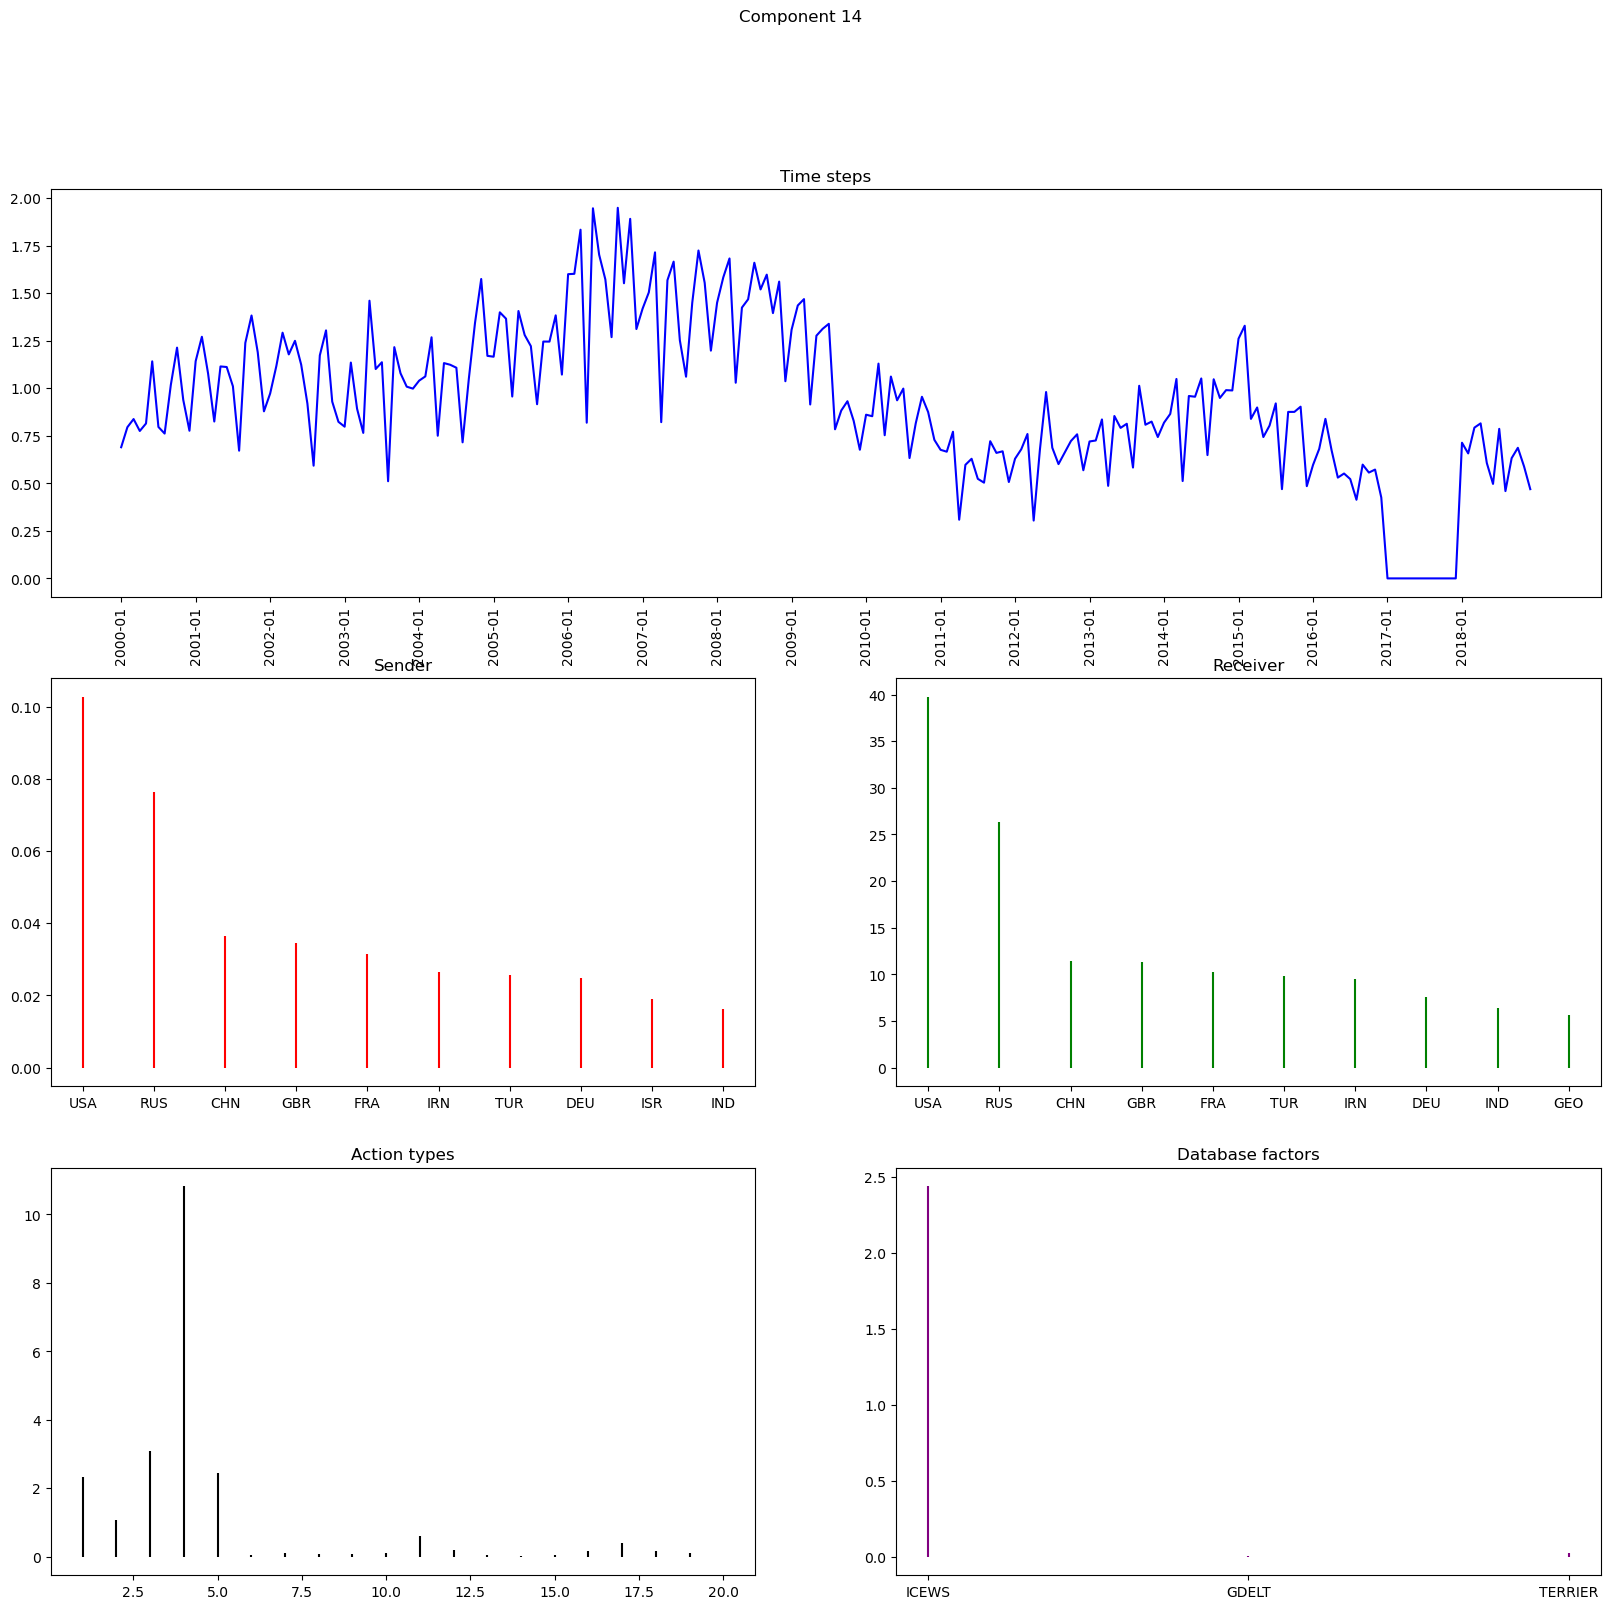

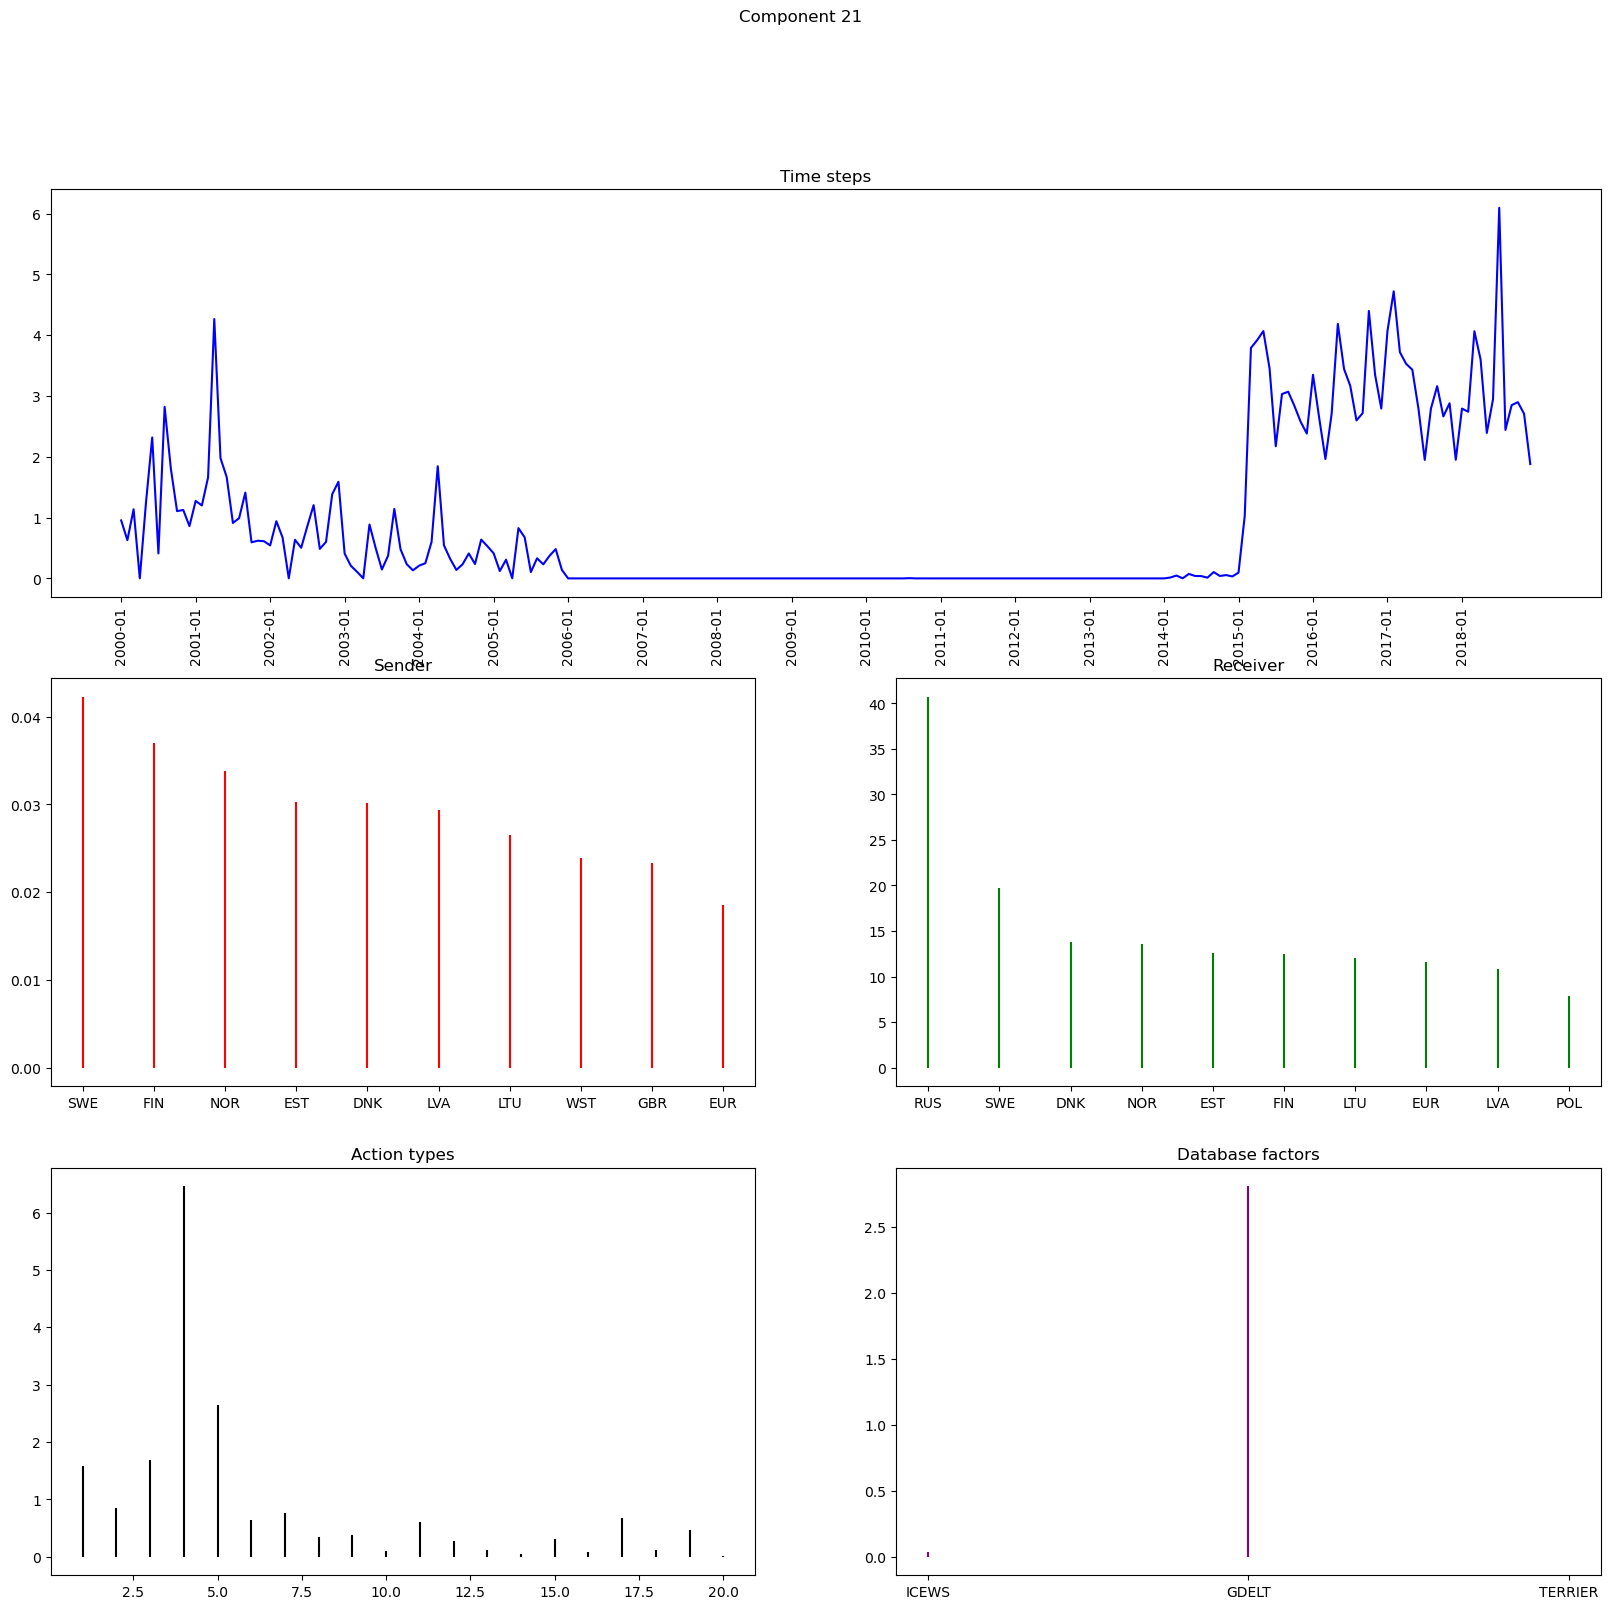

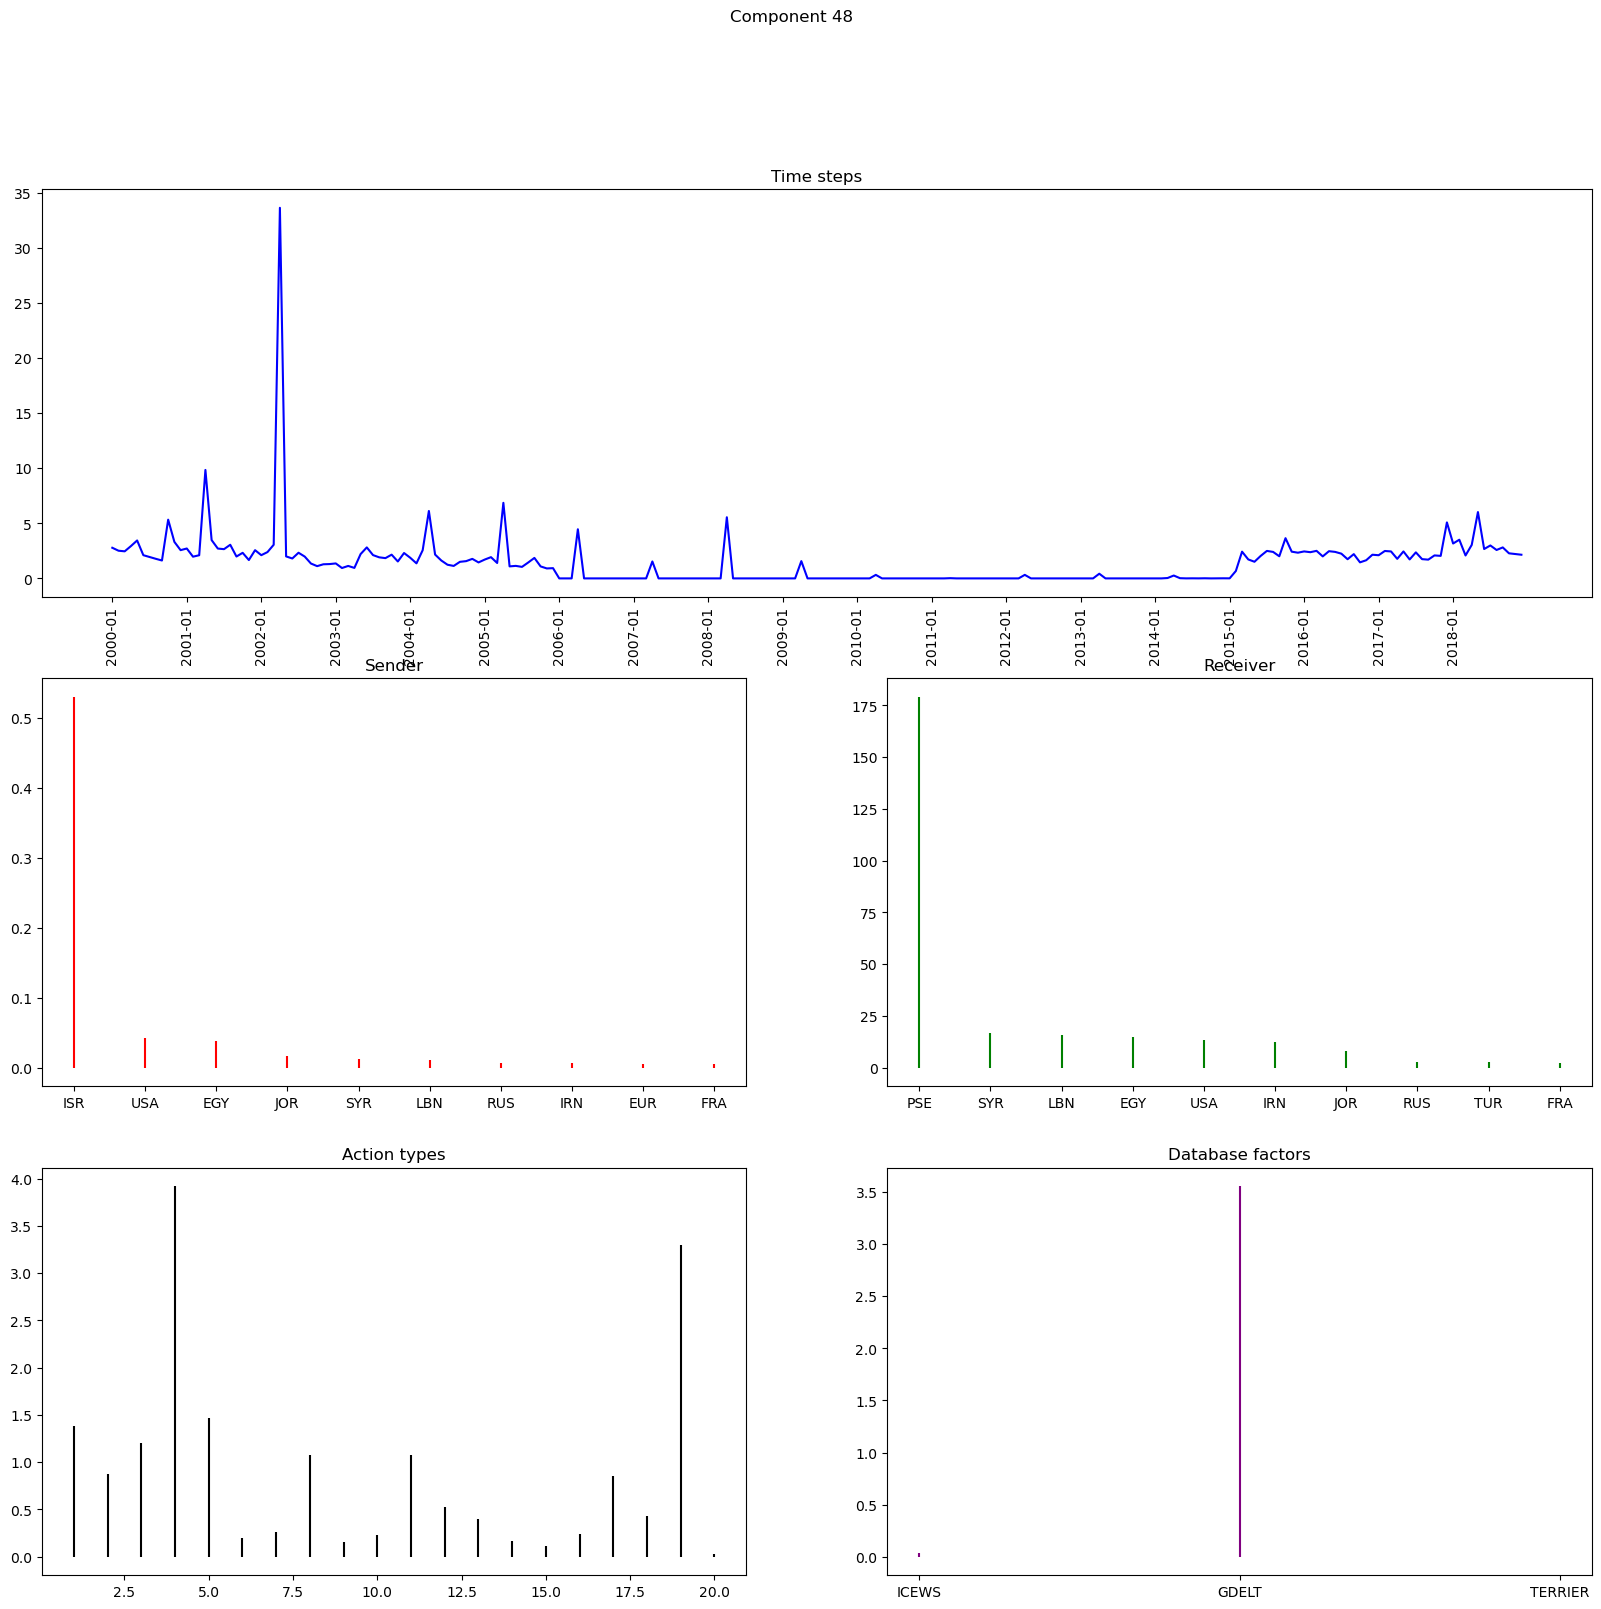

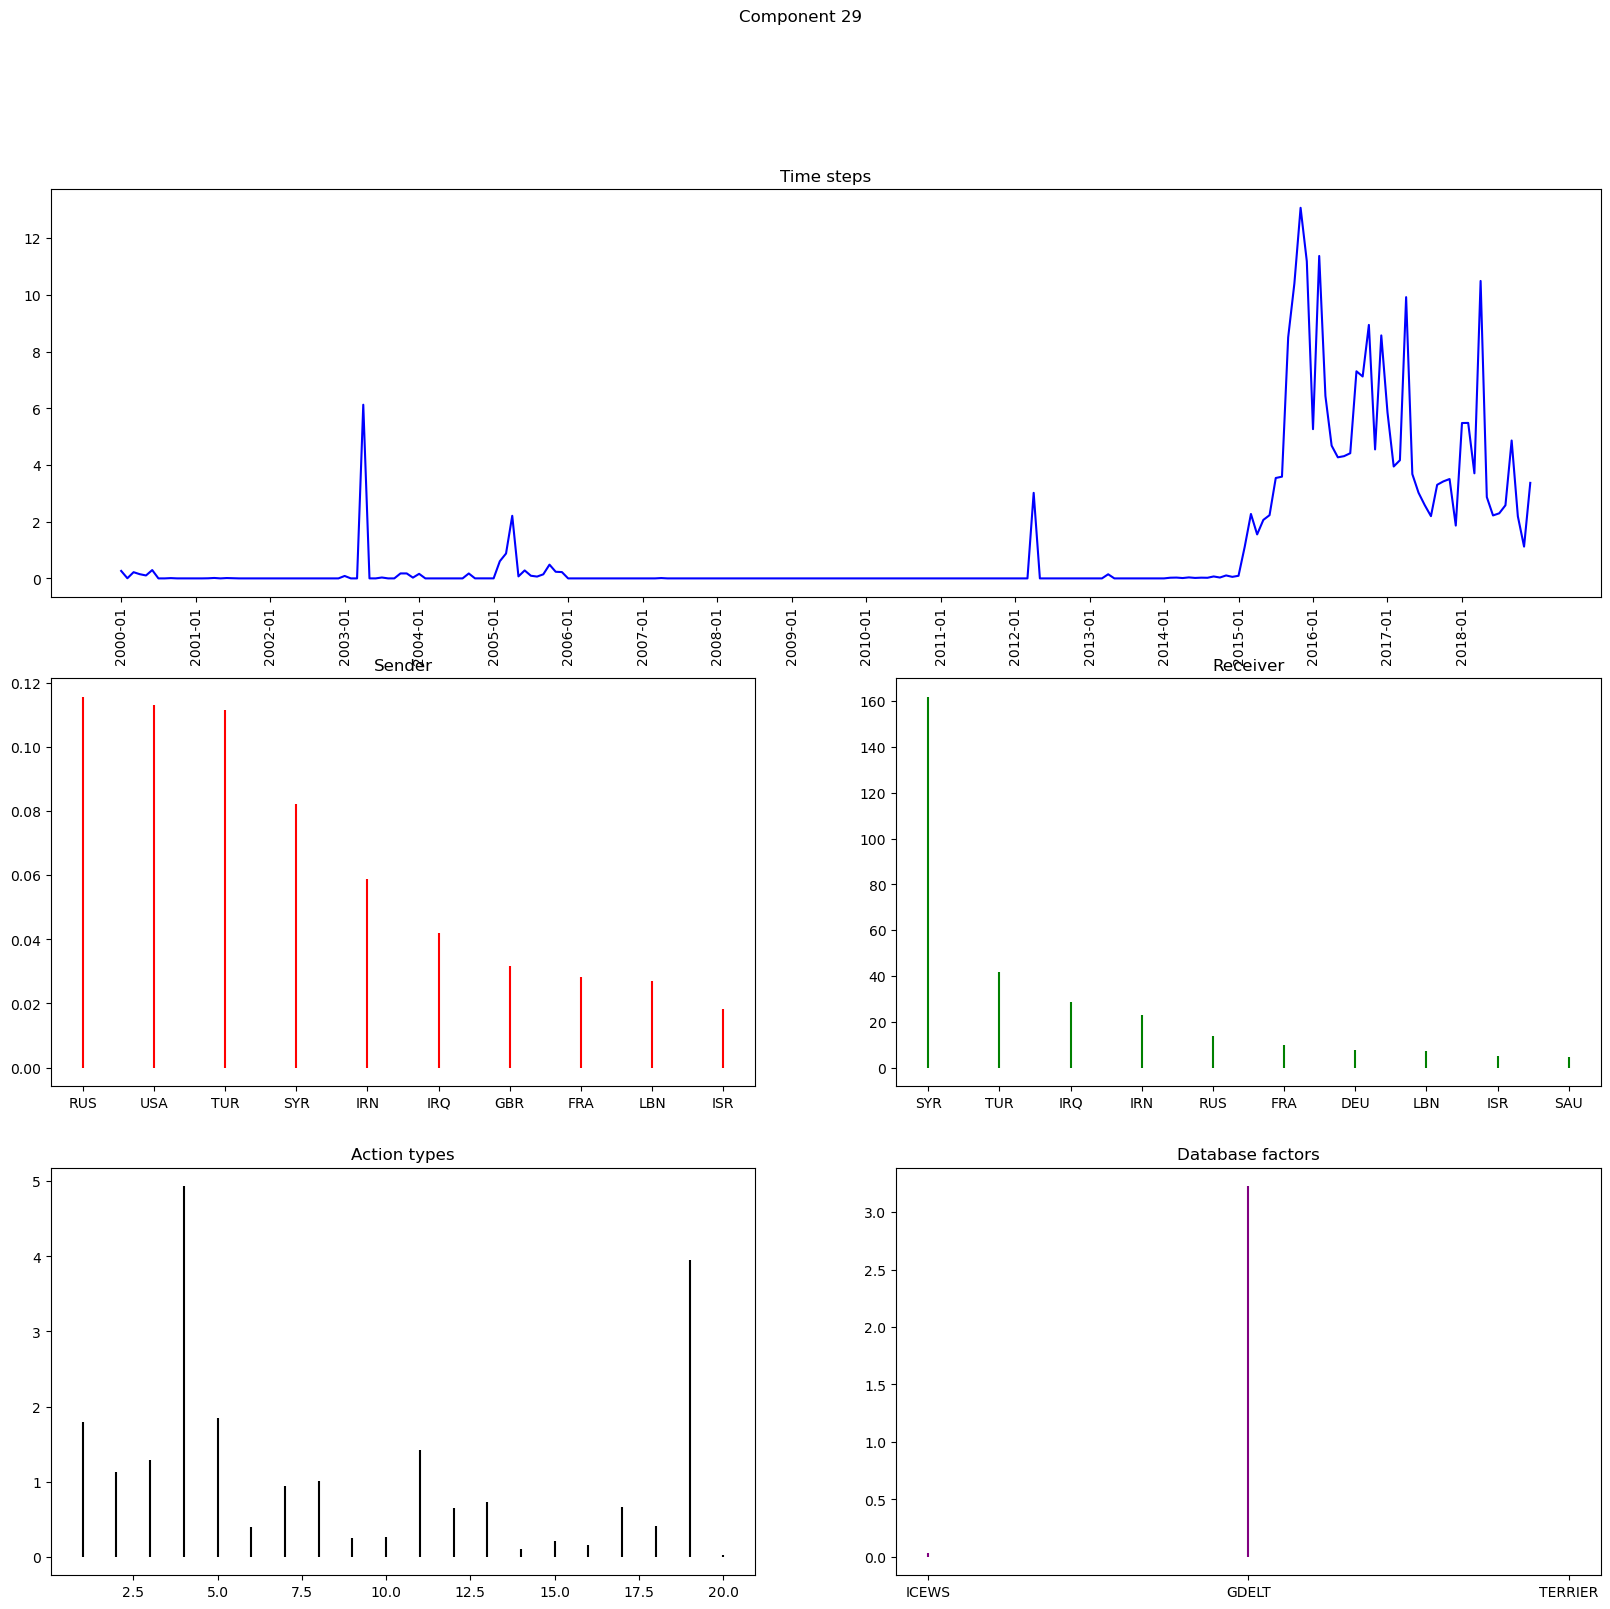

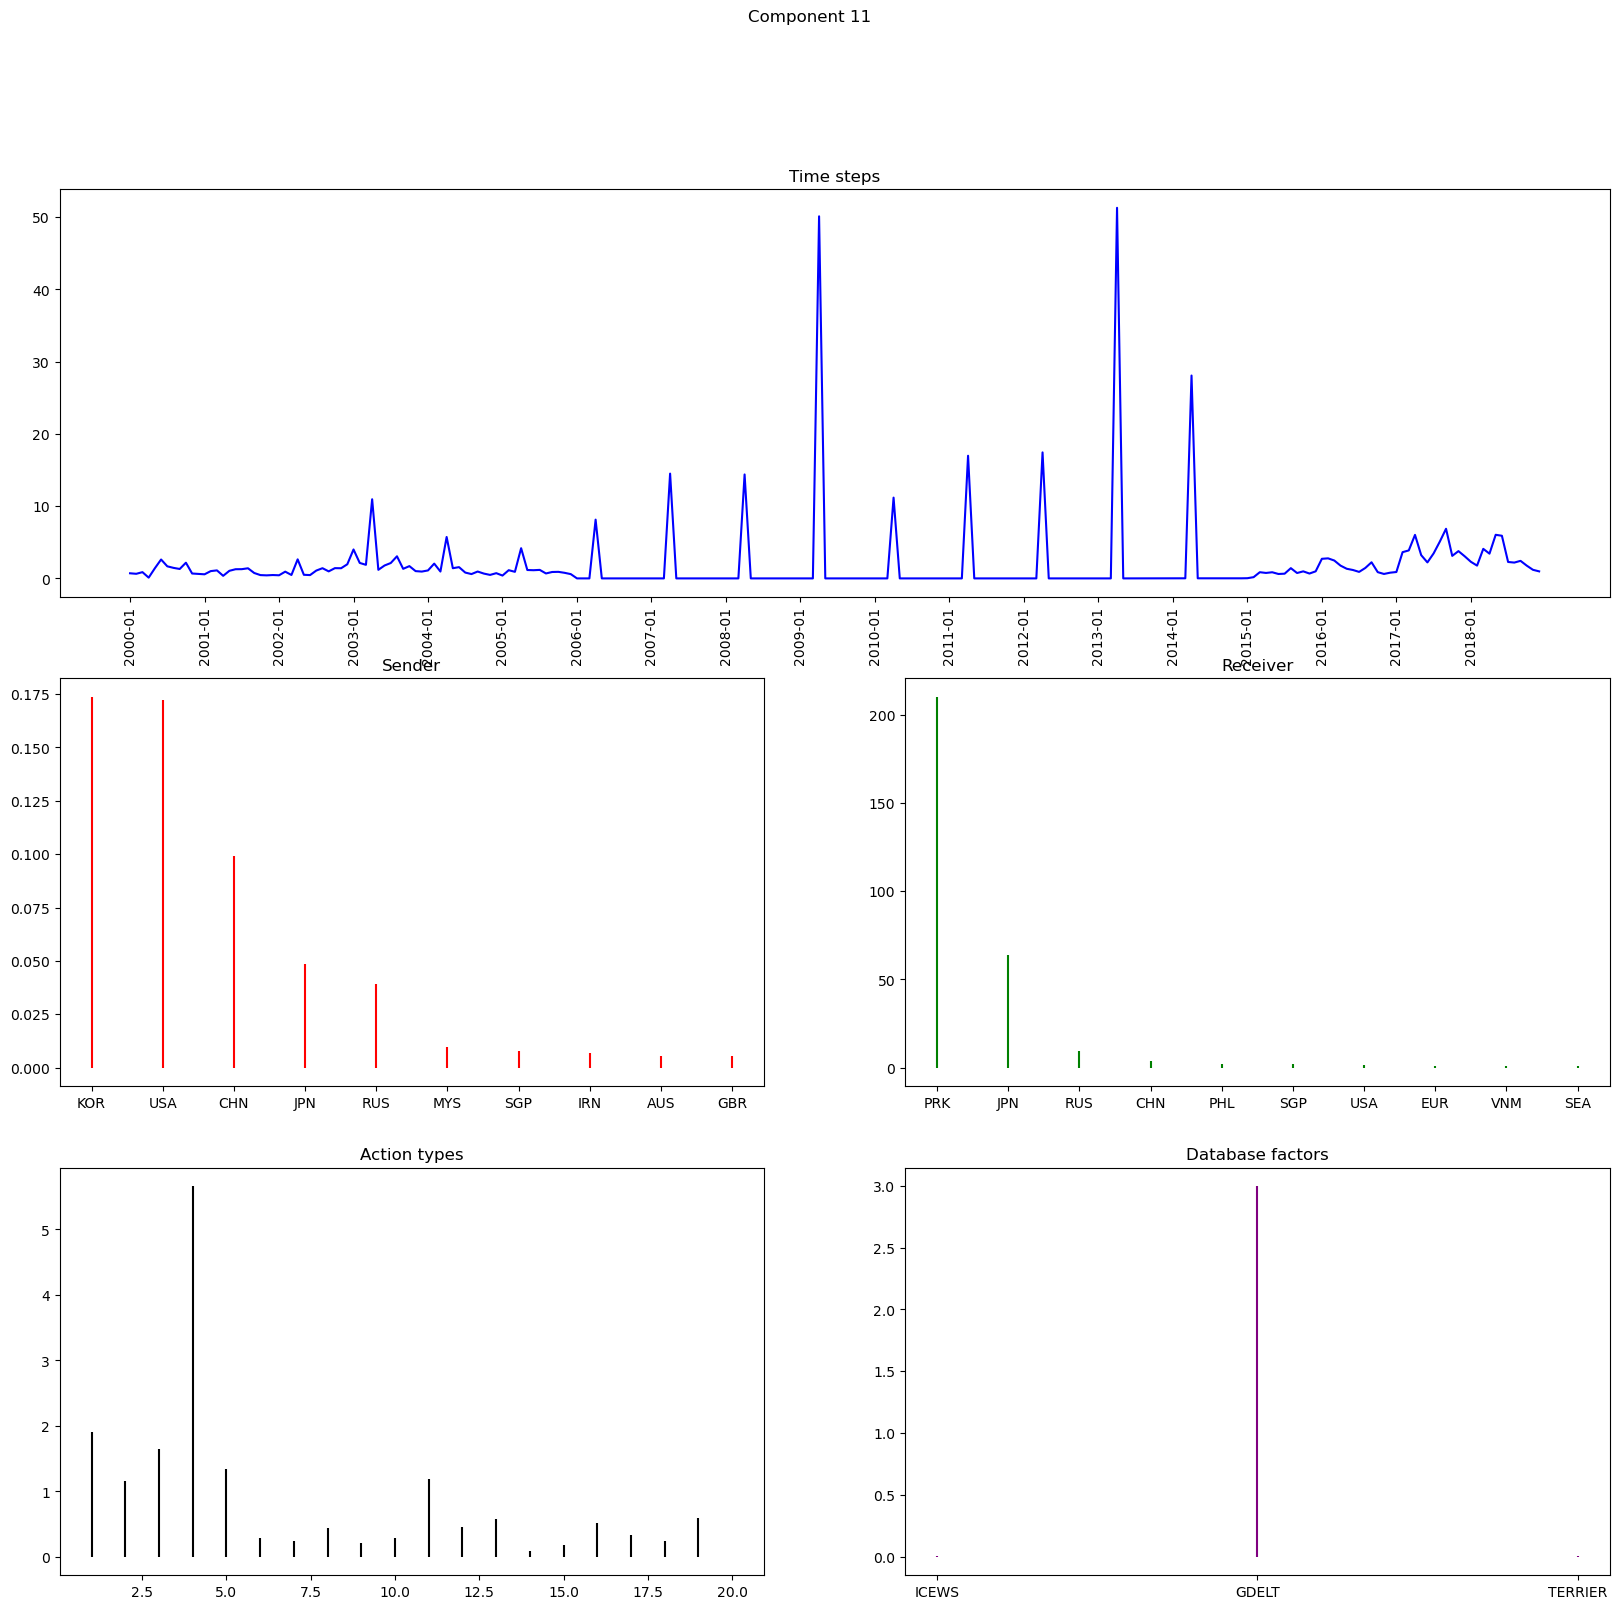

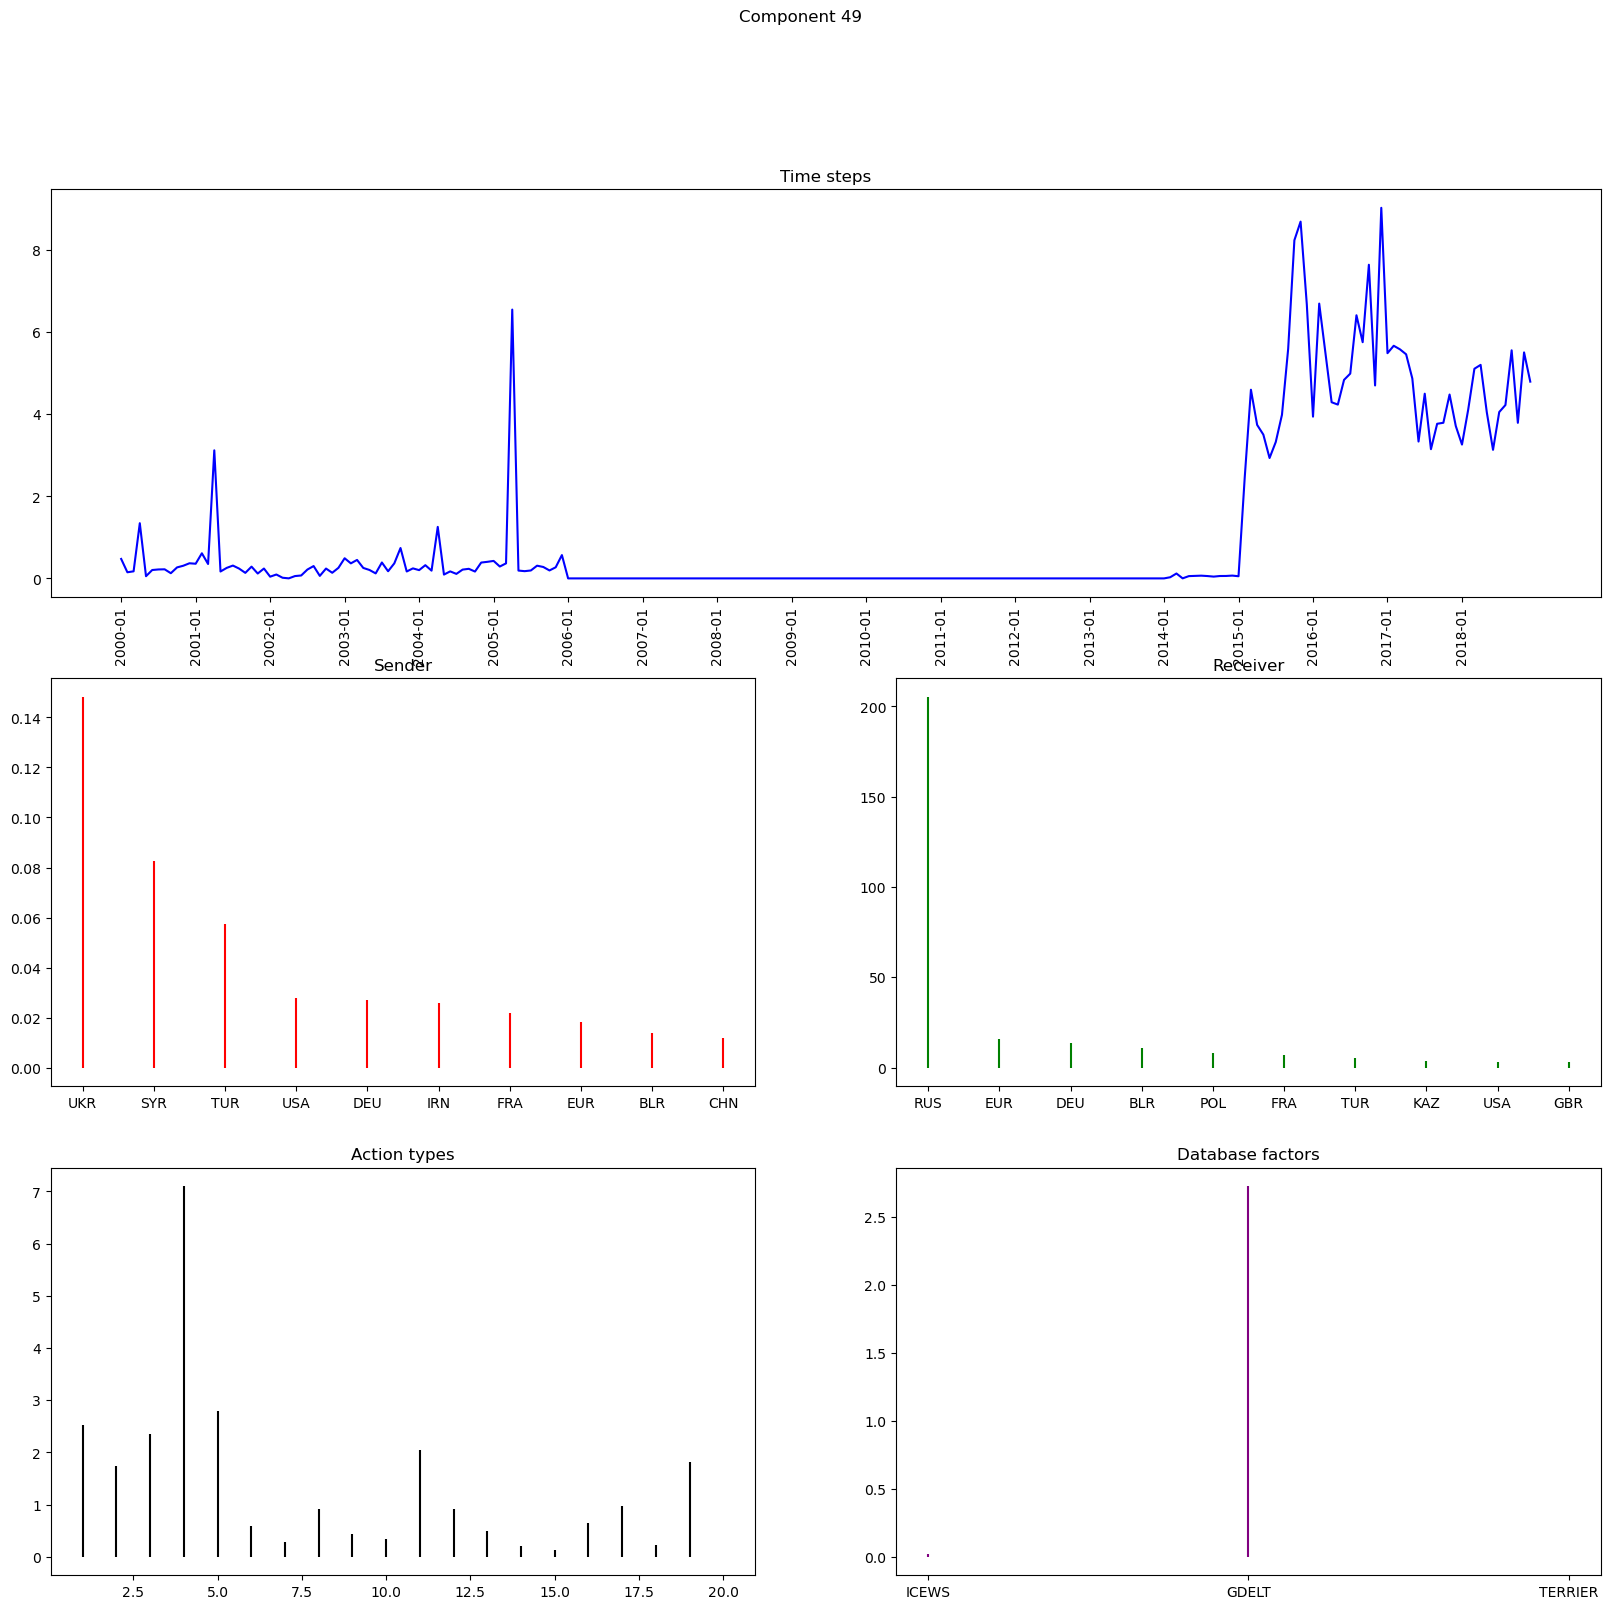

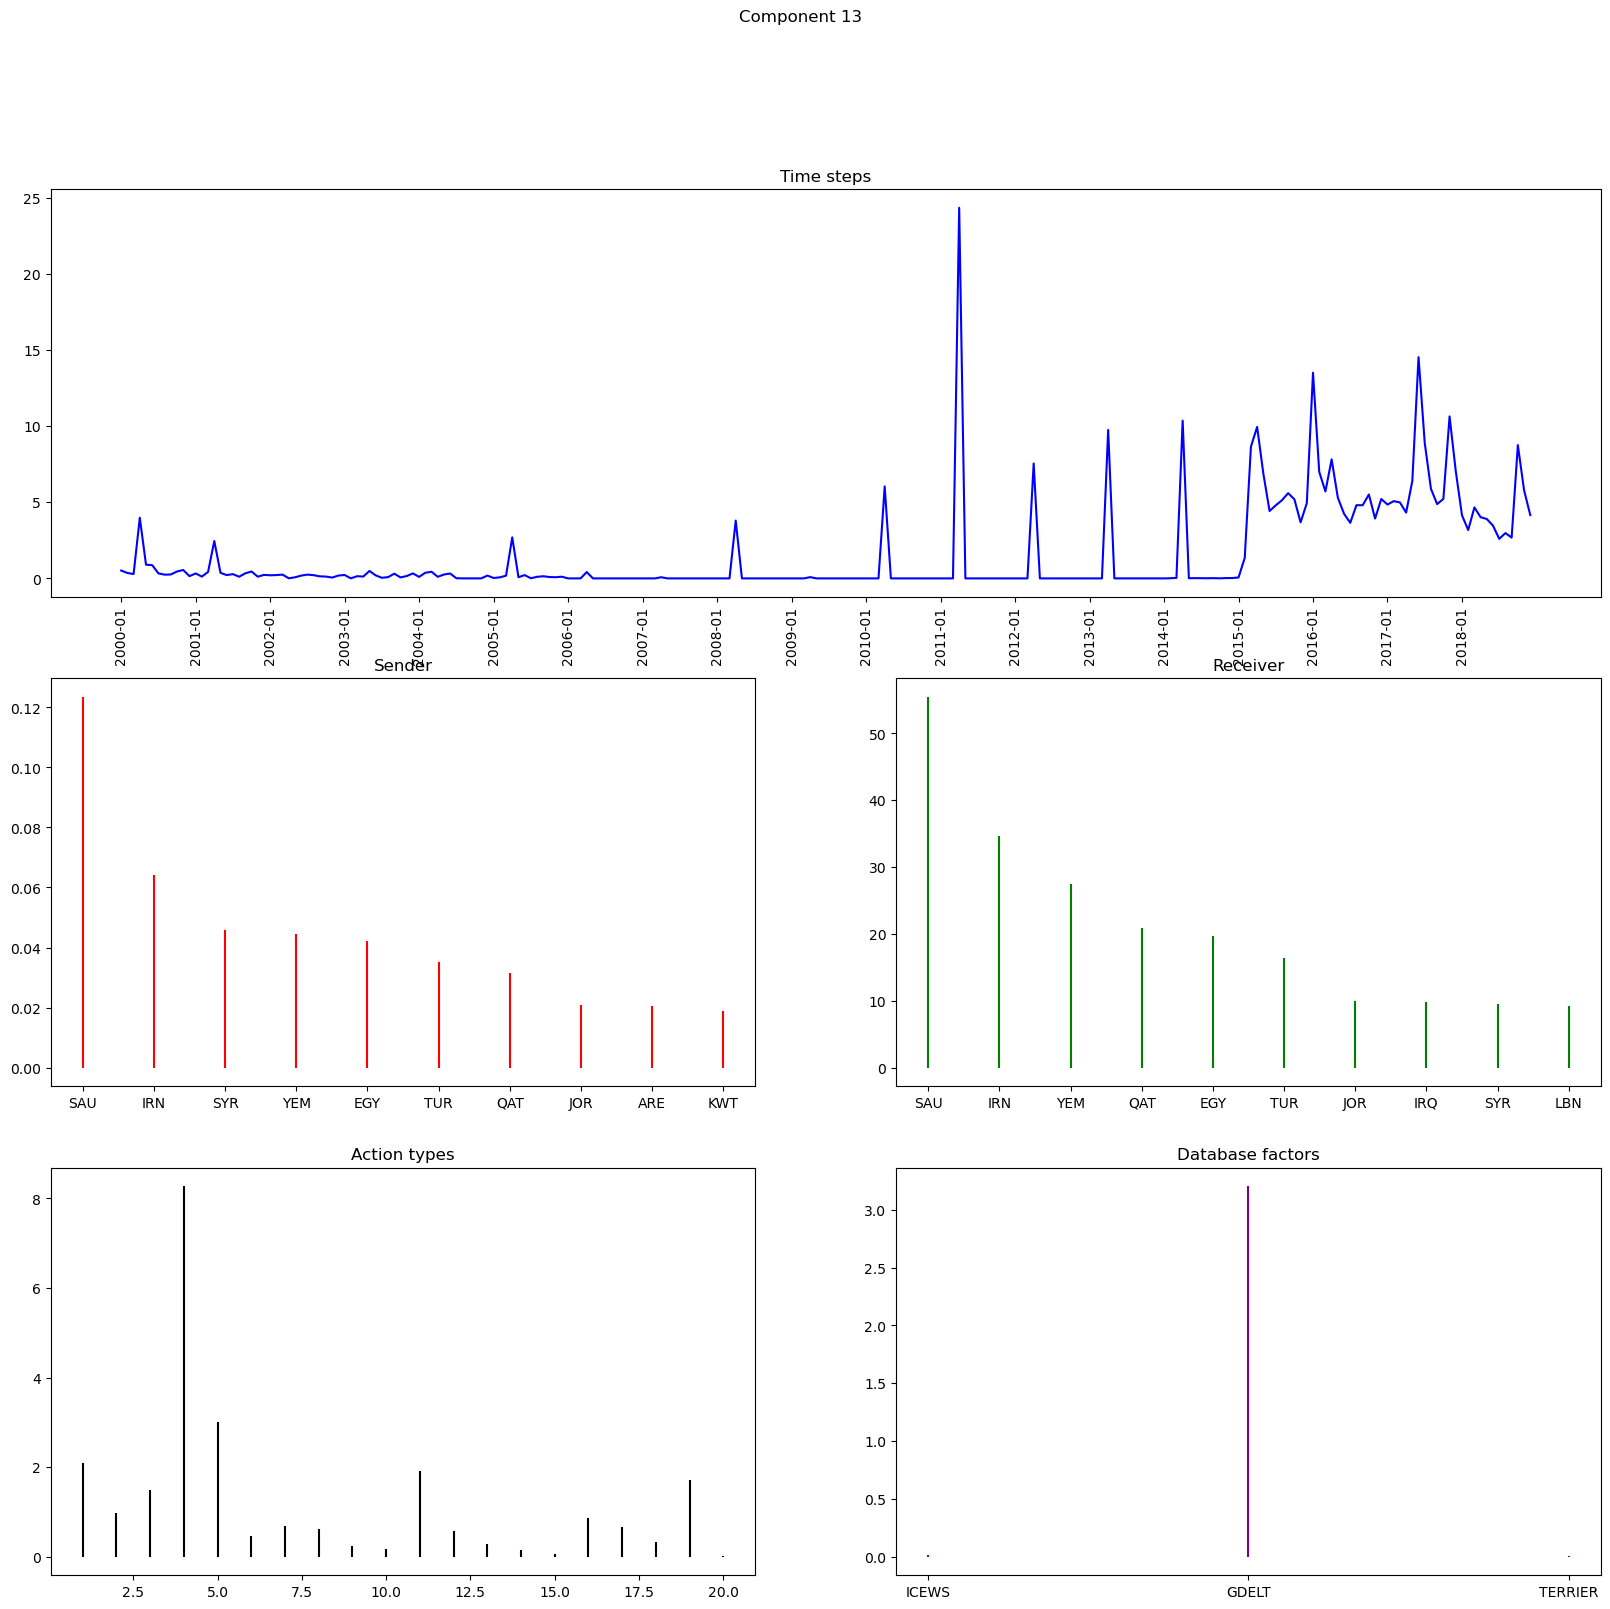

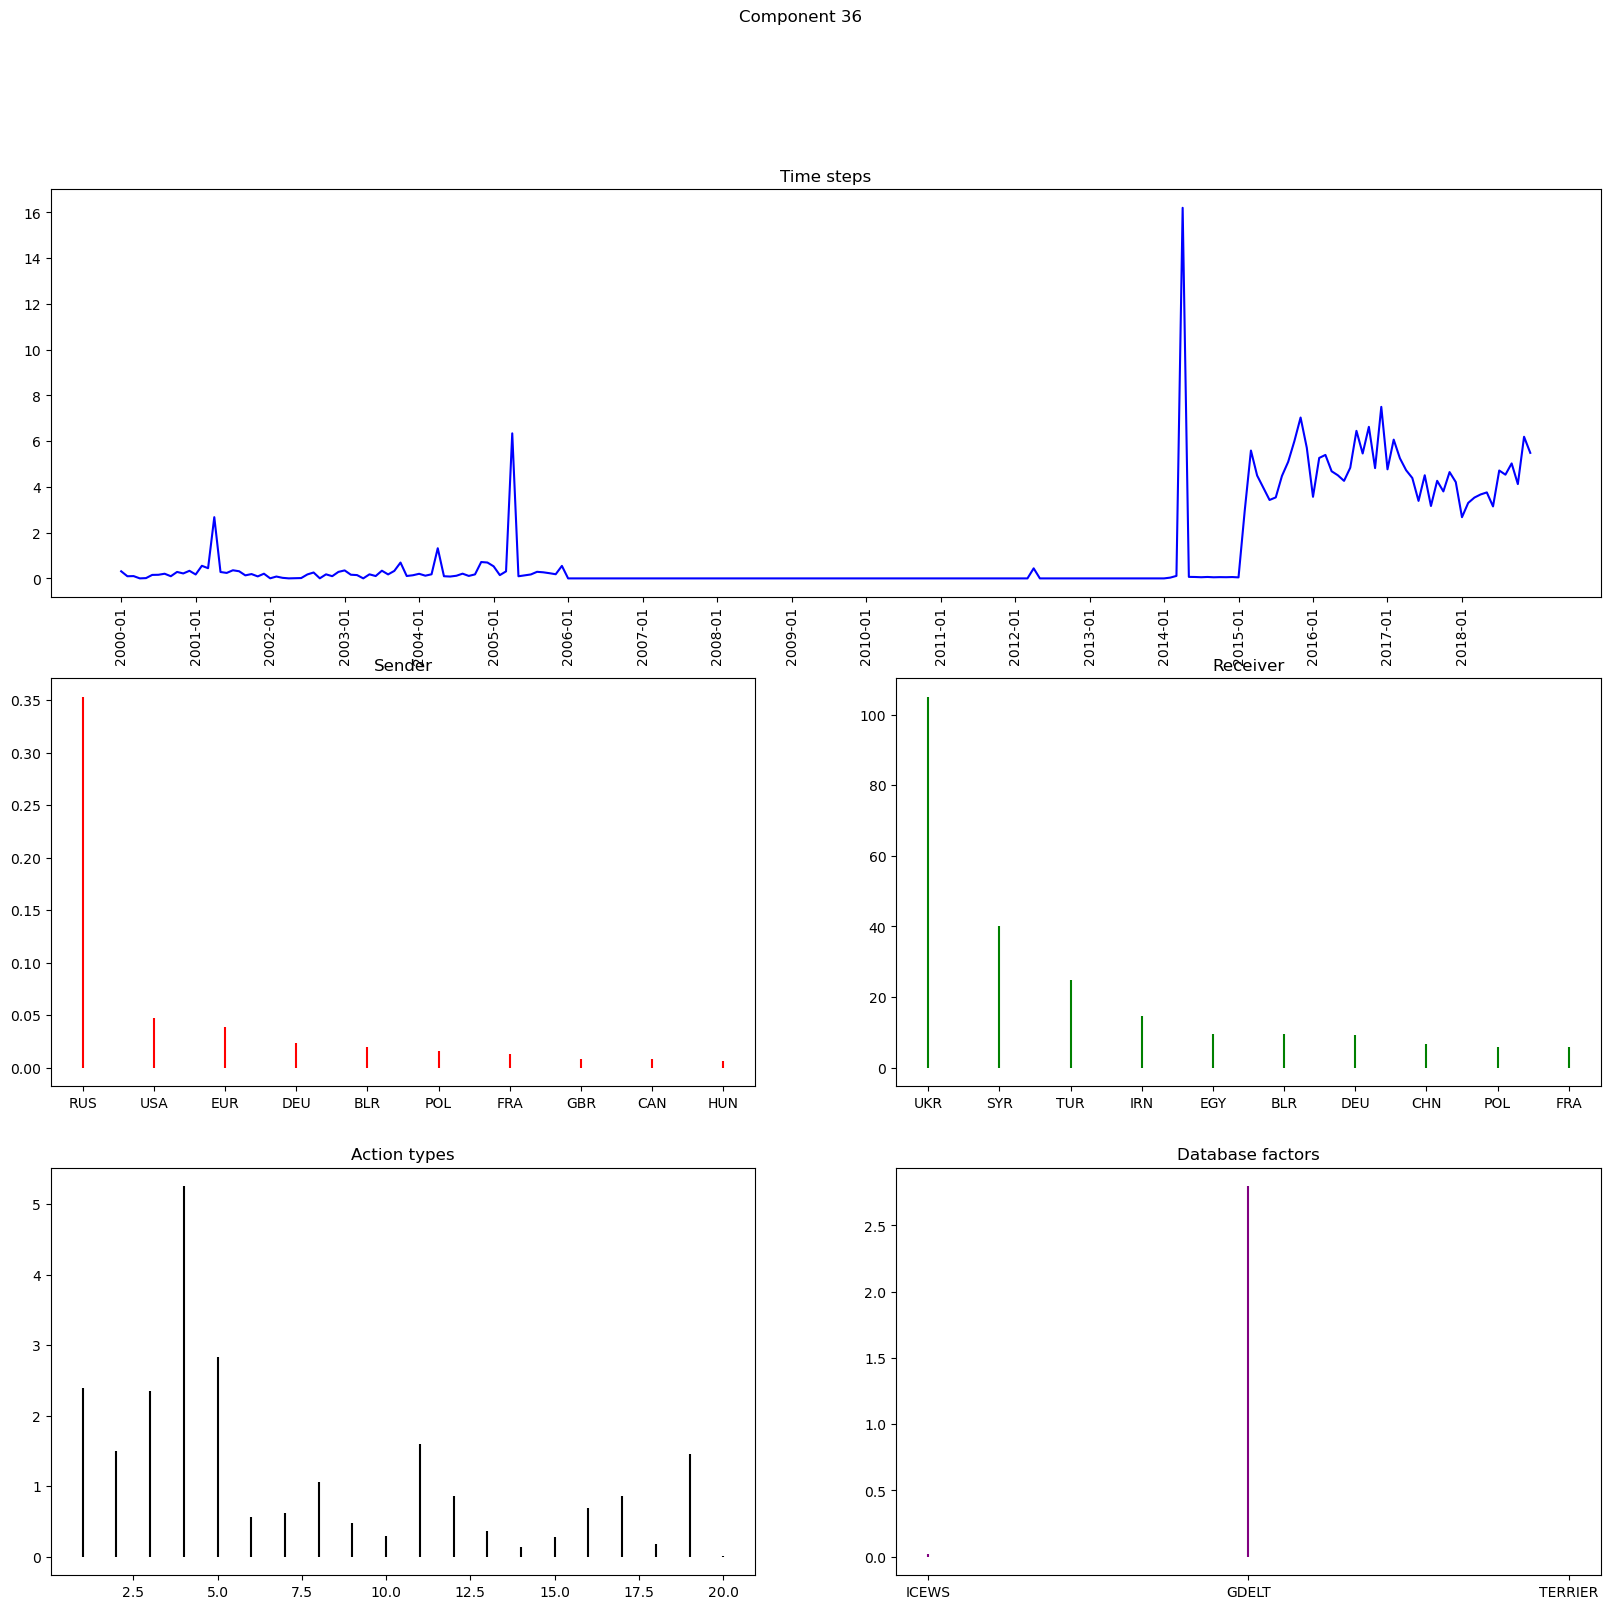

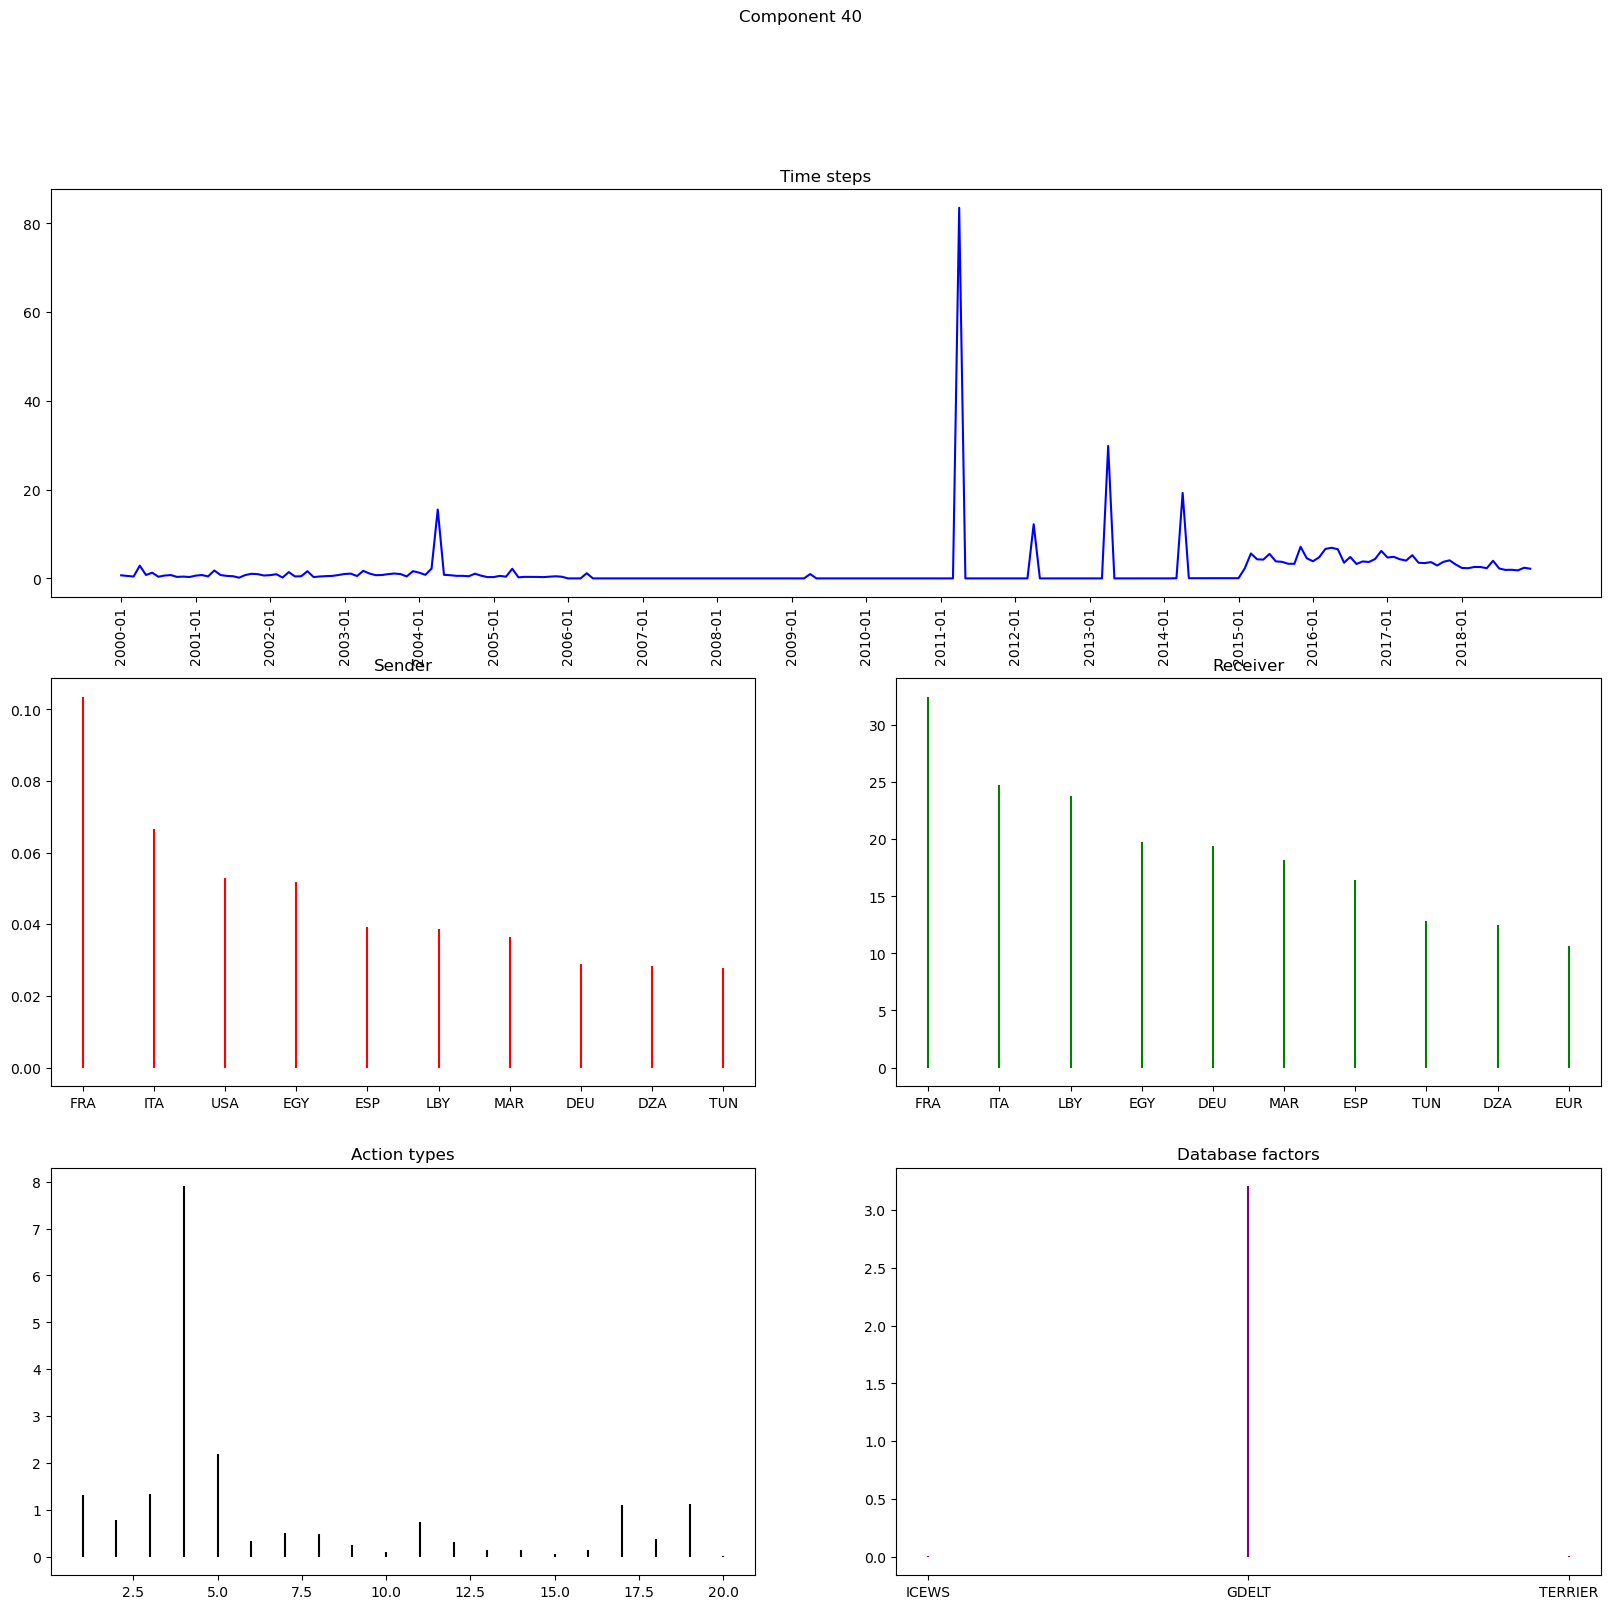

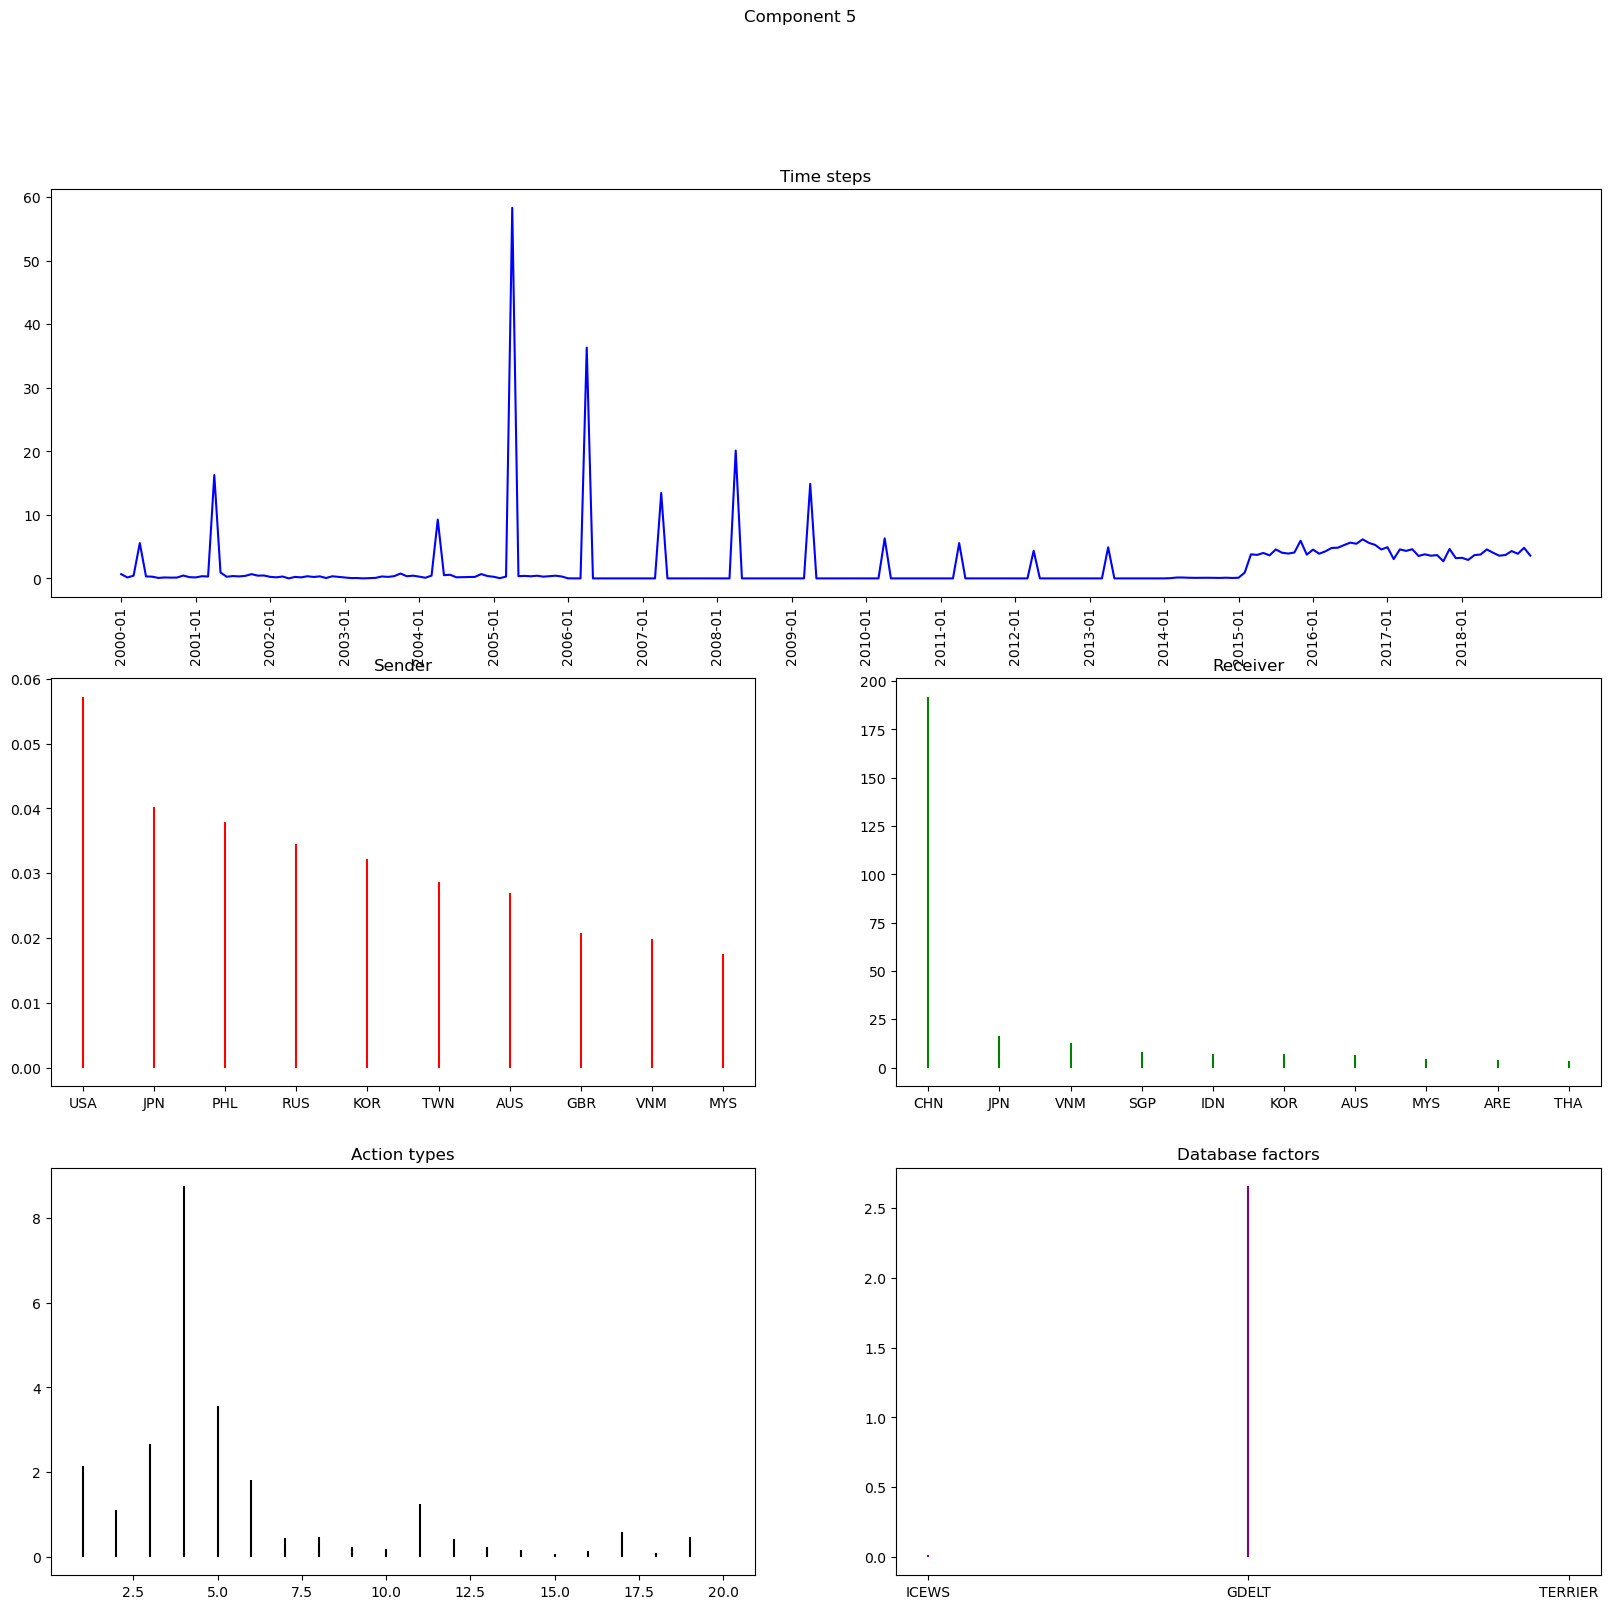

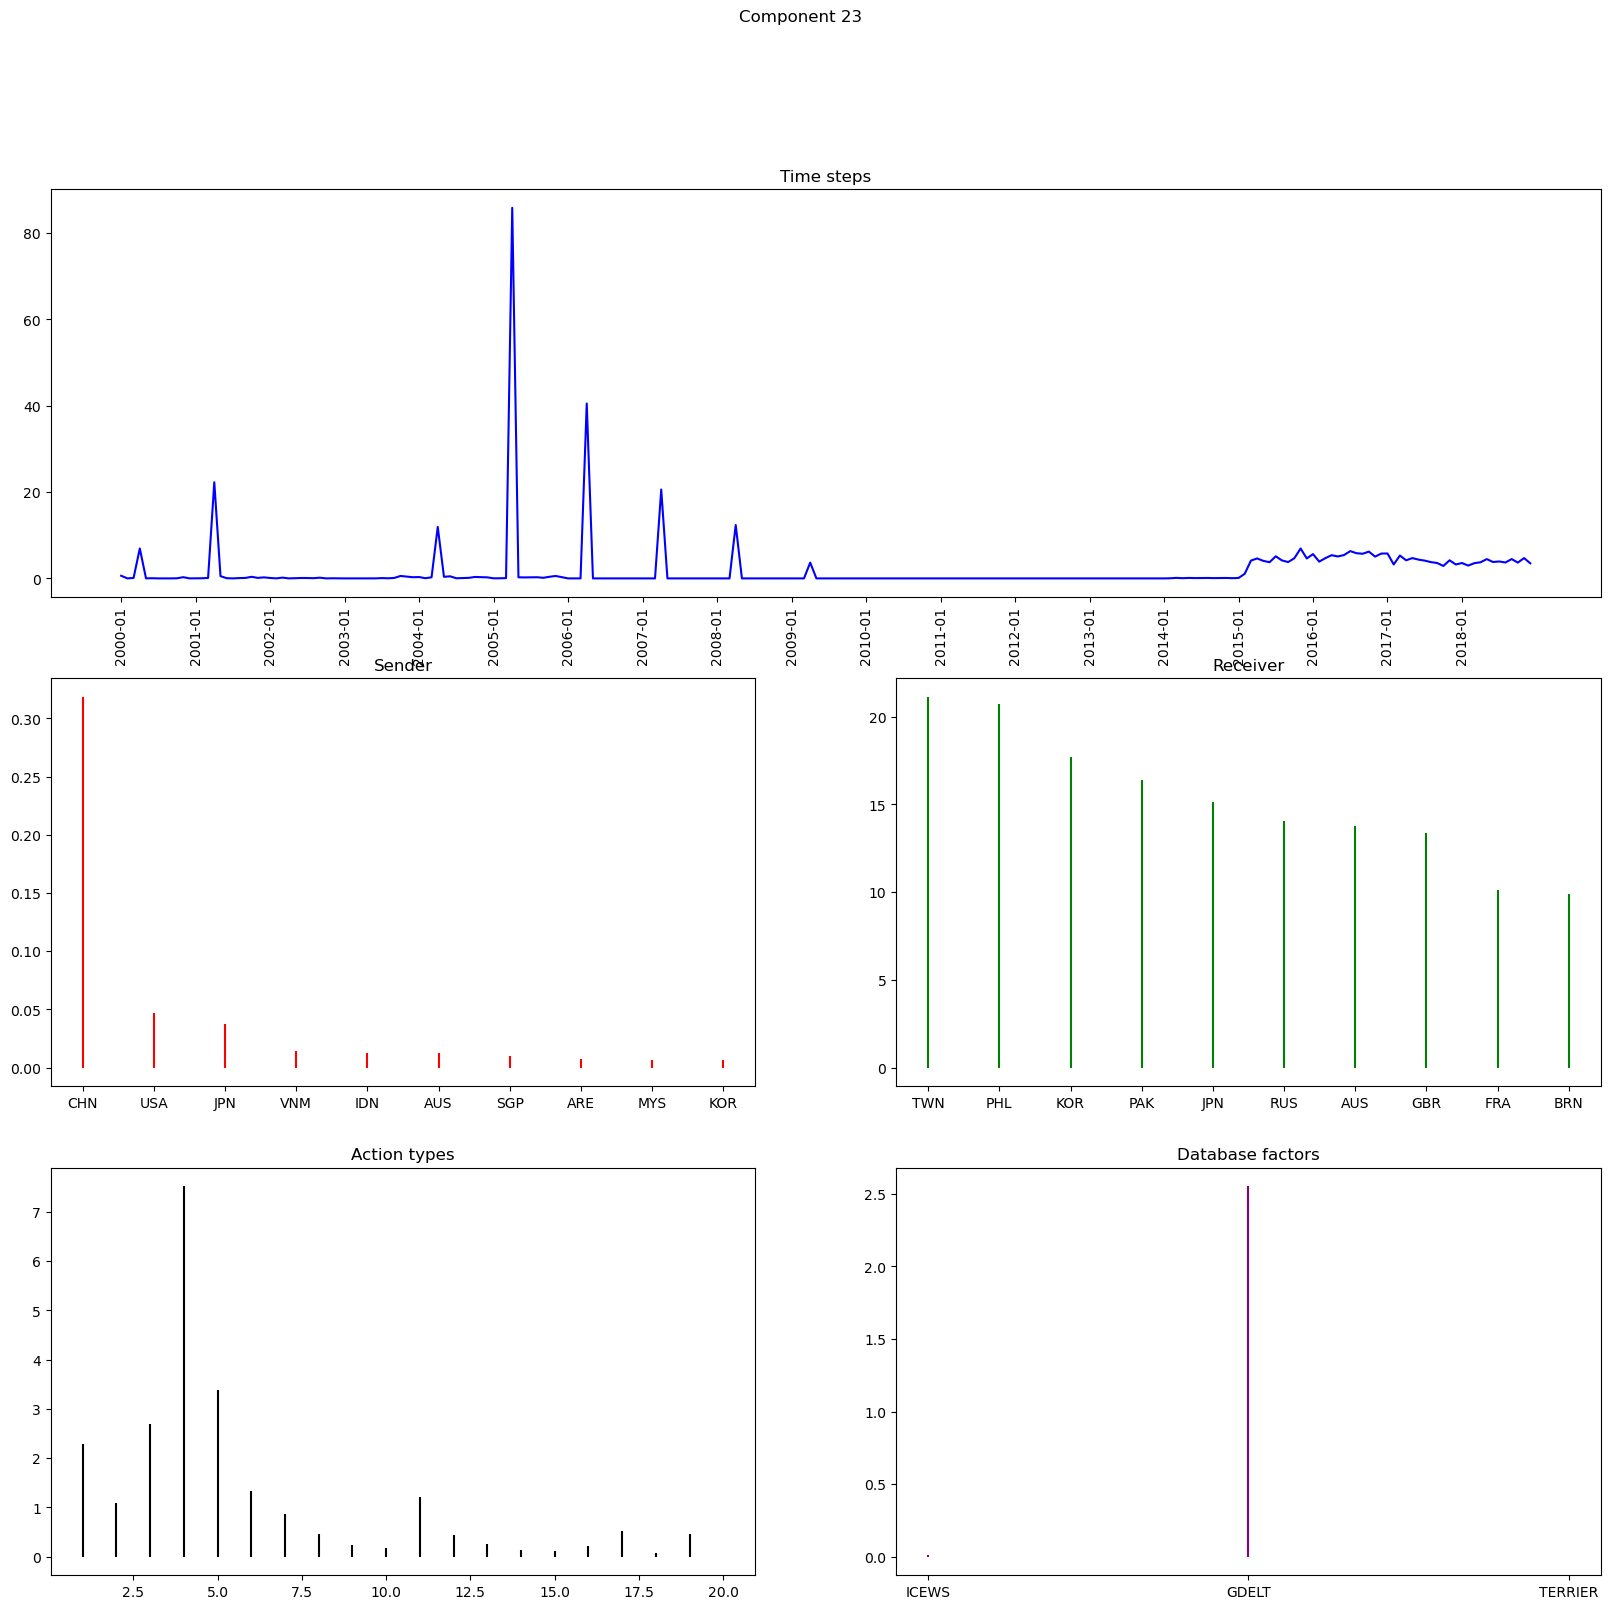

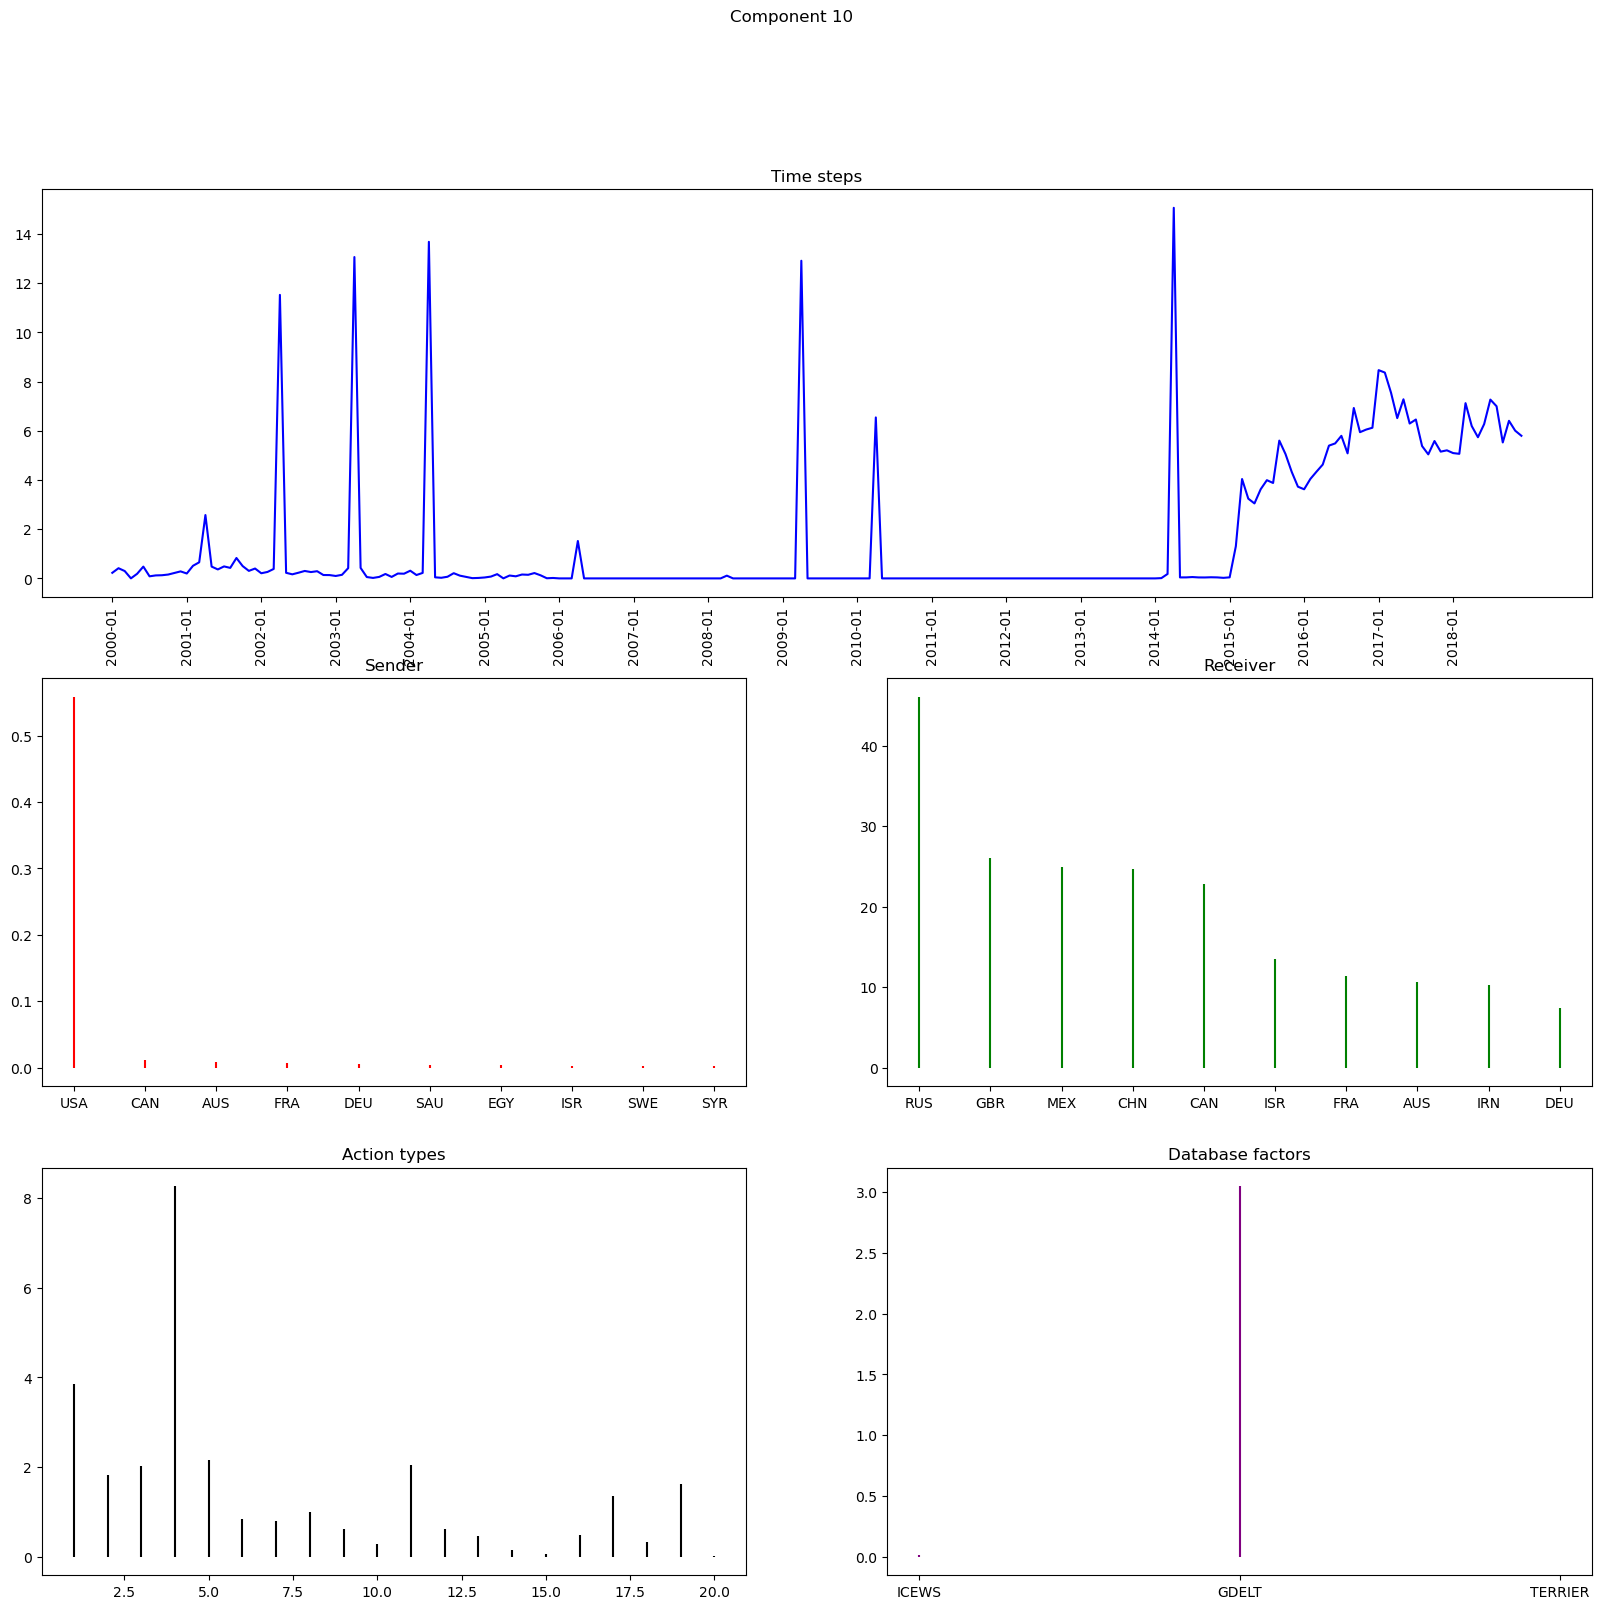

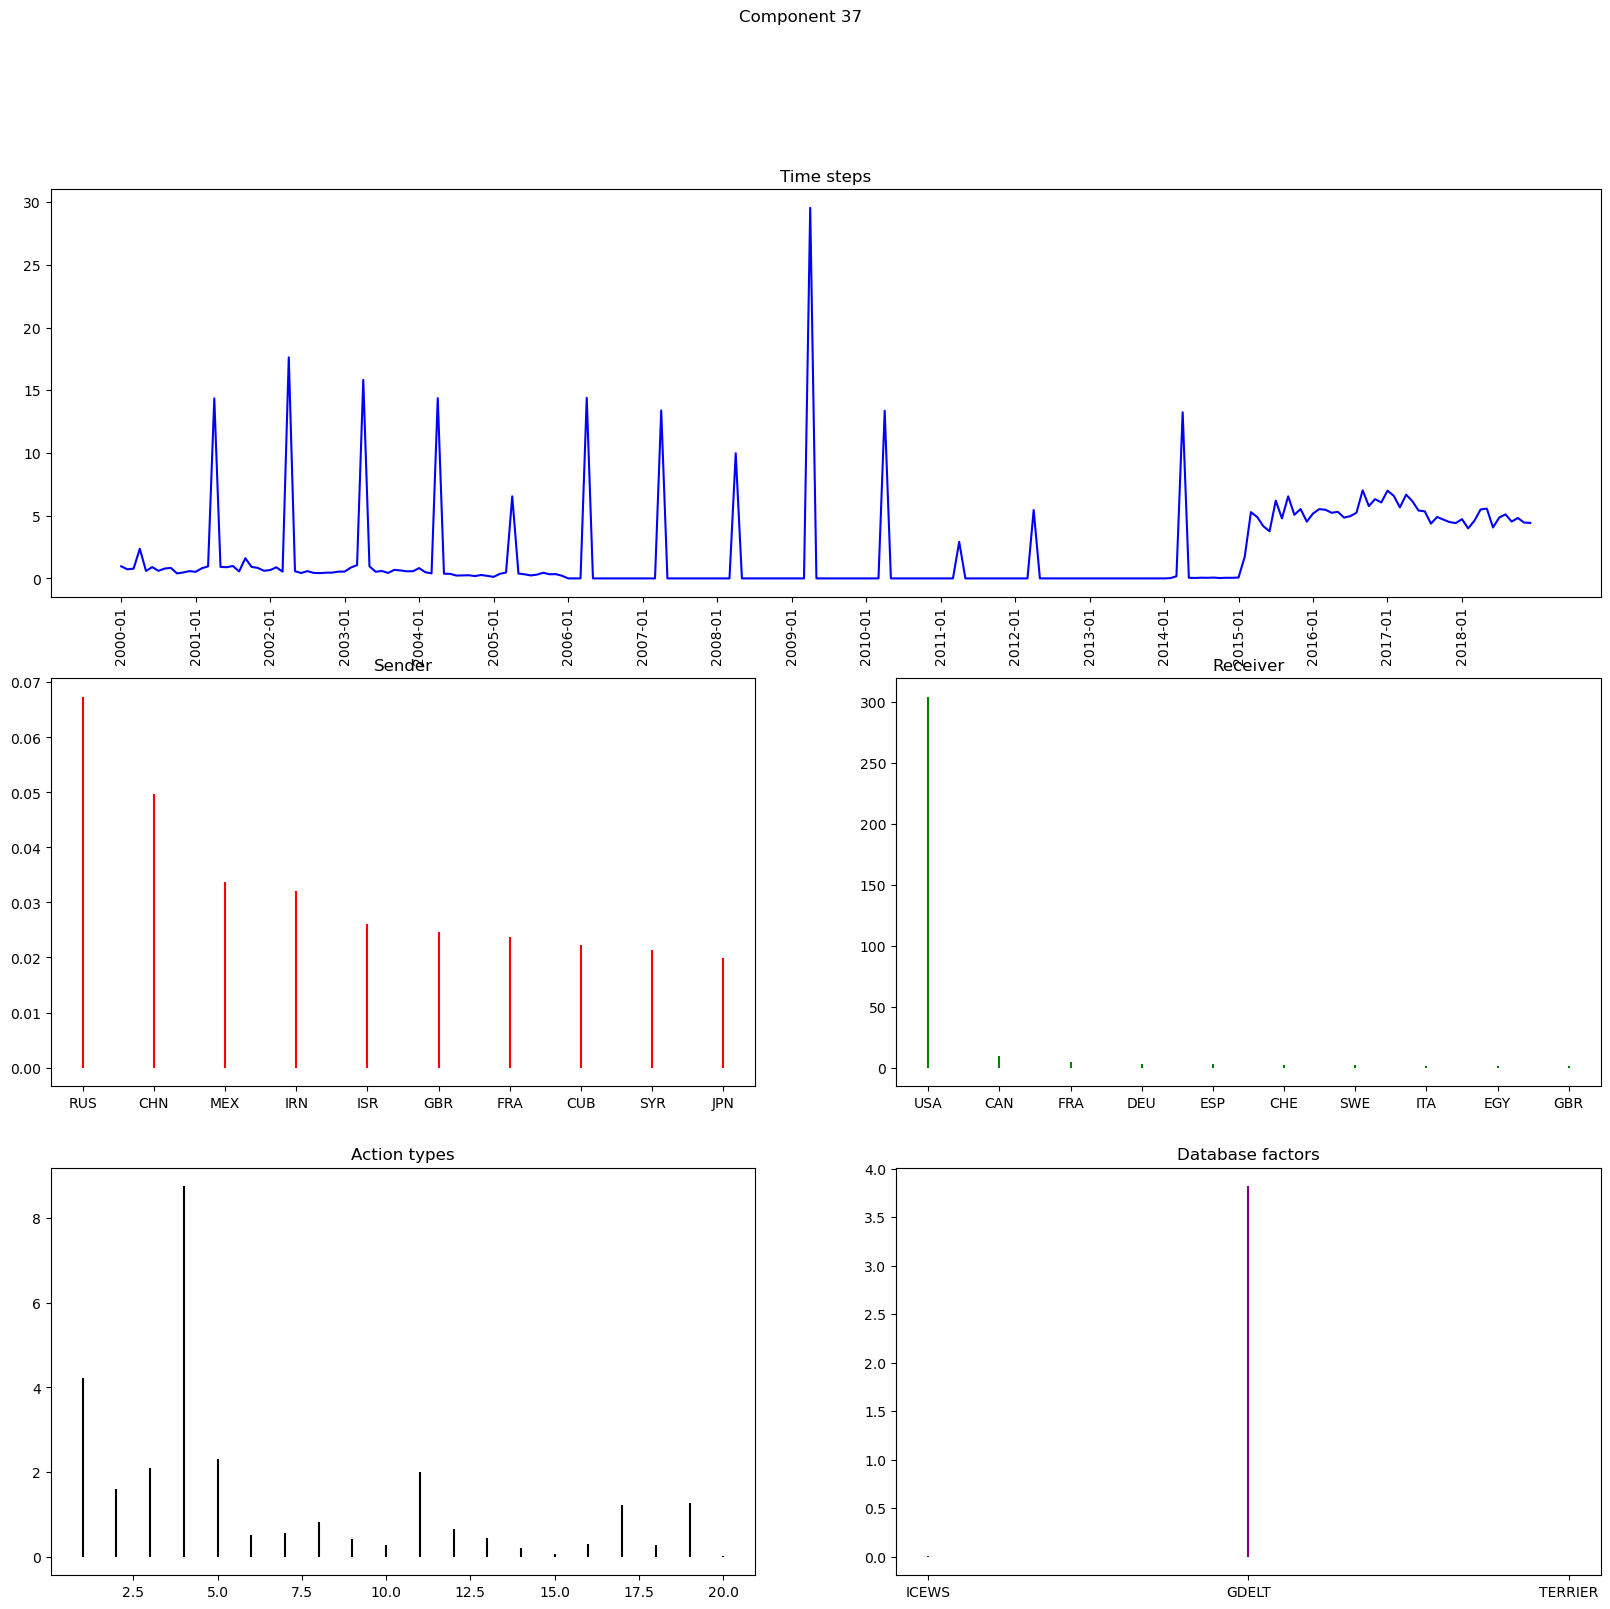

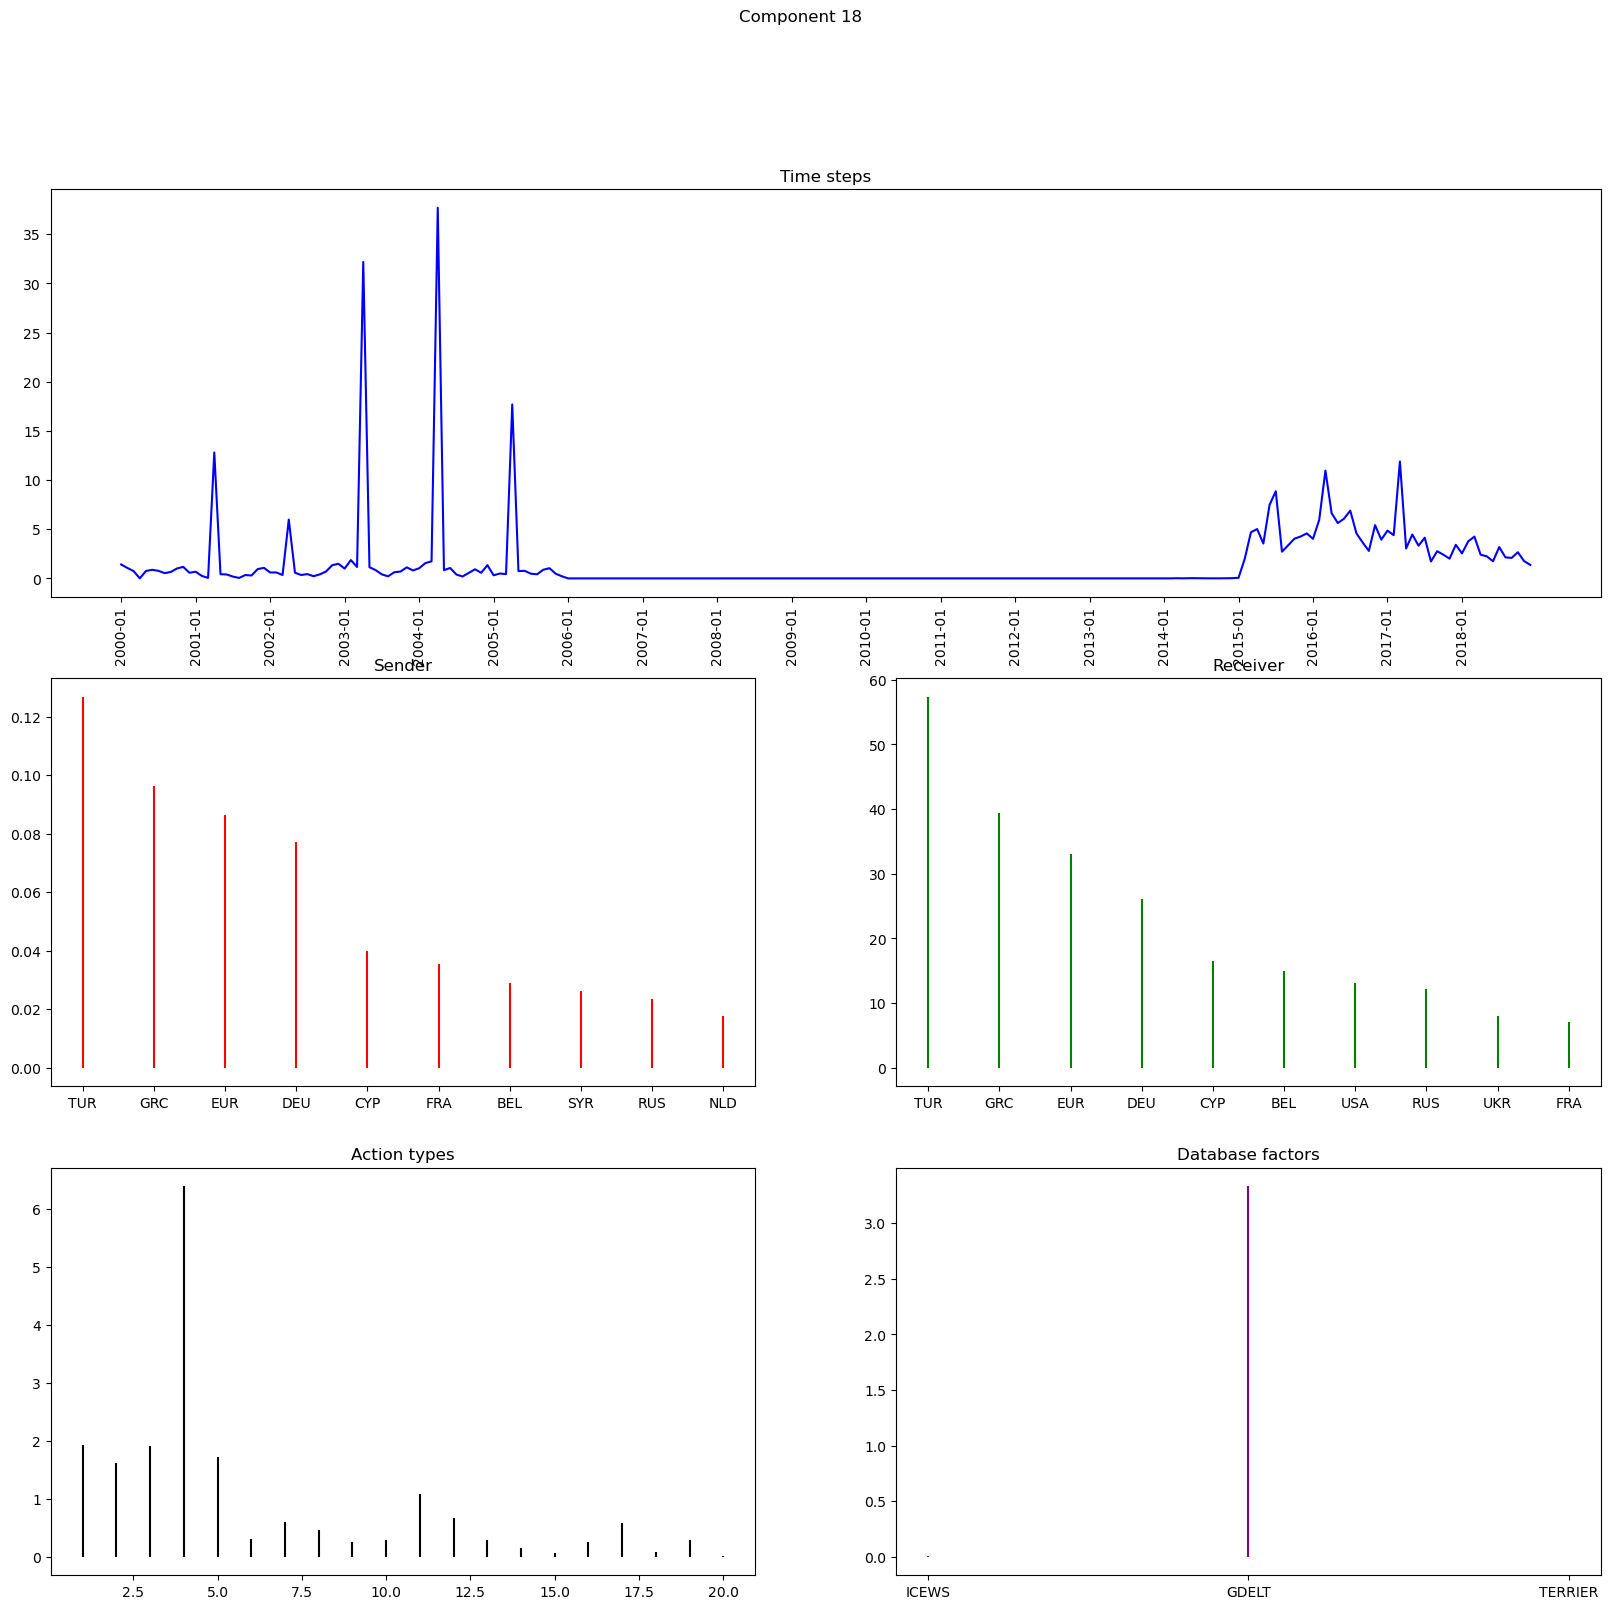

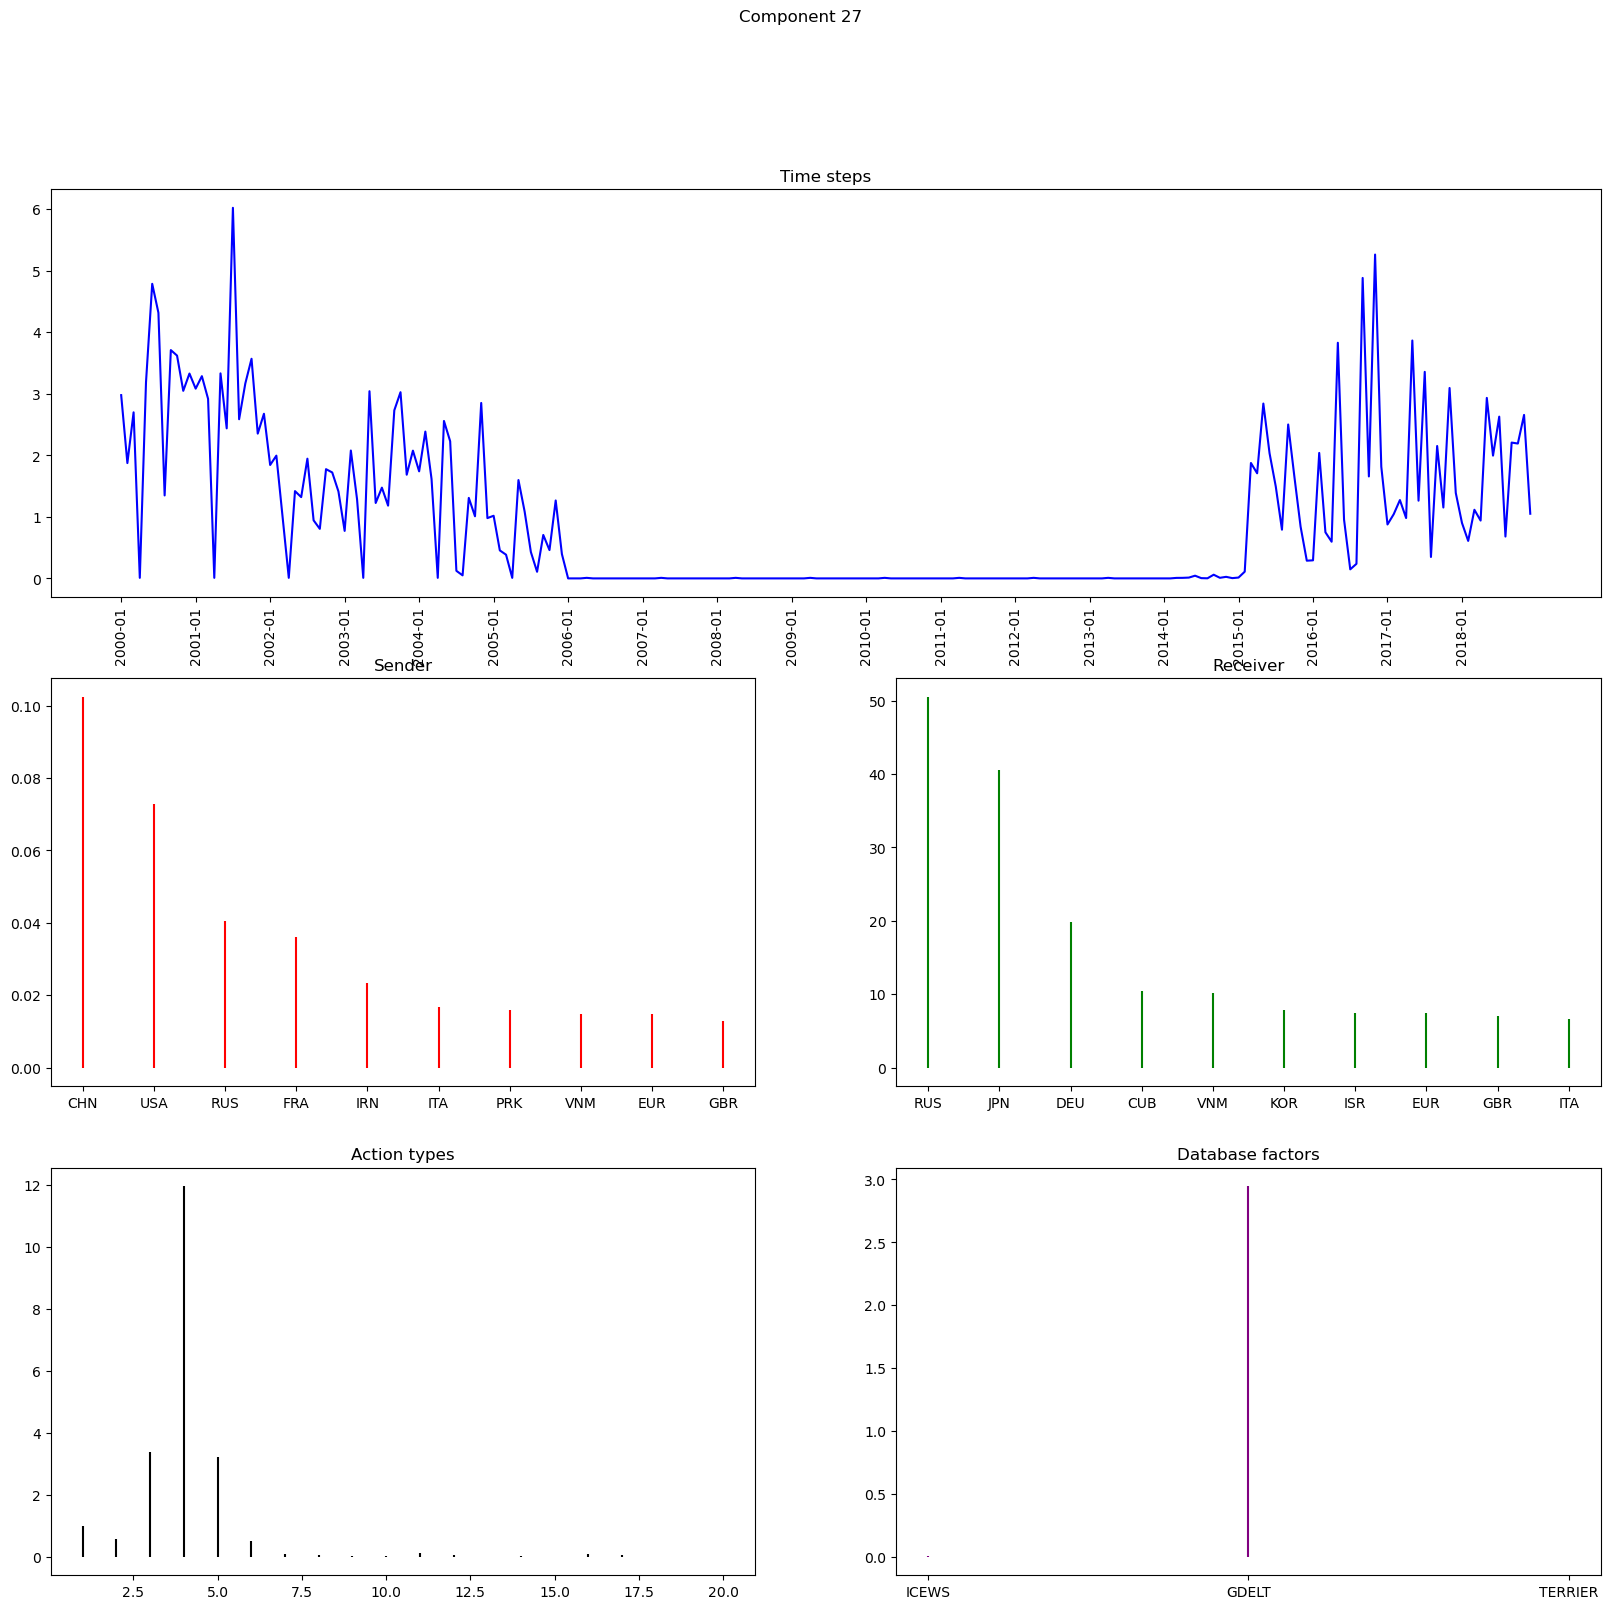

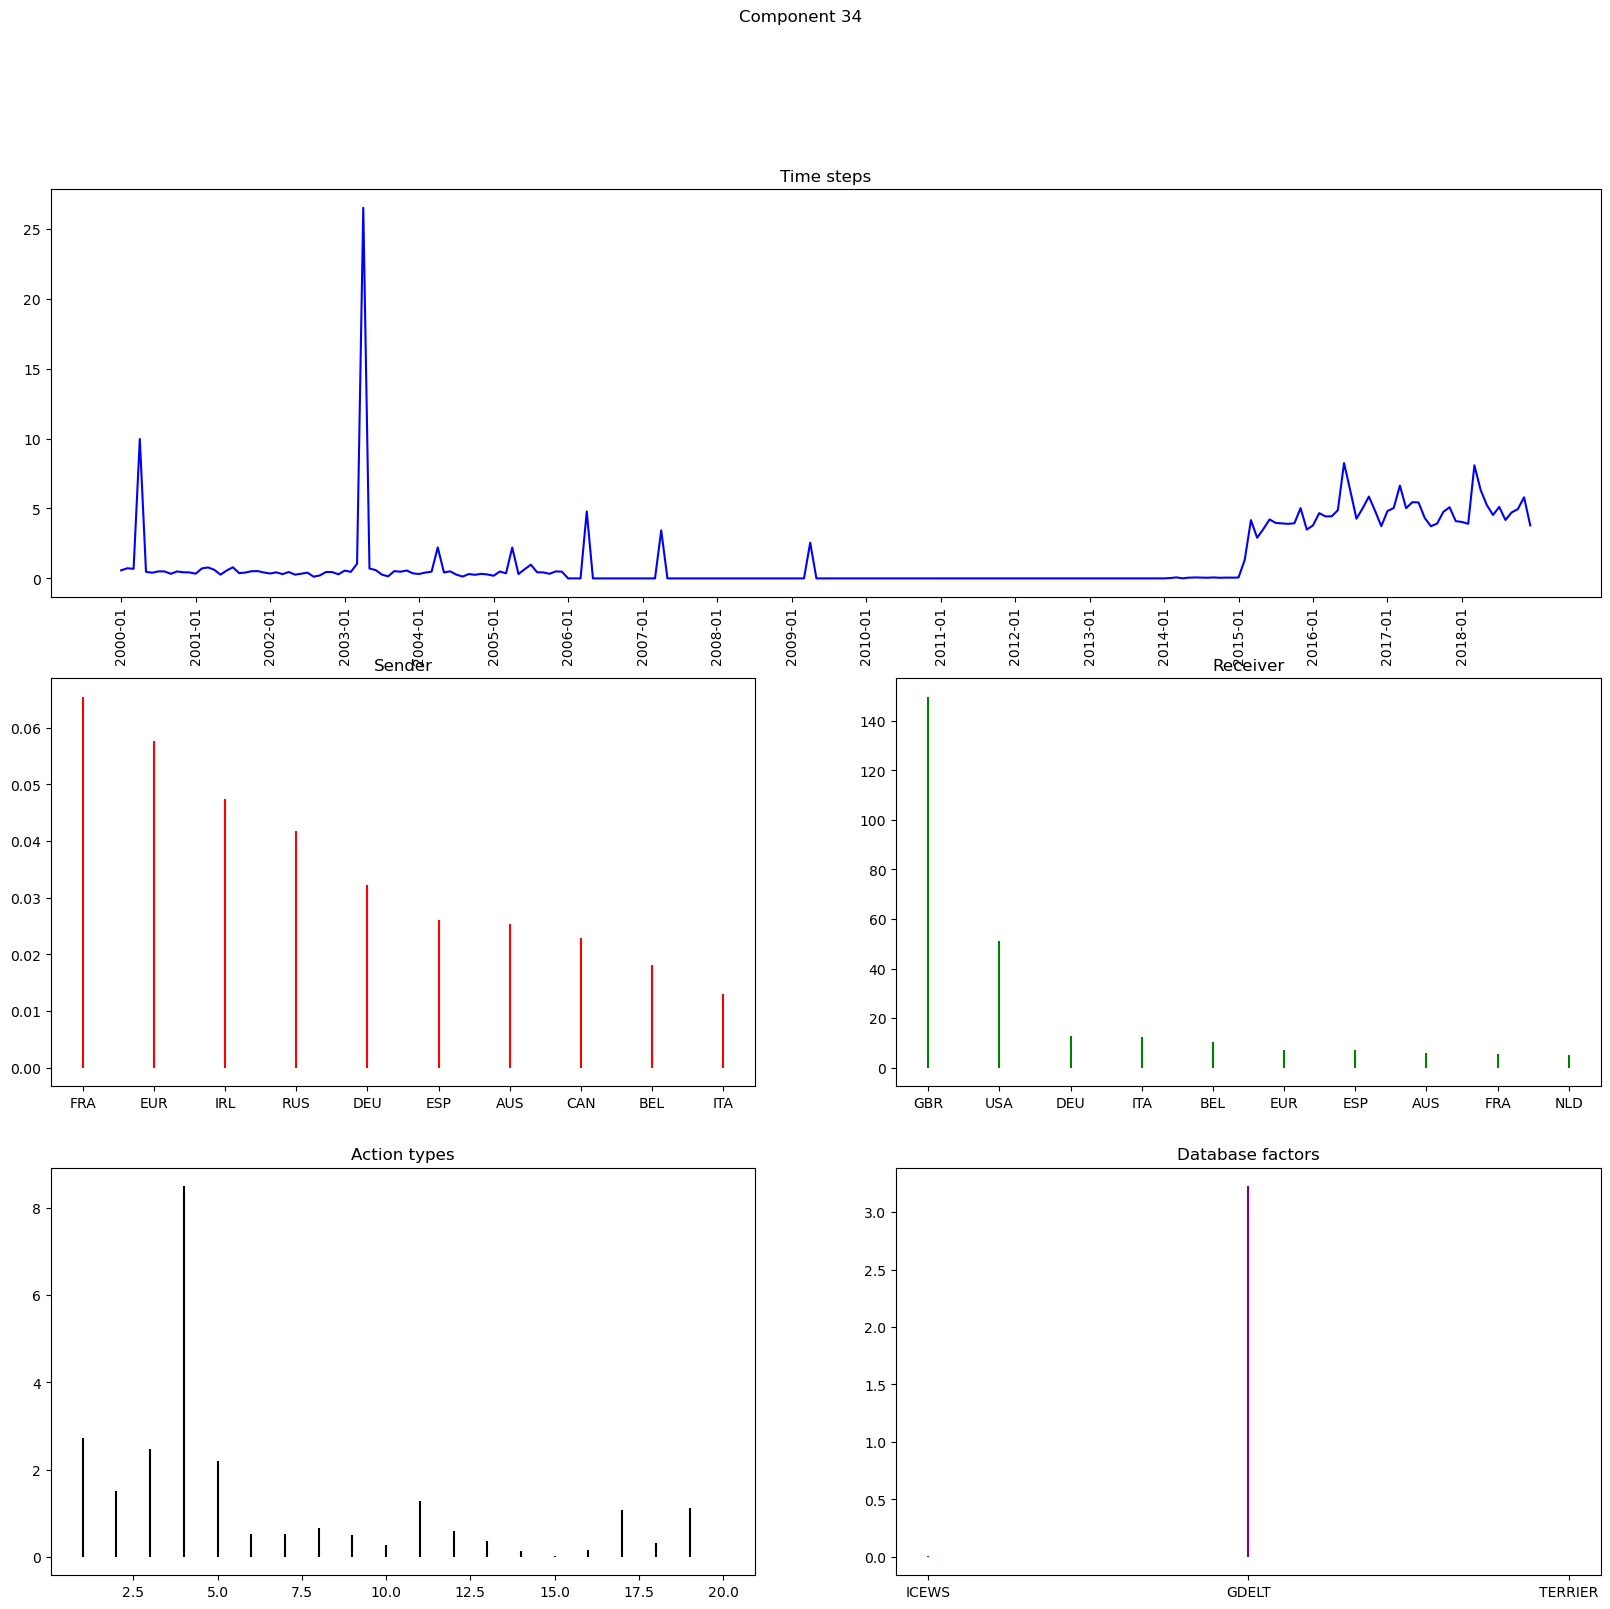

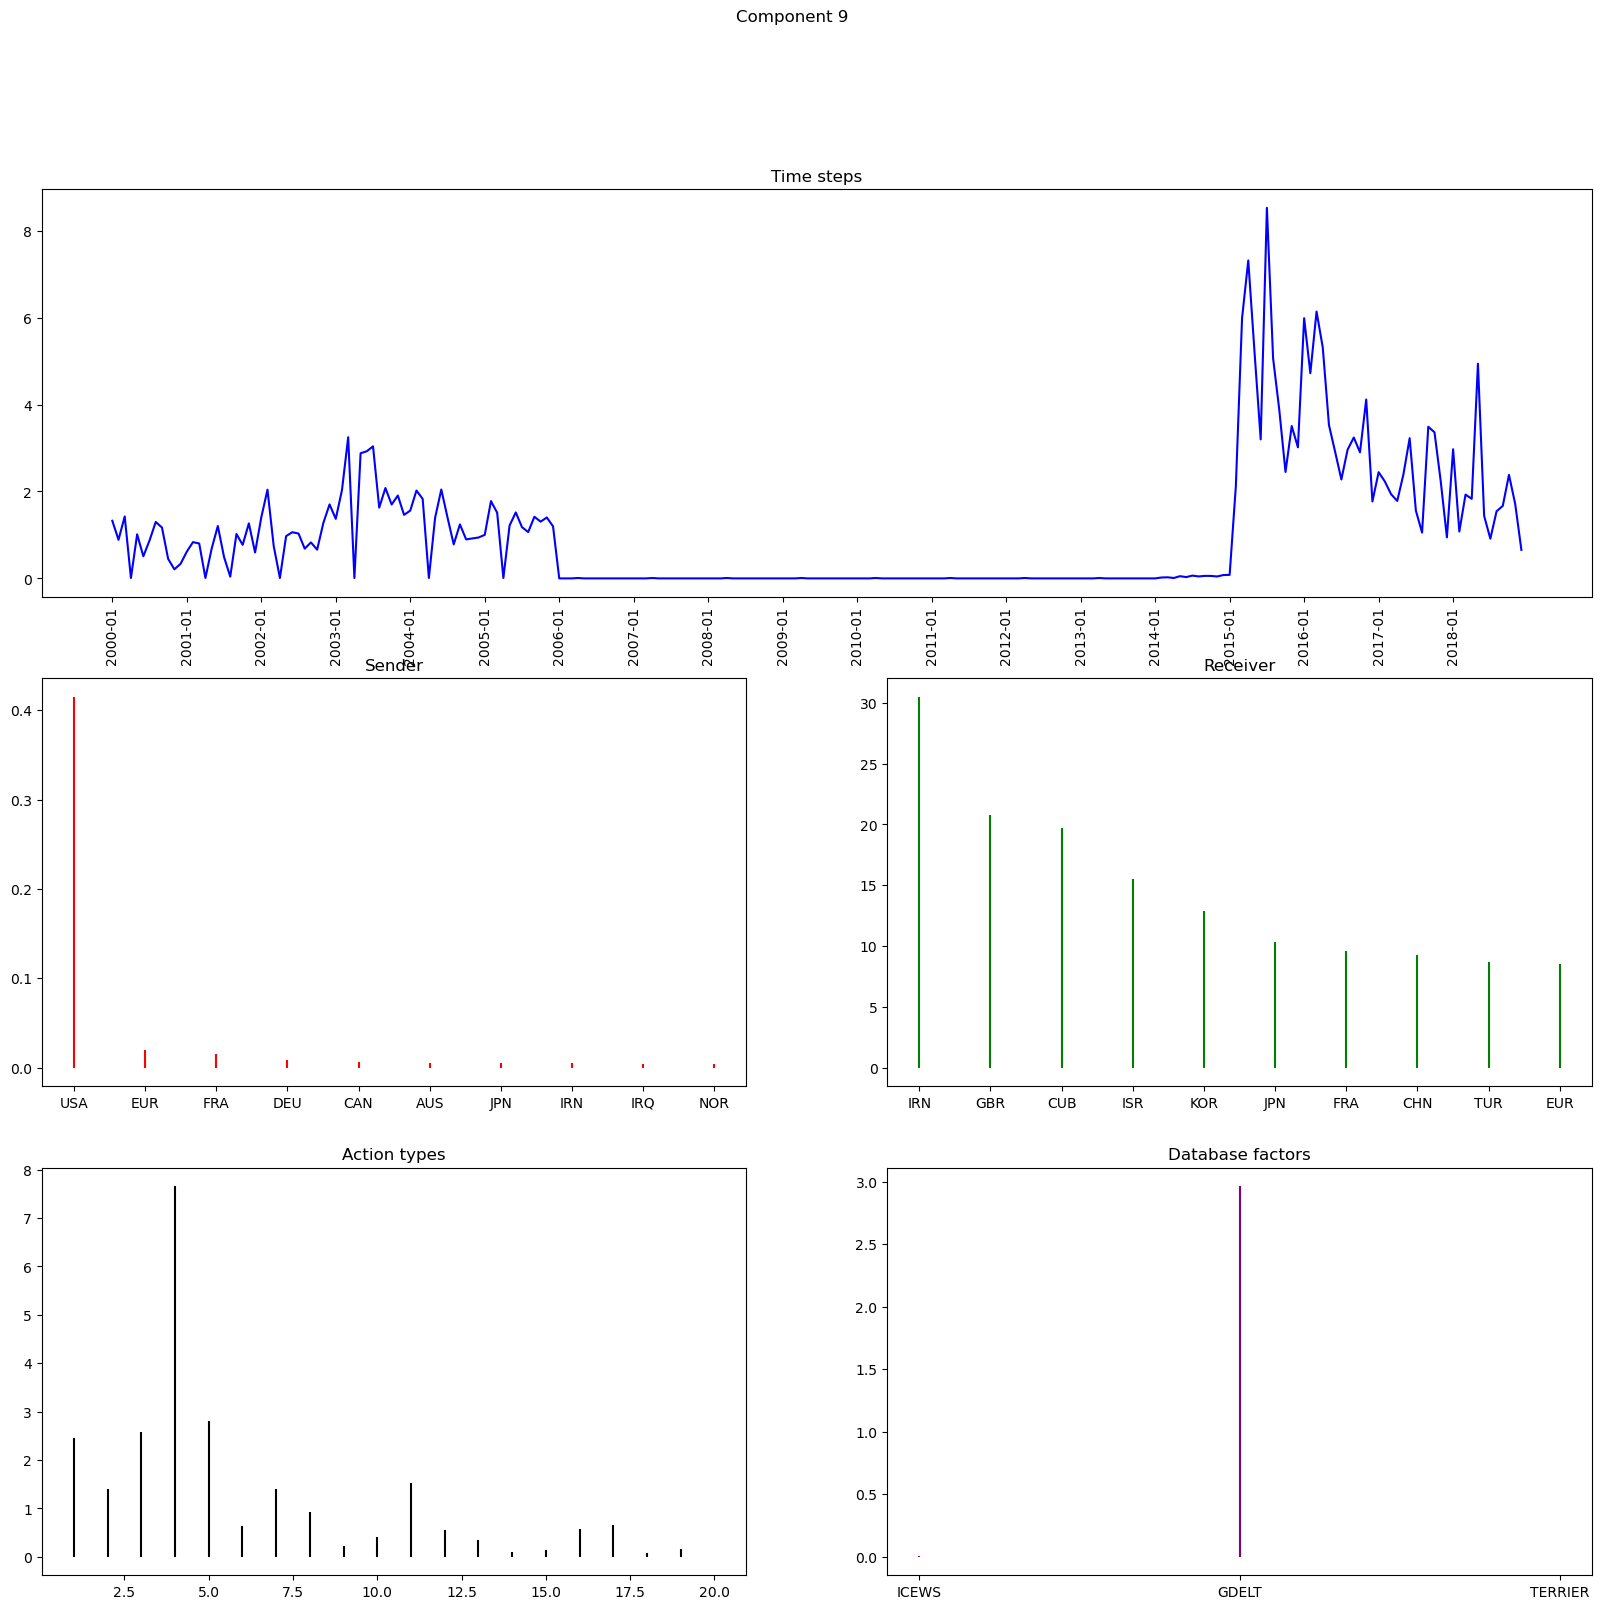

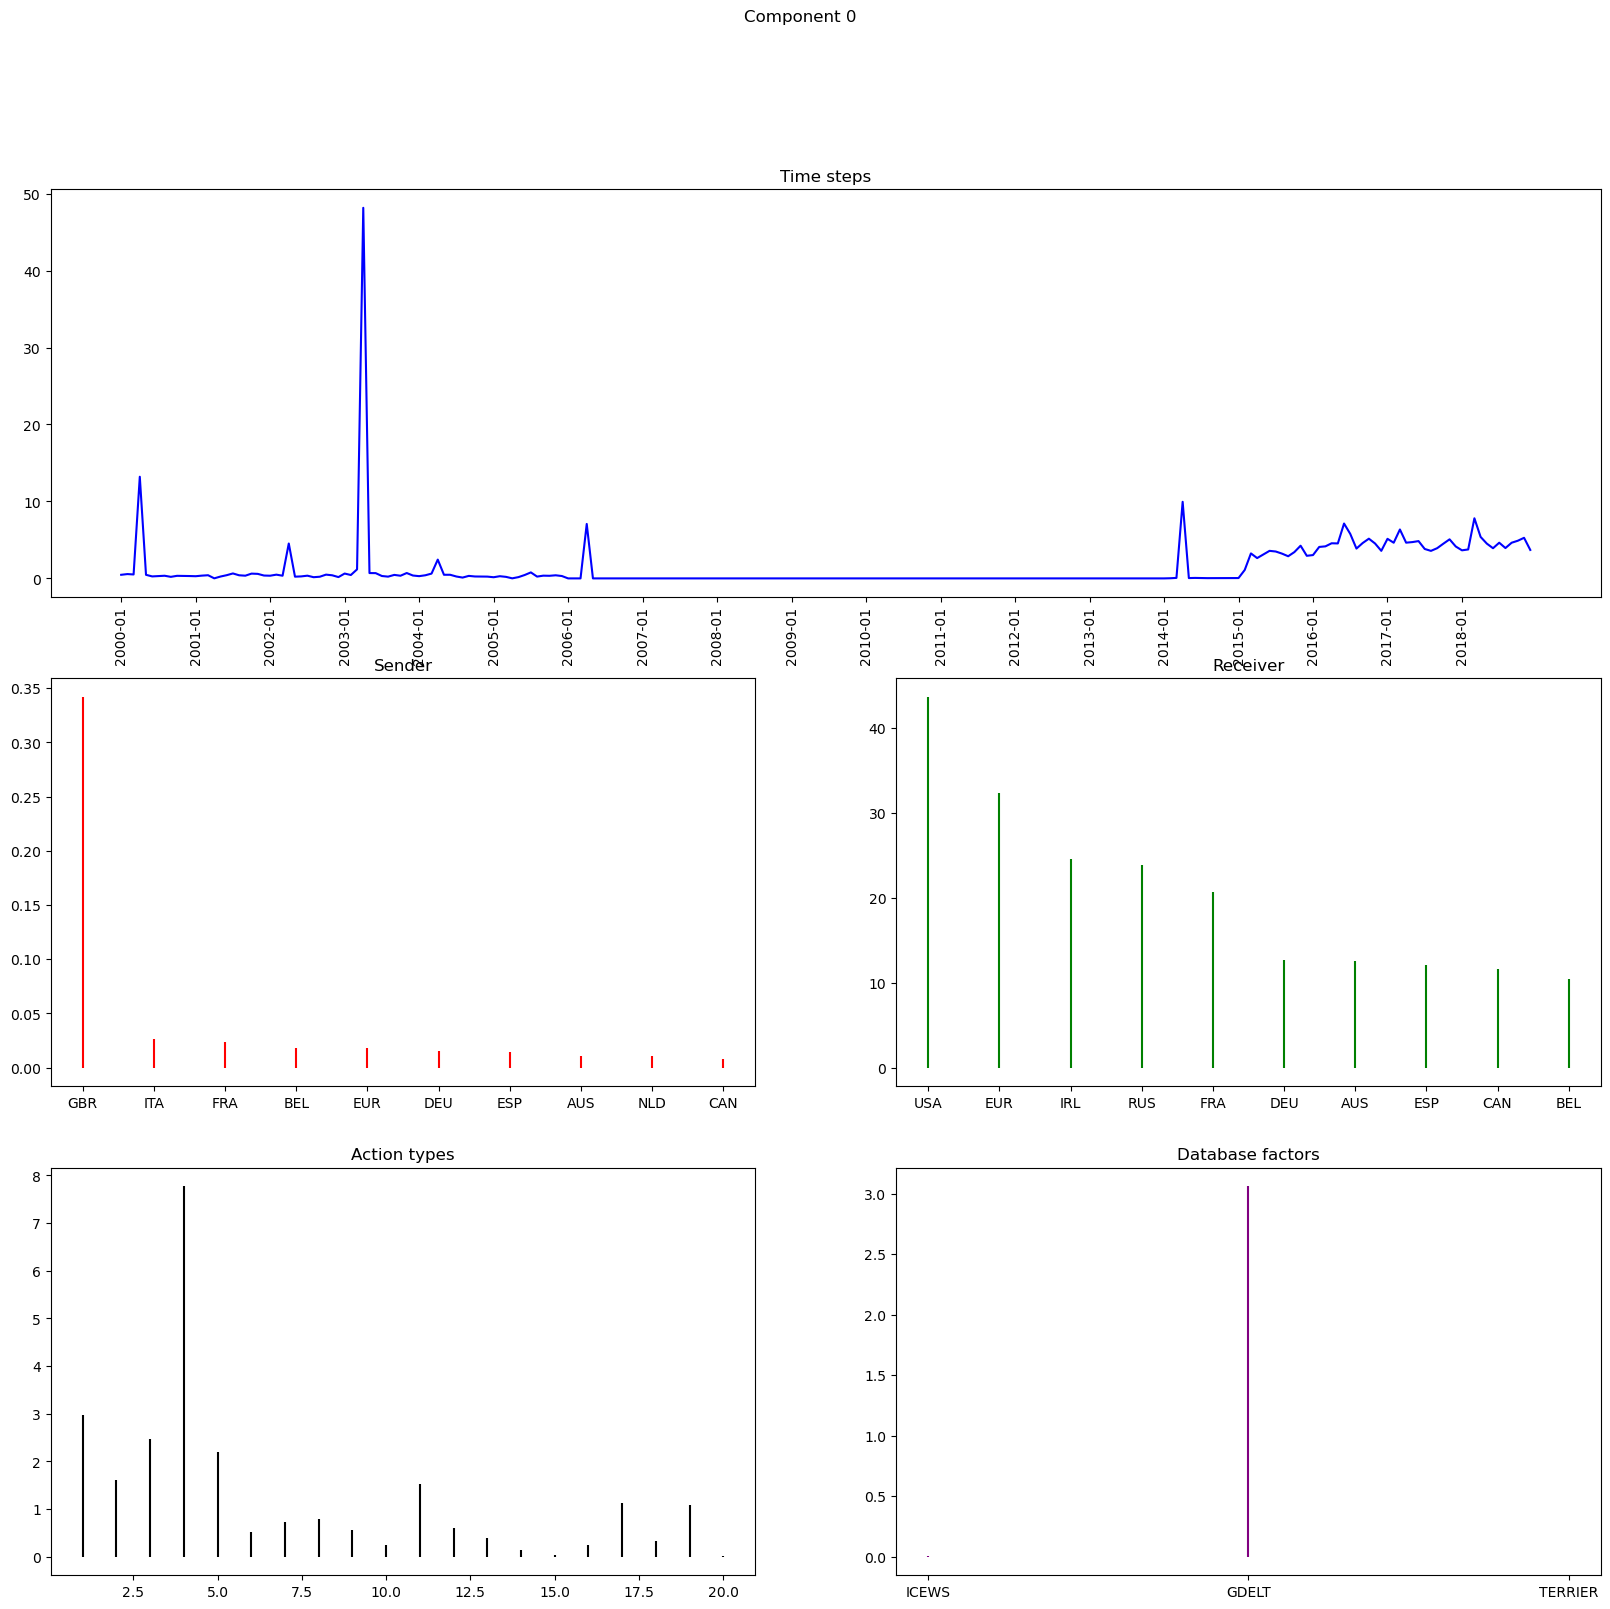

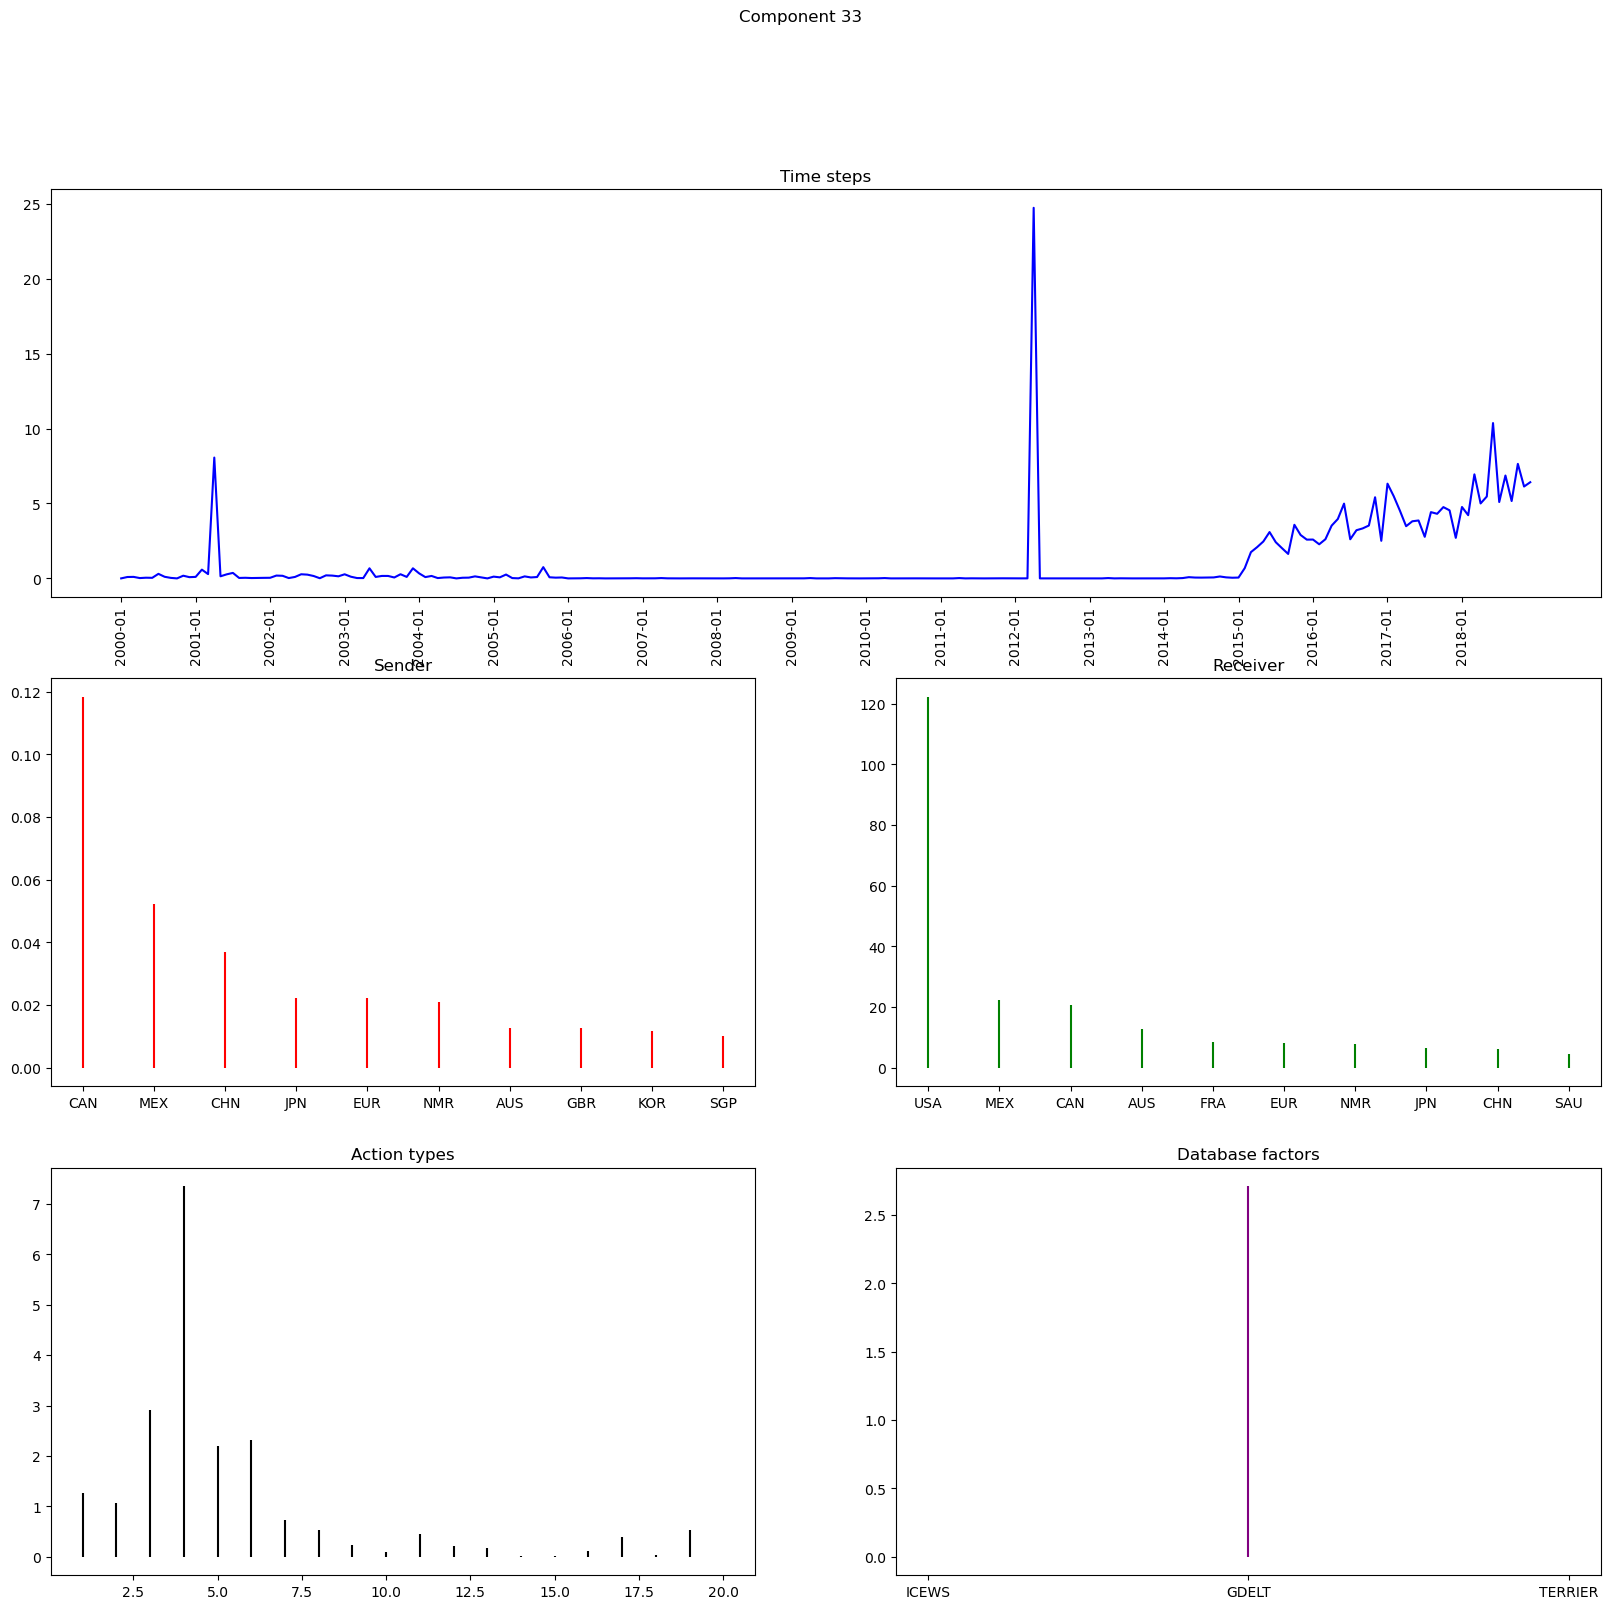

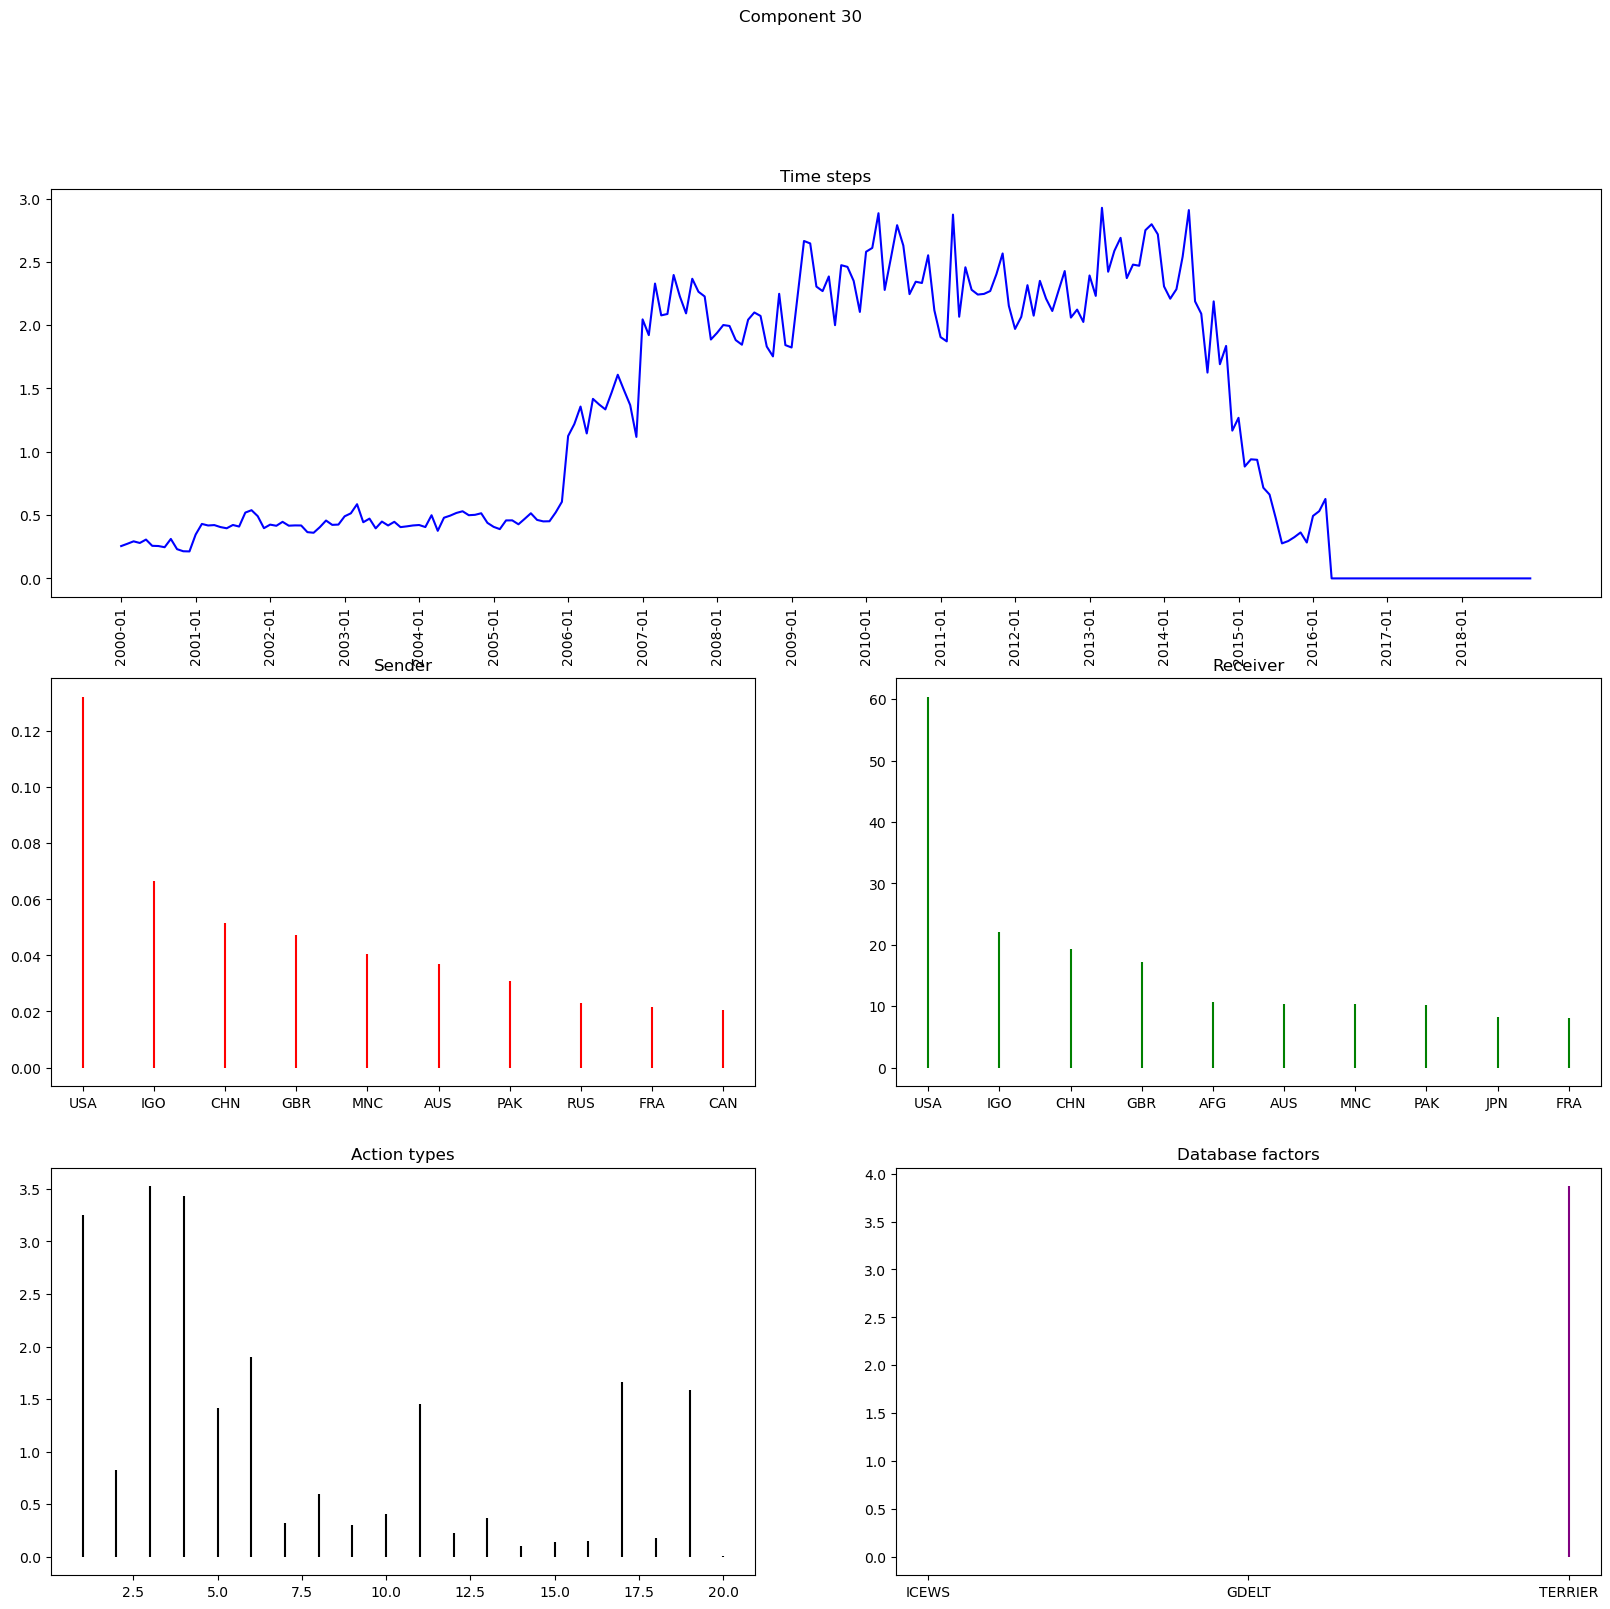

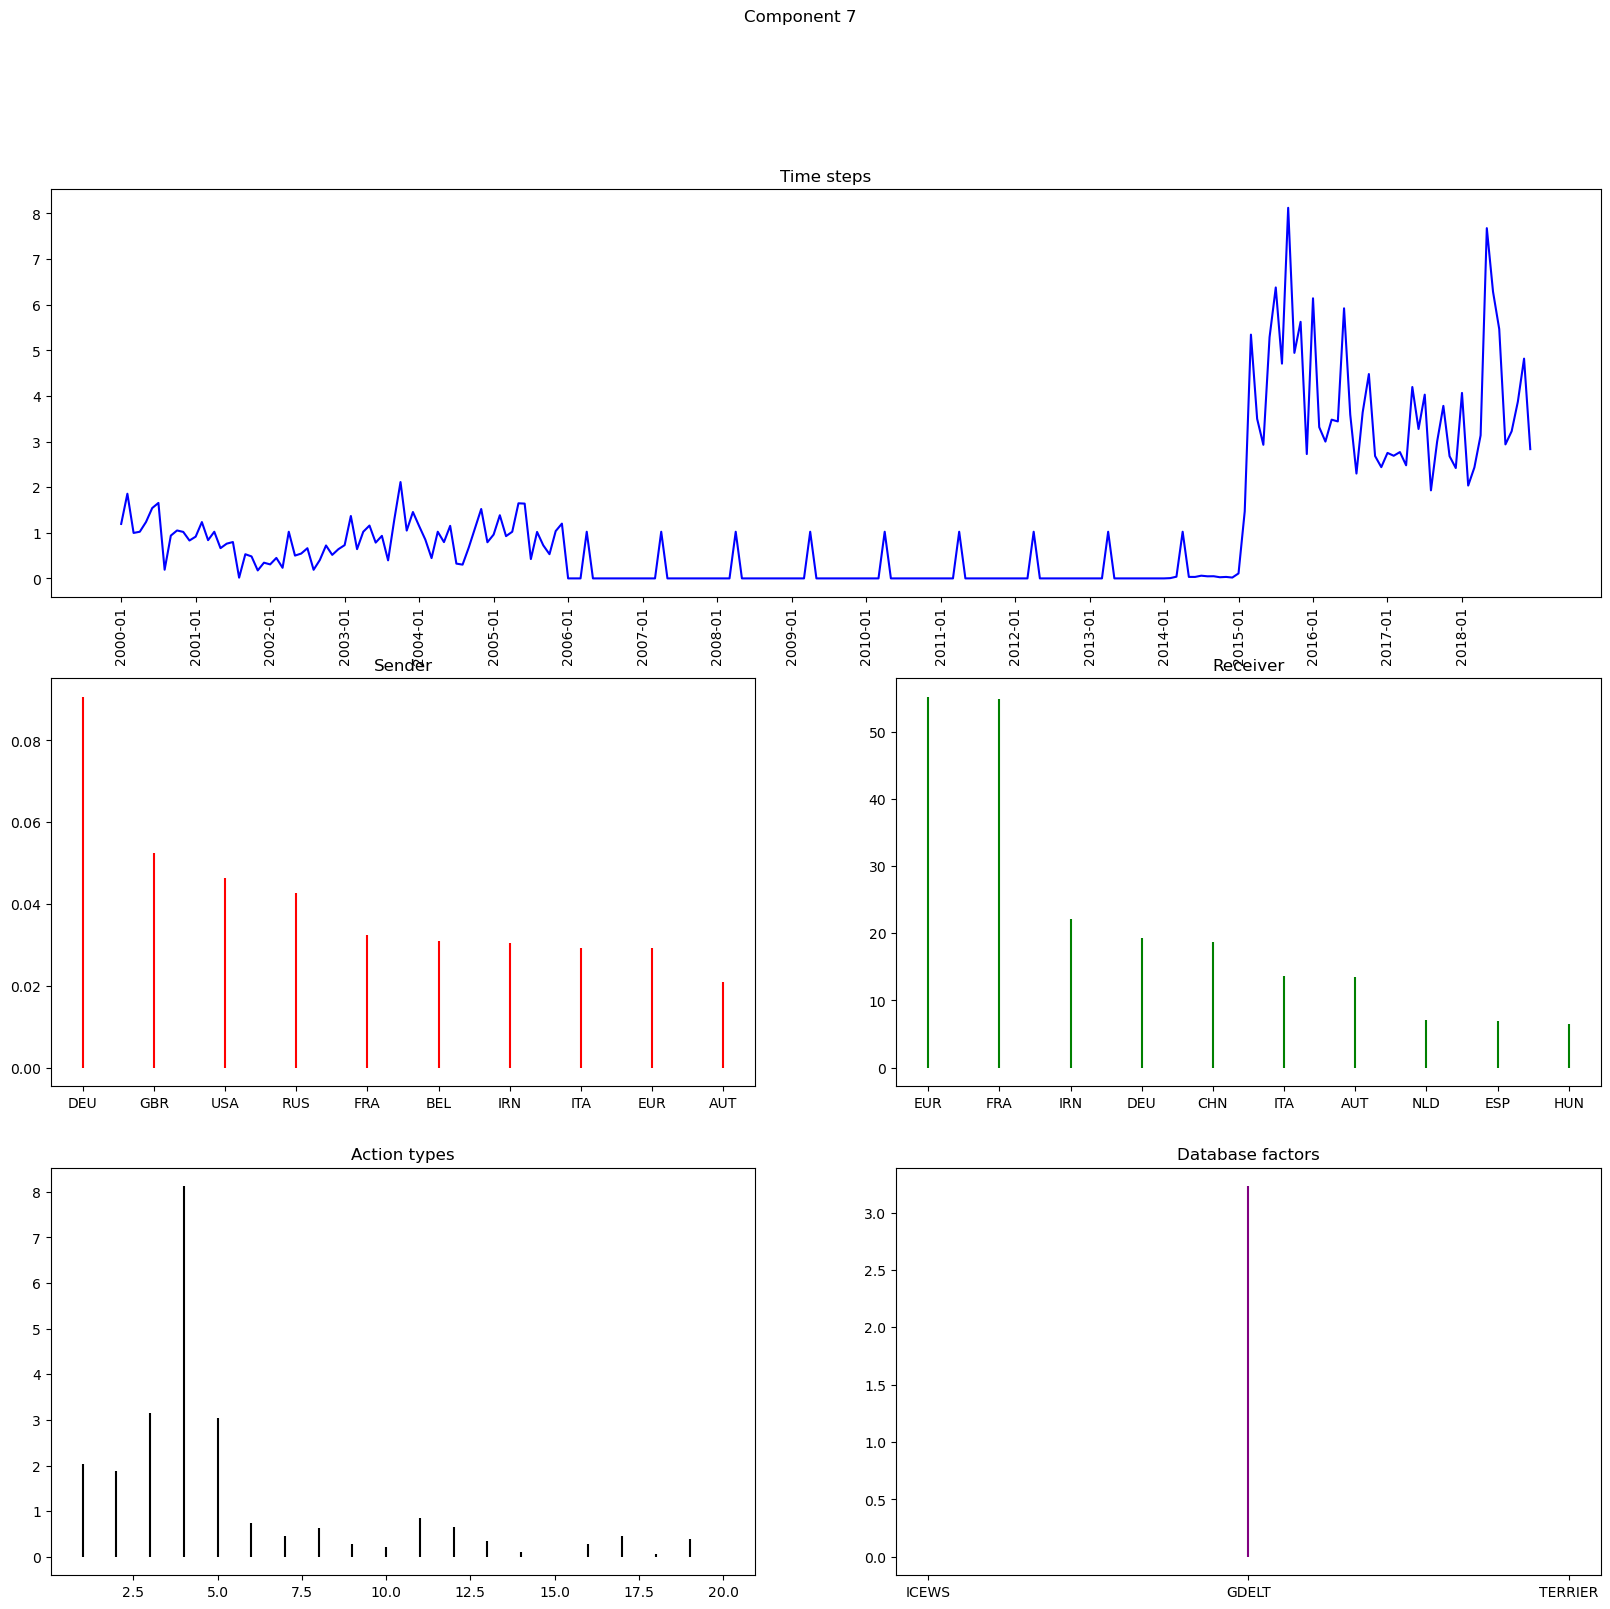

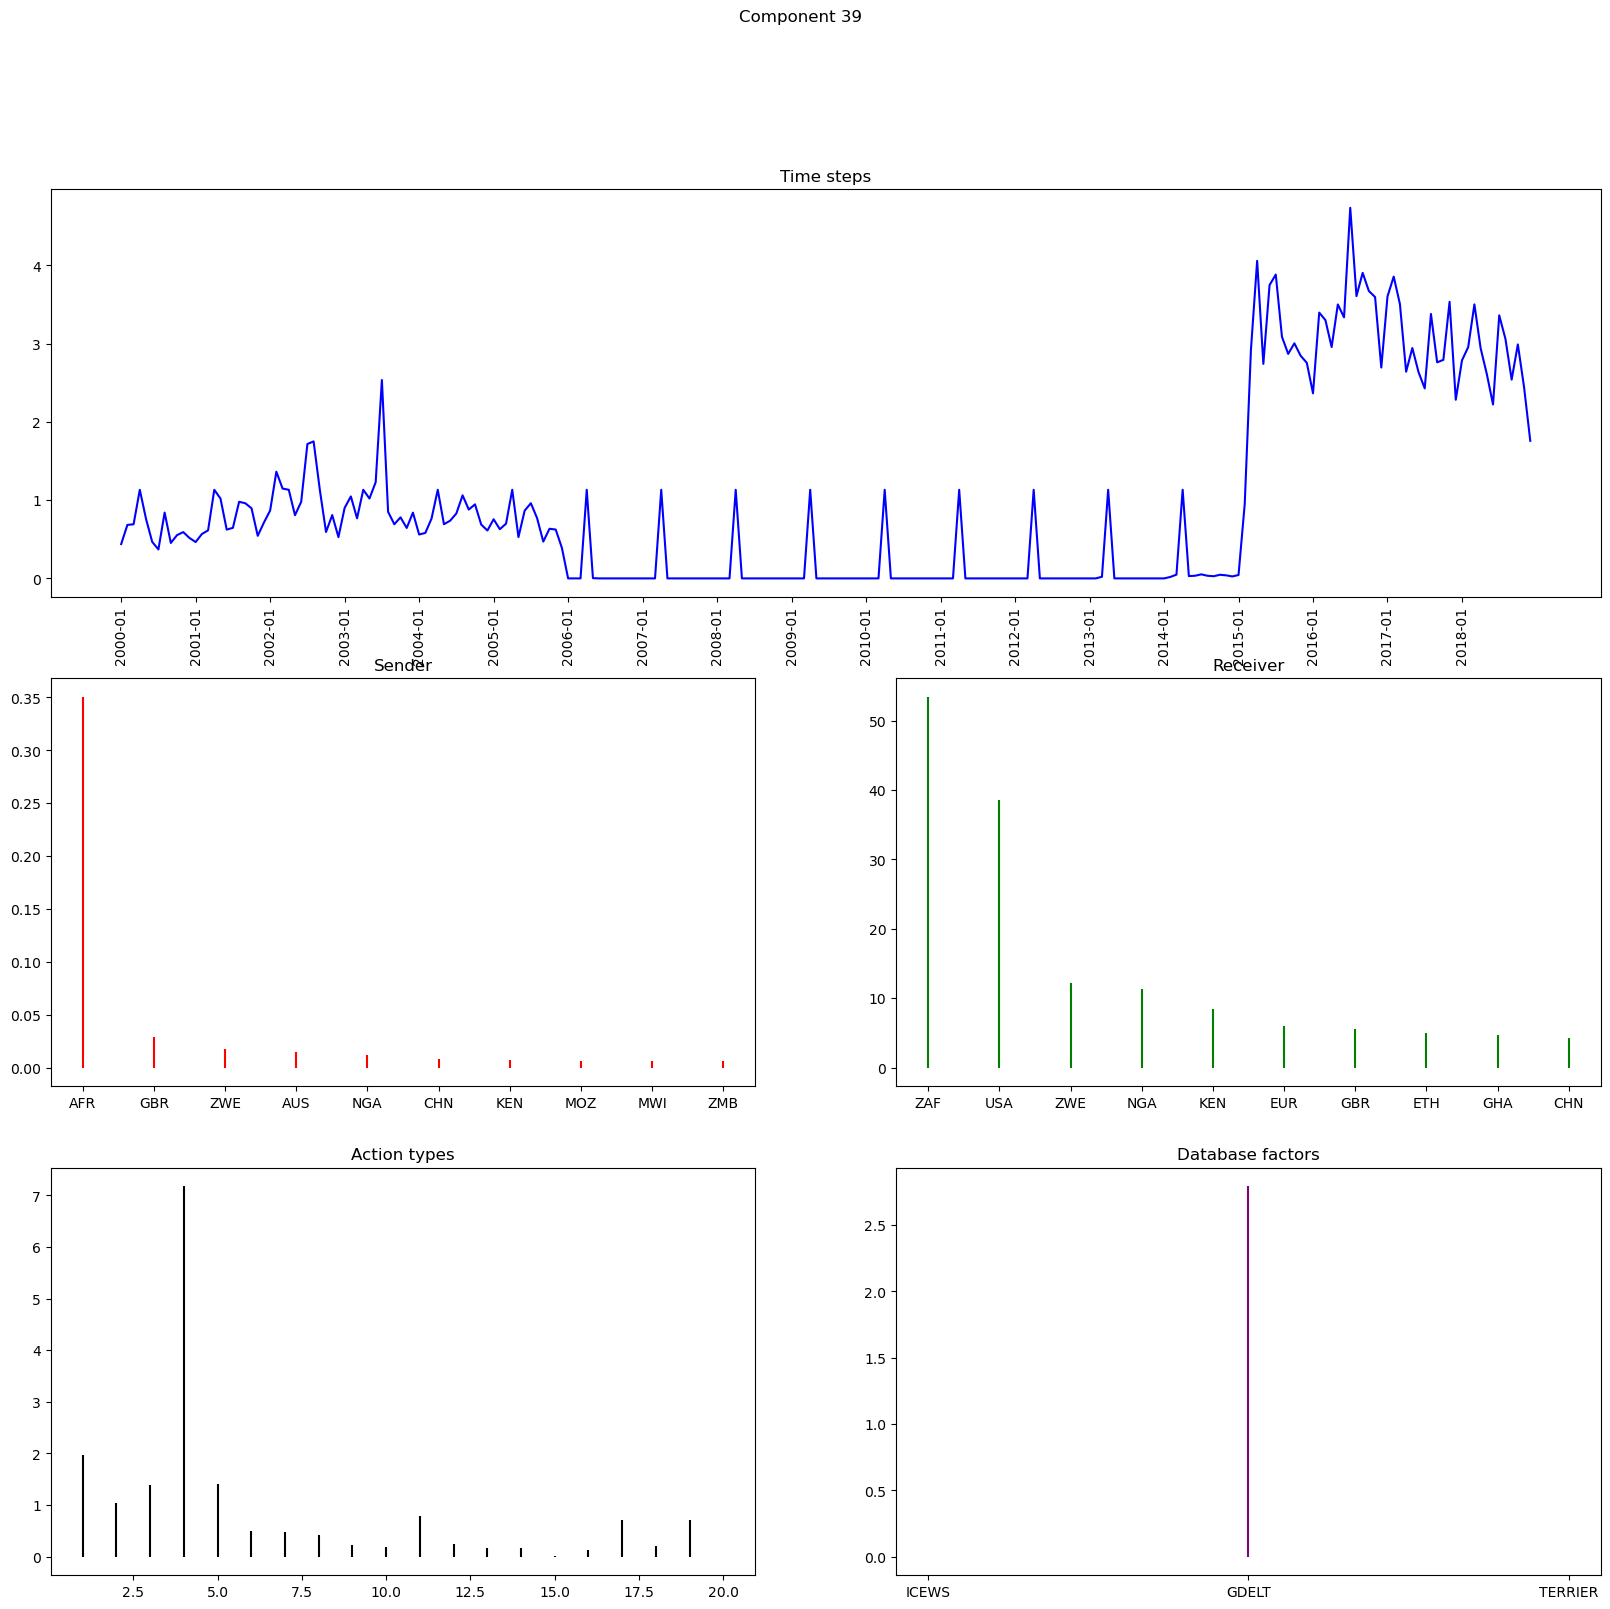

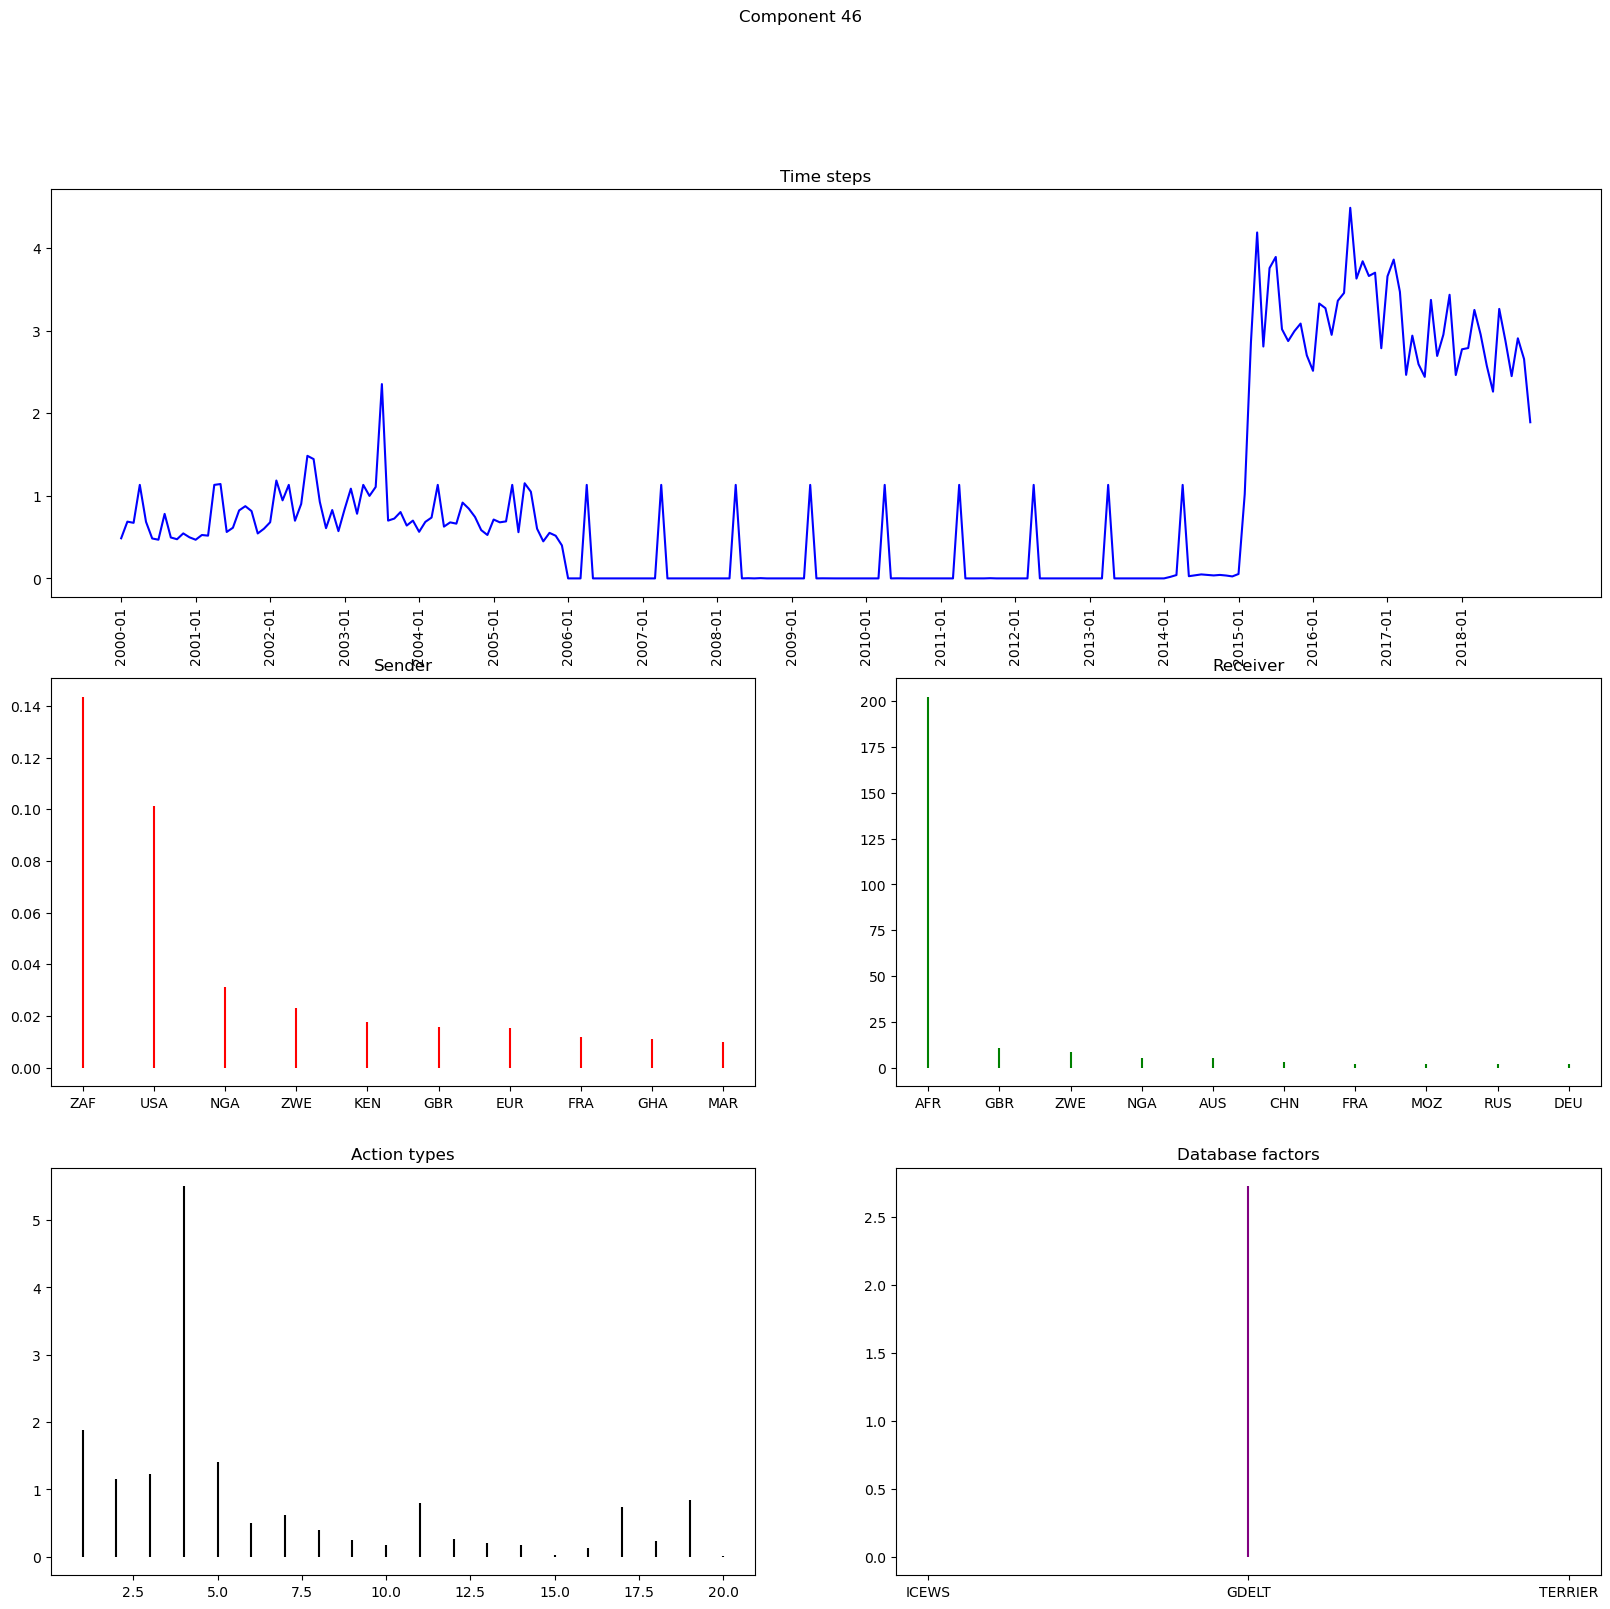

In [4]:
E_DK_M = [factor_matrix.cpu().numpy() for factor_matrix in bptf_5mode.E_DK_M]
database_factor_matrix = E_DK_M[4]
database_factor_matrix = database_factor_matrix/database_factor_matrix.sum(axis=0,keepdims=1)
database_entropy = st.entropy(database_factor_matrix, axis=0)
database_components = pd.DataFrame({
    'ICEWS' : database_factor_matrix[0, :],
    'TERRIER' : database_factor_matrix[1, :],
    'GDELT' : database_factor_matrix[2, :],
    'entropy' : database_entropy,
    'index' : range(n_components)
}).sort_values(by='entropy', ascending=False)

def component_analysis_plot(component):

    fig = plt.figure(figsize=(20, 18))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1])

    ax1 = fig.add_subplot(gs[0, :])
    time_vector = E_DK_M[3][:, component]
    time_vector = pd.DataFrame({
        'time steps' : time_vector,
        'index' : range(time_vector.shape[0])
    })
    time_vector = pd.merge(
        left=time_vector, right=date_indices,
        how='left', on='index'
    )
    ax1.plot(time_vector['date'], time_vector['time steps'], color='b')
    ticks = ax1.get_xticks()[::12]
    ax1.set_xticks(ticks)
    ax1.tick_params(axis='x', rotation=90)
    ax1.set_title('Time steps')

    ax2 = fig.add_subplot(gs[1, 0])
    sender_vector = E_DK_M[0][:, component]
    sender_vector = pd.DataFrame({
        'sender' : sender_vector,
        'index' : range(sender_vector.shape[0])})
    sender_vector = pd.merge(
        left=sender_vector, right=country_indices,
        how='left', on='index'
    ).sort_values(
        by='sender', 
        ascending=False).iloc[:10, :]
    sender_vector['country'] = sender_vector['country'].astype(str)
    ax2.vlines(x=sender_vector['country'], ymin=0, ymax=sender_vector['sender'], color='r')
    ax2.set_title('Sender')

    ax3 = fig.add_subplot(gs[1, 1])
    receiver_vector = E_DK_M[1][:, component]
    receiver_vector = pd.DataFrame({
        'receiver' : receiver_vector,
        'index' : range(receiver_vector.shape[0])})
    receiver_vector = pd.merge(
        left=receiver_vector, right=country_indices,
        how='left', on='index'
    ).sort_values(
        by='receiver', ascending=False
    ).iloc[:10, :]
    ax3.vlines(x=receiver_vector['country'], ymin=0, ymax=receiver_vector['receiver'], color='g')
    ax3.set_title('Receiver')

    ax4 = fig.add_subplot(gs[2, 0])
    action_vector = E_DK_M[2][:, component]
    action_vector = pd.DataFrame({
        'action' : action_vector,
        'action type' : range(1, 21)
    })
    ax4.vlines(x=action_vector['action type'], ymin=0, ymax=action_vector['action'], color='black')
    ax4.set_title('Action types')

    ax5 = fig.add_subplot(gs[2, 1])
    database_vector = E_DK_M[4][:, component]
    database_vector = pd.DataFrame({
        'factor' : database_vector,
        'index' : range(database_vector.shape[0])
    })
    database_vector = pd.merge(
        left=database_vector, right=database_indices,
        how='left', on='index'
    )
    ax5.vlines(x=database_vector['database'], ymin=0, ymax=database_vector['factor'], color='purple')
    ax5.set_title('Database factors')

    fig.suptitle('Component ' + str(component))

    plt.show()

for component in database_components['index']:
    component_analysis_plot(component)